# Geo Sentiment Undersampling - Non-Pretrained Main Model

Notebook ini adalah versi eksperimen dari `geo_sentiment_fix.ipynb`.

Fokus utama:
- Labeling boleh memakai IndoBERT, tetapi training/testing model utama memakai model non-pretrained.
- Imbalance handling diganti menjadi random undersampling train-only: kelas mayoritas disampling turun mengikuti jumlah kelas minoritas.
- Validation dan test set tetap memakai distribusi natural hasil split stratified agar evaluasi tetap realistis.
- Loss training dibuat netral/plain CrossEntropy: tanpa negative class weight boost, tanpa focal loss, dan tanpa back-translation augmentation.
- Threshold tuning dan evaluasi lanjutan tetap dipakai agar hasil mudah dibandingkan dengan baseline.


In [ ]:
# ============================================================
# CELL 0.1 - Install Dependencies
# ============================================================
# Set True hanya saat dependency belum tersedia.
INSTALL = False

if INSTALL:
    import subprocess
    import sys

    pkgs = [
        "PySastrawi", "nltk", "scikit-learn",
        "transformers", "accelerate", "torch",
        "pandas", "numpy", "matplotlib", "seaborn",
        "wordcloud", "tqdm", "sentencepiece", "sacremoses", "folium",
    ]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U"] + pkgs)
    print("Dependency selesai di-install. Jika baru install sentencepiece/sacremoses, restart kernel dulu.")
else:
    print("Install dilewati. Set INSTALL=True jika dependency belum tersedia.")


In [ ]:
import sys
print(sys.executable)

In [49]:
# ============================================================
# CELL 0.2 - Import & Konfigurasi
# ============================================================
import os
import re
import json
import time
import random
import warnings
from pathlib import Path
from collections import Counter
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
tqdm.pandas()

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
for res in ("punkt", "stopwords", "punkt_tab"):
    try:
        nltk.download(res, quiet=True)
    except Exception:
        pass
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords as nltk_sw

try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    STEMMER = StemmerFactory().create_stemmer()
    SASTRAWI_OK = True
except ImportError:
    STEMMER = None
    SASTRAWI_OK = False

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, auc
)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset as TorchDataset
    TORCH_OK = True
    TORCH_IMPORT_ERROR = None
    CUDA_OK = torch.cuda.is_available()
    DEVICE = "cuda" if CUDA_OK else "cpu"
    PIPELINE_DEVICE = 0 if CUDA_OK else -1
    GPU_NAME = torch.cuda.get_device_name(0) if CUDA_OK else "CPU"
    if CUDA_OK:
        torch.backends.cudnn.benchmark = True
except Exception as e:
    TORCH_OK = False
    TORCH_IMPORT_ERROR = repr(e)
    CUDA_OK = False
    DEVICE = "cpu"
    PIPELINE_DEVICE = -1
    GPU_NAME = "CPU"

try:
    from transformers import (
        AutoTokenizer, AutoModelForSequenceClassification,
        TrainingArguments, Trainer, TrainerCallback, pipeline
    )
    TRANSFORMERS_OK = True
    TRANSFORMERS_IMPORT_ERROR = None
except Exception as e:
    TRANSFORMERS_OK = False
    TRANSFORMERS_IMPORT_ERROR = repr(e)

DEPENDENCIES_OK = TORCH_OK and TRANSFORMERS_OK

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
if TORCH_OK:
    torch.manual_seed(RANDOM_STATE)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_STATE)

BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "dataset"
RAW_DIR = DATA_DIR / "raw"
SPLIT_DIR = DATA_DIR / "split"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = BASE_DIR / "output" / "geo_sentiment_undersampling"
MODEL_DIR = BASE_DIR / "model" / "geo_sentiment_undersampling"
for d in [PROCESSED_DIR, OUTPUT_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

INDOBERT_MODEL = "mdhugol/indonesia-bert-sentiment-classification"
LABEL_NAMES = {0: "Negatif", 1: "Positif"}
LABEL_COLORS = {0: "#E74C3C", 1: "#27AE60"}

plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "figure.figsize": (10, 5)})
sns.set_theme(style="whitegrid")

print("=" * 60)
print("ENVIRONMENT CHECK - IndoBERT Undersampling Experiment")
print("=" * 60)
print(f"PySastrawi : {'OK' if SASTRAWI_OK else 'MISSING - pip install PySastrawi'}")
print(f"PyTorch    : {'OK' if TORCH_OK else 'MISSING - pip install torch'}")
if not TORCH_OK:
    print(f"[IMPORT][torch] {TORCH_IMPORT_ERROR}")
print(f"Transformers: {'OK' if TRANSFORMERS_OK else 'MISSING/ERROR - pip install transformers accelerate'}")
if not TRANSFORMERS_OK:
    print(f"[IMPORT][transformers] {TRANSFORMERS_IMPORT_ERROR}")
print(f"Device     : {DEVICE}")
print(f"GPU name   : {GPU_NAME}")
if TORCH_OK:
    print(f"Torch ver  : {torch.__version__}")
    print(f"CUDA build : {getattr(torch.version, 'cuda', None)}")
    if not CUDA_OK:
        print("[GPU][WARN] CUDA tidak terdeteksi. Training/testing akan jatuh ke CPU.")
        print("[GPU][INFO] Untuk GPU laptop NVIDIA, install PyTorch CUDA sesuai driver dari https://pytorch.org/get-started/locally/")
print(f"Output dir : {OUTPUT_DIR}")
print("=" * 60)


ENVIRONMENT CHECK - IndoBERT Undersampling Experiment
PySastrawi : OK
PyTorch    : OK
Transformers: OK
Device     : cuda
GPU name   : NVIDIA GeForce RTX 3050 Laptop GPU
Torch ver  : 2.12.0+cu126
CUDA build : 12.6
Output dir : output\geo_sentiment_undersampling


## 0.3. Helper Load Cache dan Model Tersimpan

Gunakan cell ini untuk menjalankan notebook di Colab/local tanpa preprocessing, labeling, atau training ulang jika artefak hasil eksperimen undersampling sudah tersedia.


In [ ]:
# ============================================================
# CELL 0.3 - Helper Load Cache Processed/Labeled dan Model OPT IndoBERT
# ============================================================
# Contoh Colab:
# ARTIFACT_ROOT = "/content/geo_sentiment_undersampling_artifacts"
# artifacts = load_undersampling_artifacts(ARTIFACT_ROOT, load_model=True, load_labeled=True)
#
# Setelah labeling pertama kali selesai, simpan cache agar run berikutnya cepat:
# save_processed_labeled_cache()

class LoadedIndoBERTWrapper:
    """Wrapper ringan agar model hasil load tetap kompatibel dengan predict_sentiment_indobert."""
    def __init__(self, model):
        self.model = model


def _as_path(p):
    return p if isinstance(p, Path) else Path(str(p))


def _existing_path(candidates, desc):
    for cand in candidates:
        p = _as_path(cand)
        if p.exists():
            return p
    raise FileNotFoundError(f"{desc} tidak ditemukan. Kandidat: {[str(c) for c in candidates]}")


def _artifact_roots(root=None):
    roots = []
    if root is not None:
        roots.append(_as_path(root))
    roots.extend([
        BASE_DIR,
        Path("."),
        Path("notebooks"),
        Path("/content/geo_sentiment_undersampling_artifacts"),
        Path("/content/drive/MyDrive/geo_sentiment_undersampling_artifacts"),
    ])
    unique = []
    seen = set()
    for r in roots:
        key = str(r)
        if key not in seen:
            unique.append(r)
            seen.add(key)
    return unique


def set_undersampling_artifact_dirs(root=None):
    """Set DATA_DIR/PROCESSED_DIR/OUTPUT_DIR/MODEL_DIR ke folder artefak undersampling."""
    root_path = _as_path(root) if root is not None else BASE_DIR
    dirs = {
        "BASE_DIR": root_path,
        "DATA_DIR": root_path / "dataset",
        "RAW_DIR": root_path / "dataset" / "raw",
        "SPLIT_DIR": root_path / "dataset" / "split",
        "PROCESSED_DIR": root_path / "dataset" / "processed",
        "OUTPUT_DIR": root_path / "output" / "geo_sentiment_undersampling",
        "MODEL_DIR": root_path / "model" / "geo_sentiment_undersampling",
    }
    dirs["PROCESSED_DIR"].mkdir(parents=True, exist_ok=True)
    dirs["OUTPUT_DIR"].mkdir(parents=True, exist_ok=True)
    dirs["MODEL_DIR"].mkdir(parents=True, exist_ok=True)
    globals().update(dirs)
    print(f"[ARTIFACT] Root aktif: {root_path}")
    return dirs


def _processed_candidates(filename, root=None):
    candidates = []
    for r in _artifact_roots(root):
        candidates.extend([
            r / "dataset" / "processed" / filename,
            r / "notebooks" / "dataset" / "processed" / filename,
            r / filename,
        ])
    candidates.extend([
        PROCESSED_DIR / filename,
        Path("dataset/processed") / filename,
        Path("notebooks/dataset/processed") / filename,
        Path("/content") / filename,
    ])
    return candidates


def load_processed_text_cache(root=None, filename="all_platforms_preprocessed.csv", set_global=True):
    """Load hasil text processing agar tidak perlu menjalankan CELL 3.1-3.3 ulang."""
    path = _existing_path(_processed_candidates(filename, root), "File processed text")
    loaded = pd.read_csv(path, encoding="utf-8-sig", low_memory=False)
    required_any = {"text_bert", "text_ml", "review_text"}
    if not required_any.intersection(loaded.columns):
        raise ValueError(f"{path} tidak terlihat seperti file processed text. Kolom: {list(loaded.columns)[:20]}")
    if set_global:
        globals()["df"] = loaded.copy()
        globals()["df_processed_cache"] = loaded.copy()
    print(f"[CACHE] Processed text loaded: {path} shape={loaded.shape}")
    return loaded


def _split_file_candidates(split_name, root=None):
    filenames = []
    if split_name == "train":
        filenames.append("train_labeled_binary_undersampled.csv")
    elif split_name in {"val", "test"}:
        filenames.append(f"{split_name}_labeled_binary_natural.csv")
    filenames.extend([
        f"{split_name}_labeled_binary.csv",
        f"{split_name}_processed_labeled.csv",
        f"{split_name}_fix.csv",
    ])
    out = []
    for fn in filenames:
        out.extend(_processed_candidates(fn, root))
        for r in _artifact_roots(root):
            out.extend([
                r / "output" / "geo_sentiment_undersampling" / fn,
                r / "notebooks" / "output" / "geo_sentiment_undersampling" / fn,
            ])
    return out


def load_processed_labeled_cache(root=None, set_global=True):
    """
    Load cache hasil text processing + labeling.
    Prioritas: train/val/test split jika tersedia, lalu fallback ke all_platforms_labeled_binary.csv.
    """
    split_paths = {}
    for split_name in ["train", "val", "test"]:
        try:
            split_paths[split_name] = _existing_path(_split_file_candidates(split_name, root), f"Split {split_name}")
        except FileNotFoundError:
            split_paths = {}
            break

    loaded = {}
    if split_paths:
        for split_name, path in split_paths.items():
            loaded[split_name] = pd.read_csv(path, encoding="utf-8-sig", low_memory=False)
            if "label" not in loaded[split_name].columns:
                raise ValueError(f"{path} tidak punya kolom label.")
        if set_global:
            globals()["df_train"] = loaded["train"].copy()
            globals()["df_val"] = loaded["val"].copy()
            globals()["df_test"] = loaded["test"].copy()
            globals()["df_train_final"] = globals()["df_train"]
            globals()["df_val_final"] = globals()["df_val"]
            globals()["df_test_final"] = globals()["df_test"]
            globals()["y_train"] = globals()["df_train"]["label"].to_numpy()
            globals()["y_val"] = globals()["df_val"]["label"].to_numpy()
            globals()["y_test"] = globals()["df_test"]["label"].to_numpy()
            globals()["df"] = pd.concat(
                [globals()["df_train"], globals()["df_val"], globals()["df_test"]],
                ignore_index=True,
            )
        print("[CACHE] Labeled split loaded:")
        for split_name, path in split_paths.items():
            print(f"  - {split_name}: {path} shape={loaded[split_name].shape}")
        return loaded

    labeled_path = _existing_path(
        _processed_candidates("all_platforms_labeled_binary.csv", root)
        + _processed_candidates("all_platforms_processed_labeled.csv", root),
        "File labeled binary",
    )
    labeled = pd.read_csv(labeled_path, encoding="utf-8-sig", low_memory=False)
    if "label" not in labeled.columns:
        raise ValueError(f"{labeled_path} tidak punya kolom label.")
    if set_global:
        globals()["df"] = labeled.copy()
        globals()["df_labeled_cache"] = labeled.copy()
    print(f"[CACHE] Labeled data loaded: {labeled_path} shape={labeled.shape}")
    return {"all": labeled}


def save_processed_labeled_cache(root=None, include_splits=True):
    """Simpan df berlabel dan split train/val/test agar run berikutnya bisa langsung load."""
    dirs = set_undersampling_artifact_dirs(root) if root is not None else {
        "PROCESSED_DIR": PROCESSED_DIR,
        "OUTPUT_DIR": OUTPUT_DIR,
    }
    processed_dir = dirs["PROCESSED_DIR"]
    saved = {}

    if "df" in globals() and isinstance(df, pd.DataFrame) and "label" in df.columns:
        path = processed_dir / "all_platforms_labeled_binary.csv"
        df.to_csv(path, index=False, encoding="utf-8-sig")
        saved["all_labeled"] = path

    if include_splits:
        for name in ["train", "val", "test"]:
            var_name = f"df_{name}"
            if var_name in globals() and isinstance(globals()[var_name], pd.DataFrame):
                split_df = globals()[var_name]
                if "label" in split_df.columns:
                    path = processed_dir / f"{name}_labeled_binary.csv"
                    split_df.to_csv(path, index=False, encoding="utf-8-sig")
                    saved[name] = path

    if not saved:
        raise RuntimeError("Tidak ada df berlabel/split berlabel di memori. Jalankan labeling/split dulu sekali.")

    print("[CACHE] File labeled cache disimpan:")
    for key, path in saved.items():
        print(f"  - {key}: {path}")
    return saved


def _model_candidates(model_subdir="indobert_opt_recall_neg", root=None):
    candidates = []
    for r in _artifact_roots(root):
        candidates.extend([
            r / "model" / "geo_sentiment_undersampling" / model_subdir,
            r / "notebooks" / "model" / "geo_sentiment_undersampling" / model_subdir,
            r / model_subdir,
        ])
    candidates.extend([
        MODEL_DIR / model_subdir,
        Path("model/geo_sentiment_undersampling") / model_subdir,
        Path("notebooks/model/geo_sentiment_undersampling") / model_subdir,
        Path("/content") / model_subdir,
    ])
    return candidates


def load_opt_indobert_model(root=None, model_subdir="indobert_opt_recall_neg", set_global=True):
    """Load model OPT IndoBERT tersimpan agar tidak perlu fine-tuning ulang."""
    if not DEPENDENCIES_OK:
        raise RuntimeError("PyTorch/Transformers belum tersedia atau gagal import. Install requirements lalu restart kernel.")

    model_path = _existing_path(_model_candidates(model_subdir, root), "Folder model OPT IndoBERT")
    threshold_path = model_path / "threshold_config.json"
    threshold_cfg = {}
    if threshold_path.exists():
        threshold_cfg = json.loads(threshold_path.read_text(encoding="utf-8"))
    threshold = float(threshold_cfg.get("threshold", threshold_cfg.get("best_threshold", 0.5)))

    tokenizer_loaded = AutoTokenizer.from_pretrained(model_path)
    model_loaded = AutoModelForSequenceClassification.from_pretrained(model_path)
    model_loaded.to(DEVICE)
    model_loaded.eval()

    model_name = "OPT IndoBERT + random undersampling + plain CE + early_stop + threshold"
    result_entry = {
        "model": LoadedIndoBERTWrapper(model_loaded),
        "tokenizer": tokenizer_loaded,
        "threshold": threshold,
        "threshold_config": threshold_cfg,
    }

    if set_global:
        globals()["tokenizer_opt"] = tokenizer_loaded
        globals()["model_opt"] = model_loaded
        globals()["best_threshold"] = threshold
        globals()["BEST_THRESHOLD"] = threshold
        globals()["ALL_RESULTS"] = {model_name: result_entry}
        globals()["df_results"] = pd.DataFrame([{
            "Model": model_name,
            "Threshold": threshold,
            "Source": "loaded_saved_model",
        }])
        globals()["OPT_BERT_MAX_LEN"] = globals().get("OPT_BERT_MAX_LEN", 160)

    print(f"[MODEL] OPT IndoBERT loaded: {model_path}")
    print(f"[MODEL] Threshold POS aktif: {threshold:.4f} | Device: {DEVICE}")
    return result_entry


def load_spatial_cache(root=None, set_global=True):
    """Load cache output spatial jika sudah pernah dibuat."""
    spatial_review_path = _existing_path(
        [
            *[r / "output" / "geo_sentiment_undersampling" / "spatial_review_predictions.csv" for r in _artifact_roots(root)],
            *[r / "notebooks" / "output" / "geo_sentiment_undersampling" / "spatial_review_predictions.csv" for r in _artifact_roots(root)],
            OUTPUT_DIR / "spatial_review_predictions.csv",
        ],
        "spatial_review_predictions.csv",
    )
    spatial_summary_path = _existing_path(
        [
            *[r / "output" / "geo_sentiment_undersampling" / "spatial_location_summary.csv" for r in _artifact_roots(root)],
            *[r / "notebooks" / "output" / "geo_sentiment_undersampling" / "spatial_location_summary.csv" for r in _artifact_roots(root)],
            OUTPUT_DIR / "spatial_location_summary.csv",
        ],
        "spatial_location_summary.csv",
    )
    spatial_reviews = pd.read_csv(spatial_review_path, encoding="utf-8-sig", low_memory=False)
    spatial_summary = pd.read_csv(spatial_summary_path, encoding="utf-8-sig", low_memory=False)
    if set_global:
        globals()["df_spatial"] = spatial_reviews
        globals()["df_location_summary"] = spatial_summary
    print(f"[SPATIAL] Cache review loaded: {spatial_review_path} shape={spatial_reviews.shape}")
    print(f"[SPATIAL] Cache summary loaded: {spatial_summary_path} shape={spatial_summary.shape}")
    return {"df_spatial": spatial_reviews, "df_location_summary": spatial_summary}


def load_undersampling_artifacts(root=None, load_model=True, load_labeled=True, load_processed=True, load_spatial=False):
    """
    Jalur cepat Colab/local.
    - load_labeled=True: coba load train/val/test labeled atau all labeled.
    - load_processed=True: fallback load all_platforms_preprocessed.csv.
    - load_model=True: load model OPT IndoBERT tersimpan + threshold.
    """
    artifacts = {}
    if root is not None:
        set_undersampling_artifact_dirs(root)

    if load_labeled:
        try:
            artifacts["labeled"] = load_processed_labeled_cache(root=root, set_global=True)
        except FileNotFoundError as err:
            print(f"[CACHE][INFO] Cache labeled belum ada: {err}")
            if load_processed:
                artifacts["processed"] = load_processed_text_cache(root=root, set_global=True)
    elif load_processed:
        artifacts["processed"] = load_processed_text_cache(root=root, set_global=True)

    if load_model:
        artifacts["model"] = load_opt_indobert_model(root=root, set_global=True)

    if load_spatial:
        try:
            artifacts["spatial"] = load_spatial_cache(root=root, set_global=True)
        except FileNotFoundError as err:
            print(f"[SPATIAL][INFO] Cache spatial belum ada: {err}")

    return artifacts


# Alias kompatibilitas jika masih memakai nama helper dari notebook baseline.
set_fix_artifact_dirs = set_undersampling_artifact_dirs
load_fix_artifacts = load_undersampling_artifacts


## 1. Load Data dan Preprocessing


In [ ]:
# ============================================================
# CELL 3.1 — LOAD DATA & KAMUS NORMALISASI
# ============================================================

# ─────────────────────────────────────────────────────────────
# Load data — coba beberapa path
# ─────────────────────────────────────────────────────────────
def load_raw_data() -> pd.DataFrame:
    """Load gmaps_raw.csv dari beberapa lokasi yang mungkin."""
    candidates = [
        RAW_DIR / 'all_platforms_raw.csv',
        BASE_DIR / 'all_platforms_raw.csv',
        SPLIT_DIR / 'train_raw.csv',
        Path('/content/all_platforms_raw.csv'),          # Google Colab
        Path('/content/drive/MyDrive/all_platforms_raw.csv'),  # Colab Drive
    ]
    for p in candidates:
        if p.exists():
            df = pd.read_csv(p, encoding='utf-8-sig', low_memory=False)
            print(f'✅ Data loaded dari: {p}  shape={df.shape}')
            return df
    raise FileNotFoundError(
        'all_platforms_raw.csv tidak ditemukan.\n'
        'Upload ke: data/raw/all_platforms_raw.csv  atau  /content/all_platforms_raw.csv (Colab)'
    )

df_source = load_raw_data()

# ─────────────────────────────────────────────────────────────
# Kamus normalisasi slang & typo Indonesia
# [KONFIGURASI] Tambahkan entri baru di sini
# ─────────────────────────────────────────────────────────────
SLANG_DICT: Dict[str, str] = {
    # Negasi & kata kunci sentimen — JANGAN hapus
    'gak':'tidak','ngga':'tidak','nggak':'tidak','ga':'tidak',
    'tdk':'tidak','tak':'tidak','enggak':'tidak','gk':'tidak',
    'krg':'kurang','kurang2':'kurang',
    'tp':'tapi','tpi':'tapi',
    # Intensifier
    'bgt':'banget','bgtt':'banget','bngt':'banget',
    'sgt':'sangat','sngt':'sangat',
    'bener':'benar','bner':'benar',
    # Kata umum
    'udah':'sudah','udh':'sudah','sdh':'sudah',
    'blm':'belum','blum':'belum',
    'emg':'memang','emang':'memang','mmg':'memang',
    'krn':'karena','karna':'karena',
    'utk':'untuk','buat':'untuk',
    'dgn':'dengan','dng':'dengan','dg':'dengan',
    'dr':'dari','dri':'dari',
    'yg':'yang','yng':'yang',
    'jg':'juga','jga':'juga',
    'sy':'saya','aku':'saya',
    'klo':'kalau','klo':'kalau','kl':'kalau','kalo':'kalau',
    'lg':'lagi','lgi':'lagi',
    'msh':'masih','masi':'masih',
    'sdg':'sedang',
    # Kuliner
    'enak':'enak','enaak':'enak','enaaak':'enak','enakk':'enak','enakkk':'enak','enakkkk':'enak',
    'lezat':'lezat','mantap':'bagus','mantep':'bagus','mantul':'bagus',
    'gurih':'gurih','nyum':'nikmat','yummy':'nikmat',
    'hambar':'hambar','tawar':'hambar',
    'mie':'mie','mi':'mie','mee':'mie','mienya':'mie','miee':'mie',
    'ayam':'ayam','ayamnya':'ayam','bkso':'bakso','baso':'bakso',
    'porsi':'porsi','prsi':'porsi',
    'murah':'murah','mrh':'murah',
    'mahal':'mahal',
    'pedes':'pedas','pedess':'pedas',
    'sambel':'sambal','sambelnya':'sambal','sambalnya':'sambal',
    'kuahnya':'kuah','dagingnya':'daging',
    # Rating-related
    'bagus':'bagus','bgs':'bagus','bgus':'bagus',
    'jelek':'buruk','jlek':'buruk',
    'kecewa':'kecewa','kcewa':'kecewa',
    'puas':'puas','memuaskan':'memuaskan',
    'oke':'baik','ok':'baik',
    'rekomen':'rekomendasi','recommended':'rekomendasi',
    'best':'terbaik','thebest':'terbaik',
    'strong':'kuat','balance':'seimbang','balanced':'seimbang',
    'worth':'sepadan','worthit':'sepadan','worth-it':'sepadan','it':'',
    'bro':'','broo':'','bose':'bos',
    # English review words -> Bahasa Indonesia
    'good':'baik','nice':'baik','great':'bagus','excellent':'sangat bagus',
    'bad':'buruk','poor':'buruk','worst':'terburuk',
    'delicious':'enak','tasty':'enak','yummy':'nikmat',
    'bland':'hambar','plain':'hambar',
    'fresh':'segar','crispy':'renyah','crunchy':'renyah',
    'soft':'lembut','tender':'lembut','chewy':'kenyal',
    'sweet':'manis','salty':'asin','spicy':'pedas','hot':'pedas',
    'sour':'asam','bitter':'pahit','oily':'berminyak','dry':'kering',
    'portion':'porsi','portions':'porsi','size':'ukuran',
    'price':'harga','cheap':'murah','affordable':'terjangkau',
    'expensive':'mahal','overprice':'mahal','overpriced':'mahal',
    'place':'tempat','spot':'tempat','parking':'parkir',
    'clean':'bersih','dirty':'kotor','cozy':'nyaman','comfortable':'nyaman',
    'service':'pelayanan','serve':'pelayanan','serving':'penyajian',
    'friendly':'ramah','fast':'cepat','quick':'cepat','slow':'lama',
    'queue':'antri','crowded':'ramai','empty':'sepi',
    'favorite':'favorit','favourite':'favorit','fav':'favorit',
    'recommend':'rekomendasi','recommended':'rekomendasi',
    'order':'pesan','ordered':'pesan','menu':'menu',
    'topping':'taburan','toping':'taburan','noodle':'mie','noodles':'mie',
    'chicken':'ayam','meat':'daging','sauce':'saus','soup':'kuah',
    'chili':'cabai','chilli':'cabai','oil':'minyak',
    'seller':'penjual','staff':'staf','cashier':'kasir',
    'first':'pertama','impression':'kesan',
    # Pelayanan
    'rmd':'ramah','rmah':'ramah',
    'lama':'lama','lamaa':'lama','lamaaa':'lama',
    'cepet':'cepat','cpet':'cepat',
    'lambat':'lambat','lmbt':'lambat',
    'bersih':'bersih','kotor':'kotor',
    'nyaman':'nyaman','nyman':'nyaman',
    # Operator
    'drever':'driver','drver':'driver',
    'ojol':'ojek online',
}

# ─────────────────────────────────────────────────────────────
# Stopwords bahasa Indonesia — PERTAHANKAN negasi & sentiment shift
# ─────────────────────────────────────────────────────────────
try:
    ID_STOPWORDS = set(nltk_sw.words('indonesian'))
except:
    ID_STOPWORDS = set()

# Kata yang HARUS dipertahankan (jangan masuk stopwords)
KEEP_WORDS: set = {
    'tidak','kurang','bukan','jangan','belum','tanpa',
    'tapi','tetapi','namun',
    'sangat','banget','sekali','amat','terlalu',
    'mie','ayam','rasa','porsi','kuah','sambal','bakso',
    'banyak','sedikit','kecil','besar','sedang','cukup',
    'enak','lezat','nikmat','gurih',            # aspek rasa
    'hambar','tawar','basi','buruk','jelek',     # rasa negatif
    'kecewa','puas','bagus','baik',
    'mahal','murah','lama','cepat','lambat','ramah','seimbang',
    'segar','renyah','lembut','kenyal','manis','asin','pedas','asam','pahit',
    'berminyak','kering','terjangkau','nyaman','bersih','kotor','ramai','sepi',
    'favorit','rekomendasi','taburan','daging','saus','cabai','minyak',
}
ID_STOPWORDS -= KEEP_WORDS

# Tambahkan stopwords kontekstual yang tidak relevan
ID_STOPWORDS.update([
    'purwokerto','warung','sini','sana',
    'aja','nih','sih','deh','loh','dong','kok','ya','yah',
    'wkwk','haha','hehe','hihi','wkwkwk',
    'kita','kami','mereka','dia','saya',
    'meski','meskipun','walau','walaupun',
])

print(f'📖 Kamus slang   : {len(SLANG_DICT)} entri')
print(f'🛑 Stopwords     : {len(ID_STOPWORDS)} kata (negasi dipertahankan)')
print(f'✅ Keep words    : {sorted(KEEP_WORDS)[:10]}...')


In [ ]:
# ============================================================
# CELL 3.2 — PIPELINE PREPROCESSING (Enhanced)
# ============================================================
import re

_RE_HTML    = re.compile(r'<[^>]+>')
_RE_URL     = re.compile(r'https?://\S+|www\.\S+')
_RE_MENTION = re.compile(r'@\w+')
_RE_HASHTAG = re.compile(r'#\w+')
_RE_EMOJI   = re.compile(
    '[' + '\U0001F600-\U0001F64F' + '\U0001F300-\U0001F5FF'
    + '\U0001F680-\U0001F6FF' + '\U00002702-\U000027B0' + ']+',
    flags=re.UNICODE
)
_RE_SYMBOL  = re.compile(r"[^\w\s!?]")
_RE_SPACES  = re.compile(r'\s+')
_RE_REPEAT  = re.compile(r'([^!?])\1{2,}')
_RE_QUESTION = re.compile(r'(apa|apakah|bagaimana|gimana|kenapa|mengapa|kapan|dimana|di mana|siapa|berapa)[\s\w]*\?', re.IGNORECASE)

# Normalisasi frasa harus dilakukan sebelum token-based slang.
# Contoh: "worth it" -> "sepadan", bukan "sepadan it".
PHRASE_NORMALIZATION = {
    "worth it": "sepadan",
    "worth the price": "sepadan",
    "value for money": "sepadan",
    "the best": "terbaik",
    "best seller": "laris",
    "not recommended": "tidak rekomendasi",
    "not recommend": "tidak rekomendasi",
    "highly recommended": "sangat rekomendasi",
    "must try": "wajib coba",
    "first impression": "kesan pertama",
    "chili oil": "minyak cabai",
    "self service": "layan sendiri",
    "take away": "bawa pulang",
    "dine in": "makan di tempat",
    "over price": "mahal",
}

# Koreksi typo kontekstual. "tepat" tetap dipertahankan jika berarti akurat/pas.
CONTEXTUAL_NORMALIZATION = [
    (re.compile(r"\btepat(?=\s+(ini|nya|di|makan|bersih|nyaman|parkir|luas|sempit|buka))"), "tempat"),
]

POST_STEM_NORMALIZATION = {
    "sambelnya": "sambal",
    "sambalnya": "sambal",
    "sambel": "sambal",
    "enaak": "enak",
    "enaaak": "enak",
    "enakk": "enak",
    "mienya": "mie",
    "ayamnya": "ayam",
    "kuahnya": "kuah",
    "rasanya": "rasa",
    "porsinya": "porsi",
}

# Kata ini dilindungi dari stemming karena menjadi konteks/aspek penting.
# PySastrawi tetap dipakai untuk kata lain setelah stopword removal.
PROTECTED_STEM_WORDS = {
    "mie", "ayam", "rasa", "porsi", "kuah", "sambal", "bakso",
    "enak", "lezat", "nikmat", "gurih", "hambar", "tawar", "basi",
    "pedas", "manis", "asin",
    "banyak", "sedikit", "kecil", "besar", "sedang", "cukup",
    "murah", "mahal", "ramah", "cepat", "lama", "lambat",
    "bagus", "baik", "buruk", "jelek", "kecewa", "puas",
    "tidak", "kurang", "bukan", "belum", "tanpa",
    "sepadan", "seimbang", "terbaik", "kuat",
    "segar", "renyah", "lembut", "kenyal", "asam", "pahit",
    "berminyak", "kering", "terjangkau", "nyaman", "bersih", "kotor",
    "ramai", "sepi", "favorit", "rekomendasi", "wajib", "coba",
    "taburan", "daging", "saus", "cabai", "minyak", "staf", "kasir",
    "pesan", "penyajian", "parkir", "antri", "kesan", "pertama",
}

# Kata sambung & partikel yang dihapus (tidak bermakna sentimen)
CONJUNCTION_STOPWORDS = {
    'dan','atau','melainkan','sedangkan',
    'padahal','meski','walaupun','meskipun','karena','sebab','sehingga',
    'supaya','agar','bahwa','dengan','untuk','dari','ke','di',
    'yang','ini','itu','juga','pun','lah','kah','nya',
    'lagi','sudah','telah','akan','bisa','dapat',
    'ada',
}

# Stopwords kontekstual tidak relevan
CUSTOM_STOPWORDS = {
    'purwokerto','warung','sini','sana',
    'aja','nih','sih','deh','loh','dong','kok','ya','yah',
    'wkwk','haha','hehe','hihi','wkwkwk',
    'kita','kami','mereka','dia','saya','aku',
    'gmaps','google','maps','review','ulasan',
    'bro','broo','please','plis','thanks','thank','you','very',
}

try:
    ID_STOPWORDS = set(nltk_sw.words('indonesian'))
except:
    ID_STOPWORDS = set()

# Kata yang WAJIB dipertahankan (sentiment-bearing)
KEEP_WORDS = {
    'tidak','kurang','bukan','jangan','belum','tanpa',
    'tapi','tetapi','namun',
    'sangat','banget','sekali','amat','terlalu',
    'mie','ayam','rasa','porsi','kuah','sambal','bakso',
    'banyak','sedikit','kecil','besar','sedang','cukup',
    'enak','lezat','nikmat','gurih','hambar','tawar','basi',
    'buruk','jelek','kecewa','puas','bagus','baik',
    'mahal','murah','lama','cepat','lambat','ramah','seimbang',
    'segar','renyah','lembut','kenyal','manis','asin','pedas','asam','pahit',
    'berminyak','kering','terjangkau','nyaman','bersih','kotor','ramai','sepi',
    'favorit','rekomendasi','wajib','coba','topping','daging','saus','cabai',
    'minyak','staf','kasir','pesan','penyajian','parkir','antri','kesan','pertama',
}
ID_STOPWORDS = (ID_STOPWORDS | CONJUNCTION_STOPWORDS | CUSTOM_STOPWORDS) - KEEP_WORDS

def is_question(text: str) -> bool:
    """Deteksi apakah teks adalah kalimat tanya."""
    t = text.strip().lower()
    if t.endswith('?'): return True
    if _RE_QUESTION.search(t): return True
    return False

def step1_clean(text: str) -> str:
    if not isinstance(text, str): return ''
    t = text.lower()
    t = _RE_HTML.sub(' ', t)
    t = _RE_URL.sub(' ', t)
    t = _RE_MENTION.sub(' ', t)
    t = _RE_HASHTAG.sub(' ', t)
    t = _RE_EMOJI.sub(' ', t)
    t = _RE_SYMBOL.sub(' ', t)
    t = _RE_REPEAT.sub(r'\1\1', t)
    t = re.sub(r'!{4,}', '!!!', t)
    t = re.sub(r'\?{2,}', '?', t)
    t = _RE_SPACES.sub(' ', t).strip()
    return t

def step2_normalize(text: str, slang_dict: dict = SLANG_DICT) -> str:
    if not text: return ''
    t = text
    for phrase, repl in sorted(PHRASE_NORMALIZATION.items(), key=lambda x: len(x[0]), reverse=True):
        t = re.sub(rf"\b{re.escape(phrase)}\b", repl, t)
    for pattern, repl in CONTEXTUAL_NORMALIZATION:
        t = pattern.sub(repl, t)

    normalized_tokens = []
    for tok in t.split():
        repl = slang_dict.get(tok, tok)
        if repl:
            normalized_tokens.extend(str(repl).split())
    return ' '.join(normalized_tokens)

def step3_tokenize(text: str) -> List[str]:
    try:
        return word_tokenize(text, language='indonesian')
    except Exception:
        return text.split()

def step4_remove_stopwords(tokens: List[str], sw: set = ID_STOPWORDS, min_len: int = 2) -> List[str]:
    return [t for t in tokens if t not in sw and len(t) >= min_len and not t.isdigit()]

def step5_stem(tokens: List[str]) -> List[str]:
    normalized = [POST_STEM_NORMALIZATION.get(t, t) for t in tokens]
    if STEMMER is None:
        return normalized

    stemmed = []
    for tok in normalized:
        if tok in PROTECTED_STEM_WORDS:
            stemmed.append(tok)
        else:
            stemmed_tok = STEMMER.stem(tok)
            stemmed.append(POST_STEM_NORMALIZATION.get(stemmed_tok, stemmed_tok))
    return stemmed

def preprocess_full(text: str, apply_stem: bool = True) -> Tuple[str, str]:
    """Pipeline lengkap: clean → normalize → tokenize → stopword → stem.
    Returns (text_for_ml, text_for_bert)
    """
    cleaned    = step1_clean(text)
    normalized = step2_normalize(cleaned)
    tokens     = step3_tokenize(normalized)
    no_sw      = step4_remove_stopwords(tokens)
    stemmed    = step5_stem(no_sw) if apply_stem else no_sw
    return ' '.join(stemmed), normalized

# Demo
print('🔍 DEMO PREPROCESSING PIPELINE')
print('='*70)
DEMO = [
    'Mie ayamnya enaak bgt!! Kuahnya gurih dan dagingnya lembut',
    'The best mie ayam bro, kuahnya strong tapi tetap balance',
    'Worth it banget, chili oil-nya fresh dan topping chicken-nya banyak',
    'Bose saya suka sambelnya pedas',
    'Mi ayam rasa kuahnya balance, porsi cukup banyak',
]
for t in DEMO:
    ml, bert = preprocess_full(t)
    q = ' [TANYA]' if is_question(t) else ''
    print(f'IN  : {t[:60]}{q}')
    print(f'ML  : {ml[:60]}')
    print('-'*70)


In [50]:
# ============================================================
# CELL 3.3 ? APPLY PREPROCESSING
# ============================================================
# Default memakai cache jika sudah tersedia, karena stemming Sastrawi bisa lambat.
# Set FORCE_REPROCESS=True hanya jika ingin membuat ulang hasil text processing dari raw data.
FORCE_REPROCESS = False

# Fallback agar cell ini tetap aman saat dijalankan ulang/sendiri setelah kernel restart.
if 'BASE_DIR' not in globals():
    BASE_DIR = Path('.')
if 'DATA_DIR' not in globals():
    DATA_DIR = BASE_DIR / 'dataset'
if 'RAW_DIR' not in globals():
    RAW_DIR = DATA_DIR / 'raw'
if 'PROCESSED_DIR' not in globals():
    PROCESSED_DIR = DATA_DIR / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

proc_path = PROCESSED_DIR / 'all_platforms_preprocessed.csv'

if FORCE_REPROCESS and 'df_source' not in globals():
    raw_candidates = [
        RAW_DIR / 'all_platforms_raw.csv',
        BASE_DIR / 'all_platforms_raw.csv',
        Path('/content/all_platforms_raw.csv'),
        Path('/content/drive/MyDrive/all_platforms_raw.csv'),
    ]
    raw_path = next((Path(c) for c in raw_candidates if Path(c).exists()), None)
    if raw_path is None:
        raise FileNotFoundError(f'all_platforms_raw.csv tidak ditemukan. Kandidat: {raw_candidates}')
    df_source = pd.read_csv(raw_path, encoding='utf-8-sig', low_memory=False)
    print(f'df_source loaded otomatis dari: {raw_path} shape={df_source.shape}')

if FORCE_REPROCESS:
    required_preprocess_names = ['is_question', 'preprocess_full']
    missing_preprocess_names = [name for name in required_preprocess_names if name not in globals()]
    if missing_preprocess_names:
        raise RuntimeError(
            'FORCE_REPROCESS=True butuh CELL 3.1 dan CELL 3.2 dijalankan dulu. ' 
            'Fungsi/variabel hilang: ' + ', '.join(missing_preprocess_names)
        )

if proc_path.exists() and not FORCE_REPROCESS:
    print(f'? Cache preprocessing ditemukan, load tanpa proses ulang: {proc_path}')
    df = pd.read_csv(proc_path, encoding='utf-8-sig', low_memory=False)
    required_cols = {'review_text', 'text_ml', 'text_bert'}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f'Cache preprocessing tidak lengkap. Kolom hilang: {missing_cols}. Set FORCE_REPROCESS=True untuk buat ulang.')

    df['text_ml'] = df['text_ml'].fillna('').astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
    df['text_bert'] = df['text_bert'].fillna('').astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
    if 'token_count' not in df.columns:
        df['token_count'] = df['text_ml'].str.split().str.len()

    print(f'? Dataset bersih dari cache: {len(df):,} baris')
    print(f'Avg token : {df["token_count"].mean():.1f} | Median: {df["token_count"].median():.0f} | Max: {df["token_count"].max()}')
else:
    print('?? Preprocessing dataset...\n')

    df = df_source.copy()
    n_total = len(df)
    df = df.dropna(subset=['review_text'])
    df = df[df['review_text'].astype(str).str.strip() != ''].copy()
    n_after_drop = len(df)
    print(f'? Drop NaN/empty : {n_total:,} ? {n_after_drop:,} (dihapus: {n_total-n_after_drop:,})')

    n_before_dup = len(df)
    df = df.drop_duplicates(subset=['review_text']).copy()
    print(f'? Deduplifikasi  : {n_before_dup:,} ? {len(df):,} (dihapus: {n_before_dup-len(df):,} duplikat)')

    # Tandai kalimat tanya sebelum preprocessing
    df['is_question'] = df['review_text'].apply(lambda t: is_question(str(t)))
    print(f'? Kalimat tanya terdeteksi: {df["is_question"].sum():,}')

    results = df['review_text'].progress_apply(
        lambda t: preprocess_full(str(t), apply_stem=True)
    )
    df['text_ml']   = results.apply(lambda x: x[0])
    df['text_bert'] = results.apply(lambda x: x[1])

    # Simpan kolom _year dari df_source (untuk temporal split)
    if '_year' in df_source.columns:
        df = df.join(df_source[['_year']], how='left', rsuffix='_src')

    df['text_ml'] = df['text_ml'].fillna('').astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
    df['text_bert'] = df['text_bert'].fillna('').astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()

    mask_empty = (df['text_ml'].str.strip() == '') | (df['text_bert'].str.strip() == '')
    n_empty = mask_empty.sum()
    if n_empty:
        print(f'? Drop teks kosong post-proc: {n_empty}')
        df = df[~mask_empty].copy()

    # Anti-leakage: split dilakukan setelah deduplikasi teks hasil preprocessing.
    # Review yang berbeda bisa berubah menjadi teks ML/BERT yang sama setelah cleaning.
    for dedup_col in ['text_bert', 'text_ml']:
        n_before_text_dup = len(df)
        df = df.drop_duplicates(subset=[dedup_col]).copy()
        n_removed_text_dup = n_before_text_dup - len(df)
        if n_removed_text_dup:
            print(f'   Deduplikasi {dedup_col} post-proc: {n_before_text_dup:,} -> {len(df):,} (dihapus: {n_removed_text_dup:,})')

    df['token_count'] = df['text_ml'].str.split().str.len()
    print(f'\n? Dataset bersih: {len(df):,} baris')

    df.to_csv(proc_path, index=False, encoding='utf-8-sig')
    print(f'?? Disimpan: {proc_path}')

    print(f'\nAvg token : {df["token_count"].mean():.1f} | Median: {df["token_count"].median():.0f} | Max: {df["token_count"].max()}')


? Cache preprocessing ditemukan, load tanpa proses ulang: dataset\processed\all_platforms_preprocessed.csv
? Dataset bersih dari cache: 3,840 baris
Avg token : 11.6 | Median: 7 | Max: 122


In [51]:
# ============================================================
# CELL 3.4 - PREVIEW HASIL TEXT PROCESSING
# ============================================================

from pathlib import Path

required_preview_steps = [
    'step1_clean', 'step2_normalize', 'step3_tokenize',
    'step4_remove_stopwords', 'step5_stem',
]
missing_preview_steps = [name for name in required_preview_steps if name not in globals()]
if missing_preview_steps:
    raise RuntimeError(
        'Jalankan CELL 3.1 dan CELL 3.2 terlebih dahulu agar fungsi preprocessing tersedia: '
        + ', '.join(missing_preview_steps)
    )

if 'df' in globals() and {'review_text', 'text_ml'}.issubset(df.columns):
    preview_base = df[['review_text', 'text_ml']].copy()
else:
    cache_candidates = []
    if 'proc_path' in globals():
        cache_candidates.append(Path(proc_path))
    if 'PROCESSED_DIR' in globals():
        cache_candidates.append(PROCESSED_DIR / 'all_platforms_preprocessed.csv')
    cache_candidates.extend([
        Path('dataset/processed/all_platforms_preprocessed.csv'),
        Path('/content/geo_sentiment_undersampling_artifacts/dataset/processed/all_platforms_preprocessed.csv'),
    ])
    cache_path = next((Path(p) for p in cache_candidates if Path(p).exists()), None)
    if cache_path is None:
        raise FileNotFoundError(
            'df belum tersedia dan cache all_platforms_preprocessed.csv tidak ditemukan. '
            'Jalankan CELL 3.3 atau load_processed_text_cache() dulu.'
        )
    preview_base = pd.read_csv(cache_path, encoding='utf-8-sig', low_memory=False)
    if not {'review_text', 'text_ml'}.issubset(preview_base.columns):
        raise ValueError(f'Cache {cache_path} harus punya kolom review_text dan text_ml.')
    preview_base = preview_base[['review_text', 'text_ml']].copy()
    print(f'Memakai cache preview: {cache_path}')

preview_base = preview_base.dropna(subset=['review_text'])
preview_base = preview_base[preview_base['review_text'].astype(str).str.strip() != ''].copy()
preview_base = preview_base.drop_duplicates(subset=['review_text']).copy()

n_sample = min(10, len(preview_base))
if n_sample == 0:
    raise ValueError('Tidak ada ulasan yang bisa ditampilkan untuk preview text processing.')

sample_preview = preview_base.sample(n=n_sample, random_state=42).reset_index(drop=True)

def build_text_processing_preview(row):
    original = str(row['review_text']).strip()
    cleaned = step1_clean(original)
    normalized = step2_normalize(cleaned)
    tokens = step3_tokenize(normalized)
    no_stopwords = step4_remove_stopwords(tokens)
    stemmed = step5_stem(no_stopwords)
    output_final = str(row.get('text_ml', '')).strip() or ' '.join(stemmed)

    return pd.Series({
        '1. Drop empty & duplicate teks': original,
        '2. Normalize slang/typo': normalized,
        '3. Tokenisasi': tokens,
        '4. Stopword removal': no_stopwords,
        '5. Stemming': stemmed,
        '6. Output setelah text processing': output_final,
    })

preview_text_processing = sample_preview.apply(build_text_processing_preview, axis=1)
pd.set_option('display.max_colwidth', 140)
display(preview_text_processing)


,1. Drop empty & duplicate teks,2. Normalize slang/typo,3. Tokenisasi,4. Stopword removal,5. Stemming,6. Output setelah text processing
0,"Kalau boleh dibilang ini mie ayam rasa rendang, jadi emang bukan rasa ""mie ayam"" yang biasa tapi enak.\nBumbunya medok, boleh dicoba bua...",kalau boleh dibilang ini mie ayam rasa rendang jadi memang bukan rasa mie ayam yang biasa tapi enak bumbunya medok boleh dicoba untuk ya...,"[kalau, boleh, dibilang, ini, mie, ayam, rasa, rendang, jadi, memang, bukan, rasa, mie, ayam, yang, biasa, tapi, enak, bumbunya, medok, ...","[dibilang, mie, ayam, rasa, rendang, bukan, rasa, mie, ayam, tapi, enak, bumbunya, medok, dicoba, bosen, rasa, mie, ayam, kesini, pesen,...","[bilang, mie, ayam, rasa, rendang, bukan, rasa, mie, ayam, tapi, enak, bumbu, medok, coba, bosen, rasa, mie, ayam, kesini, sen, extra, a...",bilang mie ayam rasa rendang bukan rasa mie ayam tapi enak bumbu medok coba bosen rasa mie ayam kesini sen extra ayam layan ramah sayang...
1,Enaakkk segerrr mantep porsinya,enaakk segerr bagus porsinya,"[enaakk, segerr, bagus, porsinya]","[enaakk, segerr, bagus, porsinya]","[enaakk, segerr, bagus, porsi]",enaakk segerr bagus porsi
2,"Gais barusan gw makan mi godhog nya,enak and gk amis,pas iseng lihat smua bumbu,tmsk mie ditakar, n ditimbang,maybe jadi bikin rasanya k...",gais barusan gw makan mie godhog nya enak and tidak amis pas iseng lihat smua bumbu tmsk mie ditakar n ditimbang maybe jadi bikin rasany...,"[gais, barusan, gw, makan, mie, godhog, nya, enak, and, tidak, amis, pas, iseng, lihat, smua, bumbu, tmsk, mie, ditakar, n, ditimbang, m...","[gais, barusan, gw, makan, mie, godhog, enak, and, tidak, amis, pas, iseng, lihat, smua, bumbu, tmsk, mie, ditakar, ditimbang, maybe, bi...","[gais, barusan, gw, makan, mie, godhog, enak, and, tidak, amis, pas, iseng, lihat, smua, bumbu, tmsk, mie, takar, timbang, maybe, bikin,...",gais barusan gw makan mie godhog enak and tidak amis pas iseng lihat smua bumbu tmsk mie takar timbang maybe bikin konsisten dah takar s...
3,Syuper super enak.... Selalu jadi langganan...,syuper super enak selalu jadi langganan,"[syuper, super, enak, selalu, jadi, langganan]","[syuper, super, enak, langganan]","[syuper, super, enak, langgan]",syuper super enak langgan
4,"tempatnya nyaman strategis,adem ada kipasnya, makannya enak enak,rekomen bgt apalagi mie ayamnyaaa",tempatnya nyaman strategis adem ada kipasnya makannya enak enak rekomendasi banget apalagi mie ayamnyaa,"[tempatnya, nyaman, strategis, adem, ada, kipasnya, makannya, enak, enak, rekomendasi, banget, apalagi, mie, ayamnyaa]","[tempatnya, nyaman, strategis, adem, kipasnya, makannya, enak, enak, rekomendasi, banget, mie, ayamnyaa]","[tempat, nyaman, strategis, adem, kipas, makan, enak, enak, rekomendasi, banget, mie, ayamnyaa]",tempat nyaman strategis adem kipas makan enak enak rekomendasi banget mie ayamnyaa
5,"Mie ayam legend udah lama bgt keknya, aku nyoba mie ini dari SD sampe sekarang udah kuliah semester 7 haha. Sekarang harganya 11k. Mie n...",mie ayam legend sudah lama banget keknya saya nyoba mie ini dari sd sampe sekarang sudah kuliah semester 7 haha sekarang harganya 11k mi...,"[mie, ayam, legend, sudah, lama, banget, keknya, saya, nyoba, mie, ini, dari, sd, sampe, sekarang, sudah, kuliah, semester, 7, haha, sek...","[mie, ayam, legend, lama, banget, keknya, nyoba, mie, sd, sampe, kuliah, semester, harganya, 11k, mie, tipikal, mie, lurus, gede, gede, ...","[mie, ayam, legend, lama, banget, kek, nyoba, mie, sd, sampe, kuliah, semester, harga, 11k, mie, tipikal, mie, lurus, gede, gede, kuah, ...",mie ayam legend lama banget kek nyoba mie sd sampe kuliah semester harga 11k mie tipikal mie lurus gede gede kuah campur rada kuat kuah ...
6,Rasa soto yang enak dengan harga terjangkau,rasa soto yang enak dengan harga terjangkau,"[rasa, soto, yang, enak, dengan, harga, terjangkau]","[rasa, soto, enak, harga, terjangkau]","[rasa, soto, enak, harga, terjangkau]",rasa soto enak harga terjangkau
7,Dpt referens

## 2. Labeling, Split, dan Augmentasi Train-Only


In [52]:
# ============================================================
# CELL 4.1 - Pelabelan IndoBERT & Split Eksternal 80/10/10 Anti-Leakage
# ============================================================
# Train/text-processing source: dataset/raw/all_platforms_raw.csv
# Validation/testing source: dataset/raw/test_data_ulasan_mie_ayam.csv
# April-June 2026 diperlakukan sebagai periode validation/testing eksternal.
# Model labeler IndoBERT tetap sama; yang diubah hanya sumber split data.

if not DEPENDENCIES_OK:
    raise RuntimeError("PyTorch/Transformers belum tersedia atau gagal import. Jalankan CELL 0.1 dengan INSTALL=True lalu restart kernel.")

print("Pelabelan otomatis menggunakan IndoBERT sentiment model...")
print(f"Model labeler: {INDOBERT_MODEL}")

# Mapping model mdhugol:
# LABEL_0 = Positive, LABEL_1 = Neutral, LABEL_2 = Negative.
# Netral di-drop agar task menjadi binary: 0=Negatif, 1=Positif.
INDOBERT_LABEL_MAP = {
    "LABEL_0": 2,
    "LABEL_1": 1,
    "LABEL_2": 0,
}

def build_indobert_labeler_pipeline():
    try:
        return pipeline(
            "sentiment-analysis",
            model=INDOBERT_MODEL,
            tokenizer=INDOBERT_MODEL,
            device=PIPELINE_DEVICE,
            truncation=True,
            max_length=512,
        )
    except ValueError as e:
        msg = str(e)
        torch_ver = getattr(torch, "__version__", "unknown") if "torch" in globals() else "unknown"
        transformers_ver = "unknown"
        try:
            import transformers as _tfm
            transformers_ver = getattr(_tfm, "__version__", "unknown")
        except Exception:
            pass
        if "torch.load" in msg and "v2.6" in msg:
            raise RuntimeError(
                "Gagal load model labeler IndoBERT karena kombinasi transformers terbaru "
                f"dengan torch={torch_ver}. transformers={transformers_ver} sekarang menolak model .bin "
                "jika torch < 2.6.\n\n"
                "Solusi recommended di conda env yang benar:\n"
                "  python -m pip install -U \"torch>=2.6\"\n\n"
                "Jika GPU CUDA perlu wheel khusus, install PyTorch sesuai CUDA driver dari pytorch.org, "
                "lalu restart kernel dan jalankan ulang CELL 0.2 sampai CELL 4.1.\n\n"
                "Alternatif jika harus mempertahankan torch lama: pin transformers ke versi lama yang sebelumnya kamu pakai, "
                "misalnya python -m pip install \"transformers<4.50\" lalu restart kernel. "
                "Namun opsi upgrade torch lebih disarankan."
            ) from e
        raise

sentiment_pipe = build_indobert_labeler_pipeline()

def indobert_predict_batch(texts, batch_size=32):
    labels = []
    for i in tqdm(range(0, len(texts), batch_size), desc="IndoBERT labeling"):
        batch = [t if isinstance(t, str) and t.strip() else "kosong" for t in texts[i:i + batch_size]]
        results = sentiment_pipe(batch)
        labels.extend([INDOBERT_LABEL_MAP.get(r["label"], 1) for r in results])
    return labels

def _load_external_test_raw() -> pd.DataFrame:
    candidates = [
        RAW_DIR / "test_data_ulasan_mie_ayam.csv",
        BASE_DIR / "test_data_ulasan_mie_ayam.csv",
        Path("data/raw/april_june_2026/test_data_ulasan_mie_ayam.csv"),
        Path("/content/test_data_ulasan_mie_ayam.csv"),
        Path("/content/drive/MyDrive/test_data_ulasan_mie_ayam.csv"),
    ]
    for p in candidates:
        if p.exists():
            out = pd.read_csv(p, encoding="utf-8-sig", low_memory=False)
            print(f"[HOLDOUT] Data validation/testing loaded dari: {p} shape={out.shape}")
            return out
    raise FileNotFoundError("test_data_ulasan_mie_ayam.csv tidak ditemukan di dataset/raw atau kandidat Colab.")

def _prepare_binary_labeled(base_df: pd.DataFrame, source_name: str) -> pd.DataFrame:
    out = base_df.copy().reset_index(drop=True)
    out = out.dropna(subset=["review_text"]) if "review_text" in out.columns else out
    out = out[out["review_text"].astype(str).str.strip().ne("")].copy()
    out = out.drop_duplicates(subset=["review_text"]).copy().reset_index(drop=True)

    if "text_ml" not in out.columns or "text_bert" not in out.columns:
        print(f"[{source_name}] Menjalankan preprocessing dengan fungsi yang sama seperti training...")
        proc = out["review_text"].progress_apply(lambda t: preprocess_full(str(t), apply_stem=True))
        out["text_ml"] = proc.apply(lambda x: x[0])
        out["text_bert"] = proc.apply(lambda x: x[1])

    out["text_ml"] = out["text_ml"].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    out["text_bert"] = out["text_bert"].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    out = out[out["text_bert"].str.strip().ne("") & out["text_ml"].str.strip().ne("")].copy()
    out = out.drop_duplicates(subset=["text_bert"]).drop_duplicates(subset=["text_ml"]).reset_index(drop=True)

    out["review_date_dt"] = pd.to_datetime(out.get("review_date"), errors="coerce", utc=True).dt.tz_convert(None)
    out["label_temp"] = indobert_predict_batch(out["text_bert"].tolist())
    before_binary = len(out)
    out = out[out["label_temp"] != 1].copy()
    out["label"] = out["label_temp"].replace({2: 1}).astype(int)
    out = out.drop(columns=["label_temp"]).reset_index(drop=True)
    out["data_source_role"] = source_name
    print(f"[{source_name}] Drop netral: {before_binary:,} -> {len(out):,}")
    return out

df_all_platforms_labeled = _prepare_binary_labeled(df, "train_pool_all_platforms")

apr_jun_mask = (
    df_all_platforms_labeled["review_date_dt"].notna()
    & (df_all_platforms_labeled["review_date_dt"].dt.year == 2026)
    & (df_all_platforms_labeled["review_date_dt"].dt.month.between(4, 6))
)
df_all_platforms_apr_jun_excluded = df_all_platforms_labeled[apr_jun_mask].copy().reset_index(drop=True)
df_train_source_labeled = df_all_platforms_labeled[~apr_jun_mask].copy().reset_index(drop=True)
print(f"[SPLIT] all_platforms outside Apr-Jun 2026 untuk train pool: {len(df_train_source_labeled):,}")
print(f"[SPLIT] all_platforms Apr-Jun 2026 dikeluarkan dari train pool: {len(df_all_platforms_apr_jun_excluded):,}")

df_external_raw = _load_external_test_raw()
df_external_holdout_labeled = _prepare_binary_labeled(df_external_raw, "external_apr_jun_2026")

def clean_text_set(series):
    return set(series.dropna().astype(str).str.replace(r"\s+", " ", regex=True).str.strip()) - {""}

external_bert = clean_text_set(df_external_holdout_labeled["text_bert"])
external_ml = clean_text_set(df_external_holdout_labeled["text_ml"])
train_before_leak_guard = len(df_train_source_labeled)
leak_mask = (
    df_train_source_labeled["text_bert"].astype(str).isin(external_bert)
    | df_train_source_labeled["text_ml"].astype(str).isin(external_ml)
)
df_train_source_labeled = df_train_source_labeled[~leak_mask].copy().reset_index(drop=True)
print(f"[ANTI-LEAKAGE] Train rows removed karena overlap holdout eksternal: {train_before_leak_guard - len(df_train_source_labeled):,}")

if df_external_holdout_labeled["label"].nunique() == 2 and df_external_holdout_labeled["label"].value_counts().min() >= 2:
    idx_val, idx_test = train_test_split(
        df_external_holdout_labeled.index.to_numpy(),
        test_size=0.50,
        random_state=RANDOM_STATE,
        stratify=df_external_holdout_labeled["label"].to_numpy(),
    )
else:
    idx_val, idx_test = train_test_split(
        df_external_holdout_labeled.index.to_numpy(),
        test_size=0.50,
        random_state=RANDOM_STATE,
        shuffle=True,
    )

df_val_final = df_external_holdout_labeled.loc[idx_val].copy().reset_index(drop=True)
df_test_final = df_external_holdout_labeled.loc[idx_test].copy().reset_index(drop=True)

# 3b) Train dari all_platforms: ambil 80% dari pool train-source,
#     tetapi semua ulasan negatif wajib masuk train. Sisa kuota diisi ulasan positif.
#     Tujuan: kelas negatif tidak terbuang saat split, karena fokus riset mencari komentar negatif.
TRAIN_FRACTION_FROM_ALL_PLATFORMS = 0.80
counts_train_pool = df_train_source_labeled["label"].value_counts().reindex([0, 1], fill_value=0)
target_train_n = int(round(len(df_train_source_labeled) * TRAIN_FRACTION_FROM_ALL_PLATFORMS))

df_train_neg_all = df_train_source_labeled[df_train_source_labeled["label"] == 0].copy()
df_train_pos_pool = df_train_source_labeled[df_train_source_labeled["label"] == 1].copy()
needed_pos_n = max(target_train_n - len(df_train_neg_all), 0)
needed_pos_n = min(needed_pos_n, len(df_train_pos_pool))

if needed_pos_n < len(df_train_pos_pool):
    df_train_pos_sample = df_train_pos_pool.sample(n=needed_pos_n, replace=False, random_state=RANDOM_STATE)
else:
    df_train_pos_sample = df_train_pos_pool.copy()

df_train_final = (
    pd.concat([df_train_neg_all, df_train_pos_sample], ignore_index=True)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

df_train_selection_audit = pd.DataFrame([
    {
        "label": 0,
        "sentimen": LABEL_NAMES[0],
        "pool_count": int(counts_train_pool.loc[0]),
        "selected_train_count": int((df_train_final["label"] == 0).sum()),
        "selection_rule": "all_negative_included",
    },
    {
        "label": 1,
        "sentimen": LABEL_NAMES[1],
        "pool_count": int(counts_train_pool.loc[1]),
        "selected_train_count": int((df_train_final["label"] == 1).sum()),
        "selection_rule": "sample_positive_to_fill_80_percent_train_quota",
    },
])

print("\n[TRAIN SELECTION] Semua negatif all_platforms dimasukkan ke train, sisa kuota 80% diisi positif.")
print(f"  Pool train-source binary       : {len(df_train_source_labeled):,}")
print(f"  Target train 80% dari pool     : {target_train_n:,}")
print(f"  Negatif masuk train seluruhnya : {len(df_train_neg_all):,}")
print(f"  Positif sample masuk train     : {len(df_train_pos_sample):,}")
display(df_train_selection_audit)

df_train = df_train_final.copy()
df_val = df_val_final.copy()
df_test = df_test_final.copy()

y_train = df_train["label"].astype(int).to_numpy()
y_val = df_val["label"].astype(int).to_numpy()
y_test = df_test["label"].astype(int).to_numpy()

train_bert = clean_text_set(df_train["text_bert"])
val_bert = clean_text_set(df_val["text_bert"])
test_bert = clean_text_set(df_test["text_bert"])
train_ml = clean_text_set(df_train["text_ml"])
val_ml = clean_text_set(df_val["text_ml"])
test_ml = clean_text_set(df_test["text_ml"])

assert not (train_bert & val_bert), "LEAKAGE text_bert: Train overlap Val"
assert not (train_bert & test_bert), "LEAKAGE text_bert: Train overlap Test"
assert not (val_bert & test_bert), "LEAKAGE text_bert: Val overlap Test"
assert not (train_ml & val_ml), "LEAKAGE text_ml: Train overlap Val"
assert not (train_ml & test_ml), "LEAKAGE text_ml: Train overlap Test"
assert not (val_ml & test_ml), "LEAKAGE text_ml: Val overlap Test"

split_audit_rows = []
for sname, part in [("Train", df_train), ("Validation", df_val), ("Test", df_test)]:
    counts = part["label"].value_counts().reindex([0, 1], fill_value=0)
    split_audit_rows.append({
        "split": sname,
        "rows": int(len(part)),
        "negatif": int(counts.loc[0]),
        "positif": int(counts.loc[1]),
        "persen_total": len(part) / max(len(df_train) + len(df_val) + len(df_test), 1) * 100,
    })

df_split_external_audit = pd.DataFrame(split_audit_rows)
print("\nSplit final sebelum undersampling train:")
display(df_split_external_audit)
print("\nDistribusi binary:")
for sname, part in [("Train", df_train), ("Validation", df_val), ("Test", df_test)]:
    counts = part["label"].value_counts().reindex([0, 1], fill_value=0).to_dict()
    print(f"  {sname:10s}: {len(part):>5,} | Neg={counts.get(0, 0):>4,} | Pos={counts.get(1, 0):>4,}")

df_train_source_labeled.to_csv(OUTPUT_DIR / "train_pool_labeled_external_split.csv", index=False, encoding="utf-8-sig")
df_all_platforms_apr_jun_excluded.to_csv(OUTPUT_DIR / "all_platforms_apr_jun_2026_excluded_from_train.csv", index=False, encoding="utf-8-sig")
df_external_holdout_labeled.to_csv(OUTPUT_DIR / "external_holdout_labeled_apr_jun_2026.csv", index=False, encoding="utf-8-sig")
df_split_external_audit.to_csv(OUTPUT_DIR / "split_external_80_10_10_audit.csv", index=False, encoding="utf-8-sig")
df_train_selection_audit.to_csv(OUTPUT_DIR / "train_selection_all_negative_80pct_audit.csv", index=False, encoding="utf-8-sig")

print("\n[ANTI-LEAKAGE] OK: tidak ada overlap text_bert/text_ml antar train, validation, dan test eksternal.")
print(f"[CACHE] Split audit disimpan: {OUTPUT_DIR / 'split_external_80_10_10_audit.csv'}")


Pelabelan otomatis menggunakan IndoBERT sentiment model...
Model labeler: mdhugol/indonesia-bert-sentiment-classification


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

IndoBERT labeling:   0%|          | 0/120 [00:00<?, ?it/s]

[train_pool_all_platforms] Drop netral: 3,840 -> 3,740
[SPLIT] all_platforms outside Apr-Jun 2026 untuk train pool: 3,561
[SPLIT] all_platforms Apr-Jun 2026 dikeluarkan dari train pool: 179
[HOLDOUT] Data validation/testing loaded dari: dataset\raw\test_data_ulasan_mie_ayam.csv shape=(354, 12)
[external_apr_jun_2026] Menjalankan preprocessing dengan fungsi yang sama seperti training...


  0%|          | 0/339 [00:00<?, ?it/s]

...

[external_apr_jun_2026] Drop netral: 321 -> 315
[ANTI-LEAKAGE] Train rows removed karena overlap holdout eksternal: 28

[TRAIN SELECTION] Semua negatif all_platforms dimasukkan ke train, sisa kuota 80% diisi positif.
  Pool train-source binary       : 3,533
  Target train 80% dari pool     : 2,826
  Negatif masuk train seluruhnya : 428
  Positif sample masuk train     : 2,398


,label,sentimen,pool_count,selected_train_count,selection_rule
0,0,Negatif,428,428,all_negative_included
1,1,Positif,3105,2398,sample_positive_to_fill_80_percent_train_quota



Split final sebelum undersampling train:


,split,rows,negatif,positif,persen_total
0,Train,2826,428,2398,89.971347
1,Validation,157,16,141,4.998408
2,Test,158,17,141,5.030245



Distribusi binary:
  Train     : 2,826 | Neg= 428 | Pos=2,398
  Validation:   157 | Neg=  16 | Pos= 141
  Test      :   158 | Neg=  17 | Pos= 141

[ANTI-LEAKAGE] OK: tidak ada overlap text_bert/text_ml antar train, validation, dan test eksternal.
[CACHE] Split audit disimpan: output\geo_sentiment_undersampling\split_external_80_10_10_audit.csv


In [87]:
# ============================================================
# CELL 4.1b - Export Excel Hasil Text Processing + Labeling
# ============================================================
# Output Excel agar hasil preprocessing dan labeling mudah dibaca/dilampirkan.

from pathlib import Path

try:
    import openpyxl  # noqa: F401
except ImportError as e:
    raise ImportError("Dependency Excel belum tersedia. Install dengan: pip install openpyxl") from e

if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = Path("output/geo_sentiment_undersampling")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if "df_all_platforms_labeled" in globals() and len(df_all_platforms_labeled):
    df_export_labeled_source = df_all_platforms_labeled.copy()
else:
    labeled_parts = []
    for cache_name in ["train_pool_labeled_external_split.csv", "all_platforms_apr_jun_2026_excluded_from_train.csv"]:
        cache_path = OUTPUT_DIR / cache_name
        if cache_path.exists():
            labeled_parts.append(pd.read_csv(cache_path, encoding="utf-8-sig", low_memory=False))
    if not labeled_parts:
        raise FileNotFoundError(
            "Data hasil labeling belum tersedia. Jalankan CELL 4.1 terlebih dahulu agar df_all_platforms_labeled/cache CSV terbentuk."
        )
    df_export_labeled_source = pd.concat(labeled_parts, ignore_index=True)

def _pick_existing_col(frame, candidates, default=""):
    for col in candidates:
        if col in frame.columns:
            return frame[col]
    return pd.Series([default] * len(frame), index=frame.index)

label_series = _pick_existing_col(df_export_labeled_source, ["label", "label_sentiment", "sentiment_label"])
label_text = label_series.map({0: "Negatif", 1: "Positif", "0": "Negatif", "1": "Positif"}).fillna(label_series.astype(str))

df_export_labeled_excel = pd.DataFrame({
    "no": range(1, len(df_export_labeled_source) + 1),
    "latitude": pd.to_numeric(_pick_existing_col(df_export_labeled_source, ["lat", "latitude"]), errors="coerce"),
    "longitude": pd.to_numeric(_pick_existing_col(df_export_labeled_source, ["lon", "longitude"]), errors="coerce"),
    "tanggal review": _pick_existing_col(df_export_labeled_source, ["review_date", "review_date_dt", "tanggal_review", "tanggal review"]),
    "text review": _pick_existing_col(df_export_labeled_source, ["review_text", "ulasan", "text review"]),
    "rating": _pick_existing_col(df_export_labeled_source, ["review_rating", "rating", "rating_review"]),
    "text review setelah processing": _pick_existing_col(df_export_labeled_source, ["text_ml", "text_bert", "processed_text"]),
    "labeling sentiment": label_text,
})

df_export_labeled_excel["tanggal review"] = pd.to_datetime(df_export_labeled_excel["tanggal review"], errors="coerce").dt.strftime("%Y-%m-%d %H:%M:%S").fillna(
    df_export_labeled_excel["tanggal review"].astype(str)
)

labeled_excel_path = OUTPUT_DIR / "all_platforms_text_processing_labeling.xlsx"
df_export_labeled_excel.to_excel(labeled_excel_path, index=False, sheet_name="text_processing_labeling")

print(f"Excel hasil text processing + labeling disimpan: {labeled_excel_path}")
print(f"Total rows: {len(df_export_labeled_excel):,}")
display(df_export_labeled_excel.head(20))


Task was destroyed but it is pending!
task: <Task pending name='Task-775' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at C:\Users\ACER\miniconda3\envs\geo_sentiment_gpu\lib\site-packages\ipykernel\utils.py:76> wait_for=<Task pending name='Task-776' coro=<_async_in_context.<locals>.preserve_context() running at C:\Users\ACER\miniconda3\envs\geo_sentiment_gpu\lib\site-packages\ipykernel\utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\ACER\miniconda3\envs\geo_sentiment_gpu\lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Exception ignored in: <coroutine object _async_in_context.<locals>.preserve_context at 0x0000016B79D1B6F0>
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
KeyError: '__import__'
Task was destroyed but it is pending!
task: <Task pending name='Task-776' coro=<_async_in_context.<locals>.preserve_context() running at C:\Users\ACER\miniconda3\envs\geo_sentiment_gpu\lib\si

Excel hasil text processing + labeling disimpan: output\geo_sentiment_undersampling\all_platforms_text_processing_labeling.xlsx
Total rows: 3,740


,no,latitude,longitude,tanggal review,text review,rating,text review setelah processing,labeling sentiment
0,1,-7.426084,109.249390,2024-02-07 06:57:48,Mie ayam nya enak\nMurah pas dikantong\nTempat bersih\nPelayanan bagus\nRasa tidak mengecewakan,5.0,mie ayam enak murah pas kantong bersih layan bagus rasa tidak kecewa,Positif
1,2,-7.426084,109.249390,2024-02-05 07:51:17,Wenak tenann sing ora mampir fix arogan,5.0,wenak tenann sing ora mampir fix arogan,Negatif
2,3,-7.426084,109.249390,2024-02-05 07:29:22,"mie ayam yami dan yummy,mantap✅⭐️⭐️⭐️⭐️⭐️",5.0,mie ayam yami nikmat bagus,Positif
3,4,-7.426084,109.249390,2024-02-05 07:11:49,"mienya enak, porsinya ngenyangin",5.0,mie enak porsi ngenyangin,Positif
4,5,-7.426084,109.249390,2024-02-05 07:10:28,"enak pol mienya terbaik sepurwokerto si, nagih pokoknyaaa",5.0,enak pol mie terbaik sepurwokerto si nagih pokoknyaa,Positif
5,6,-7.426084,109.249390,2024-02-05 05:56:41,"Enak mantep,,, sering ada promo😁",5.0,enak bagus promo,Positif
6,7,-7.426084,109.249390,2024-01-27 15:22:58,"Tempat makannya enak, bisa lesehan, atau pake kursi dan ada mejanya, mie nya enak, murah dapet bonus es teh manis ,",5.0,makan enak leseh pake kursi meja mie enak murah dapet bonus es teh manis,Positif
7,8,-7.426084,109.249390,2021-12-07 20:21:16,goar btul,5.0,goar btul,Negatif
8,9,-7.422885,109.240767,2026-03-20 04:46:25,Siki bukak ora mas?,5.0,siki bukak ora mas,Negatif
9,10,-7.422885,109.240767,2026-02-03 01:26:27,"Rasanya ta seenak dulu\nTapi masih tetep enak si\nCuma agak beda saja rasanya dengan yang dulu, menurut lidahku.",4.0,ta enak tapi tetep enak si beda lidah,Positif


In [53]:
# ============================================================
# CELL 4.3 - TRAIN-ONLY RANDOM UNDERSAMPLING
# ============================================================
# Tujuan:
# - Mengganti balancing baseline berbasis weight/augmentasi menjadi random undersampling.
# - Hanya df_train_final / df_train yang diubah.
# - df_val_final dan df_test_final tetap natural untuk evaluasi realistis.

RUN_RANDOM_UNDERSAMPLING = True
UNDERSAMPLING_STRATEGY = "majority_to_minority"

if RUN_RANDOM_UNDERSAMPLING:
    if "df_train_final" not in globals() or "df_val_final" not in globals() or "df_test_final" not in globals():
        raise RuntimeError("Jalankan CELL 4.1 split terlebih dahulu sebelum undersampling.")

    df_train_before_undersampling = df_train_final.copy().reset_index(drop=True)
    df_train_before_undersampling["train_split_row_id"] = df_train_before_undersampling.index

    counts_before = df_train_before_undersampling["label"].value_counts().reindex([0, 1], fill_value=0)
    if (counts_before == 0).any():
        raise RuntimeError(f"Undersampling butuh kedua kelas tersedia di train set. Distribusi: {counts_before.to_dict()}")

    target_n = int(counts_before.min())
    sampled_parts = []
    audit_rows = []
    for label_id in [0, 1]:
        part = df_train_before_undersampling[df_train_before_undersampling["label"] == label_id].copy()
        original_n = len(part)
        if original_n > target_n:
            part = part.sample(n=target_n, replace=False, random_state=RANDOM_STATE)
            action = "undersampled"
        else:
            action = "kept_all_minority"
        sampled_parts.append(part)
        audit_rows.append({
            "label": label_id,
            "sentimen": LABEL_NAMES.get(label_id, str(label_id)),
            "count_before": int(original_n),
            "count_after": int(len(part)),
            "removed": int(original_n - len(part)),
            "action": action,
        })

    df_train_final = (
        pd.concat(sampled_parts, ignore_index=True)
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
    df_train = df_train_final.copy()
    y_train = df_train["label"].astype(int).to_numpy()

    df_undersampling_audit = pd.DataFrame(audit_rows)
    audit_path = OUTPUT_DIR / "train_undersampling_audit.csv"
    kept_path = OUTPUT_DIR / "train_labeled_binary_undersampled.csv"
    val_path = OUTPUT_DIR / "val_labeled_binary_natural.csv"
    test_path = OUTPUT_DIR / "test_labeled_binary_natural.csv"

    df_undersampling_audit.to_csv(audit_path, index=False, encoding="utf-8-sig")
    df_train.to_csv(kept_path, index=False, encoding="utf-8-sig")
    df_val_final.to_csv(val_path, index=False, encoding="utf-8-sig")
    df_test_final.to_csv(test_path, index=False, encoding="utf-8-sig")

    print("\n[UNDERSAMPLING] Ringkasan balancing train-only")
    print(f"   Strategi                : {UNDERSAMPLING_STRATEGY}")
    print(f"   Target per kelas train  : {target_n:,}")
    print(f"   Train sebelum           : {len(df_train_before_undersampling):,}")
    print(f"   Train sesudah           : {len(df_train):,}")
    print("\nDistribusi sebelum -> sesudah:")
    display(df_undersampling_audit)
    print(f"   Audit disimpan          : {audit_path}")
    print(f"   Train undersampled      : {kept_path}")
    print(f"   Val/Test natural        : {val_path} | {test_path}")
    print("   Lanjutkan dengan CELL 4.2, CELL 5.1, lalu CELL 6.2 untuk model search non-pretrained.")
else:
    print("[UNDERSAMPLING] Dilewati. Train set tetap natural.")



[UNDERSAMPLING] Ringkasan balancing train-only
   Strategi                : majority_to_minority
   Target per kelas train  : 428
   Train sebelum           : 2,826
   Train sesudah           : 856

Distribusi sebelum -> sesudah:


,label,sentimen,count_before,count_after,removed,action
0,0,Negatif,428,428,0,kept_all_minority
1,1,Positif,2398,428,1970,undersampled


   Audit disimpan          : output\geo_sentiment_undersampling\train_undersampling_audit.csv
   Train undersampled      : output\geo_sentiment_undersampling\train_labeled_binary_undersampled.csv
   Val/Test natural        : output\geo_sentiment_undersampling\val_labeled_binary_natural.csv | output\geo_sentiment_undersampling\test_labeled_binary_natural.csv
   Lanjutkan dengan CELL 4.2, CELL 5.1, lalu CELL 6.2 untuk model search non-pretrained.


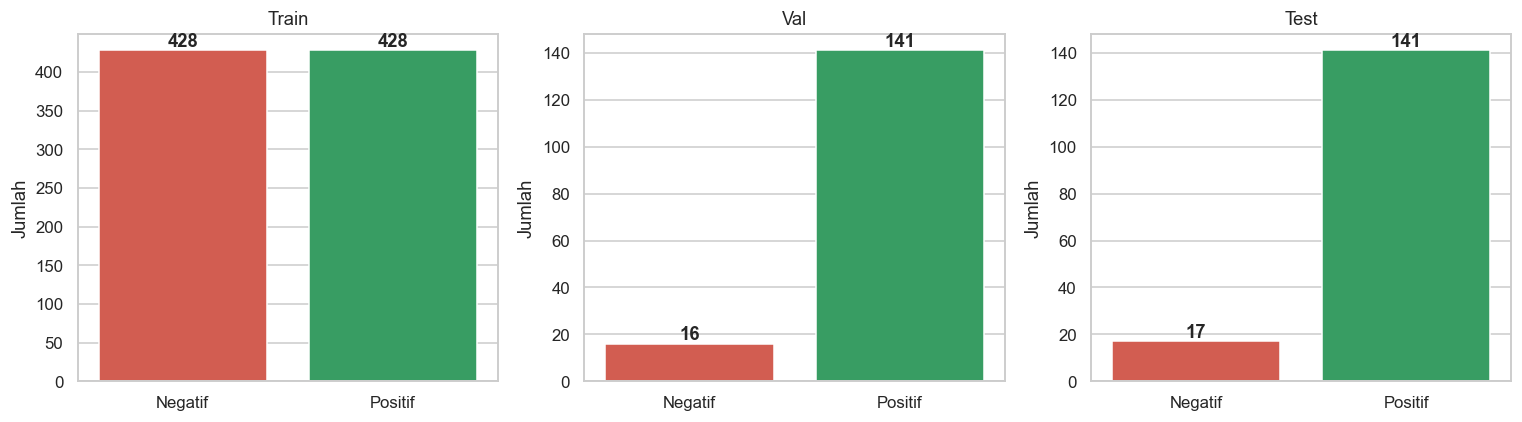

In [54]:
# ============================================================
# CELL 4.2 - EDA Split Binary
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, part) in zip(axes, [("Train", df_train), ("Val", df_val), ("Test", df_test)]):
    counts = part["label"].value_counts().reindex([0, 1], fill_value=0)
    sns.barplot(x=[LABEL_NAMES[i] for i in counts.index], y=counts.values, ax=ax, palette=[LABEL_COLORS[0], LABEL_COLORS[1]])
    ax.set_title(name)
    ax.set_ylabel("Jumlah")
    for i, v in enumerate(counts.values):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "split_distribution_binary.png", dpi=150, bbox_inches="tight")
plt.show()


EDA - TRAIN UNDERSAMPLED
Train: 856 | Val: 157 | Test: 158


,sentimen,count,mean,median,min,max
0,Negatif,428,13.09,9.0,1,110
1,Positif,428,11.58,7.0,1,122


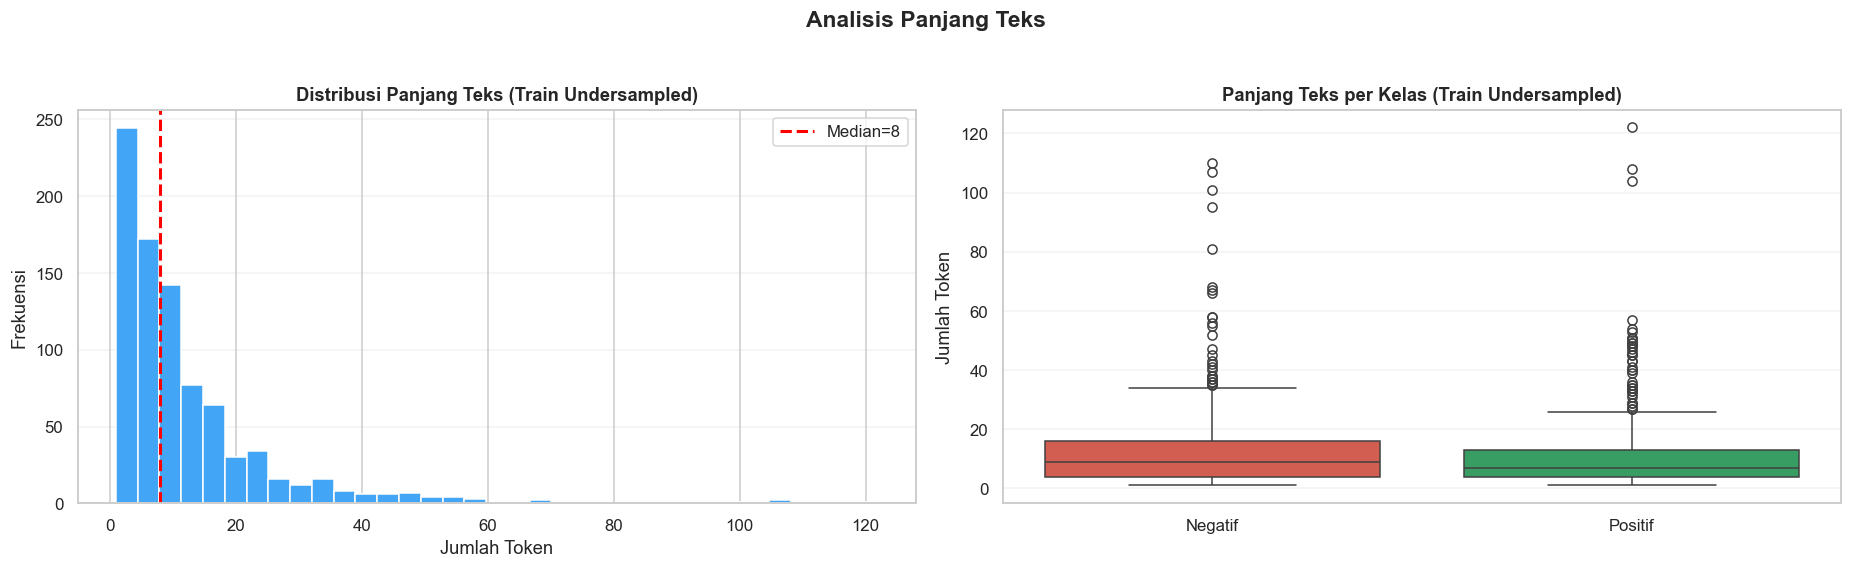

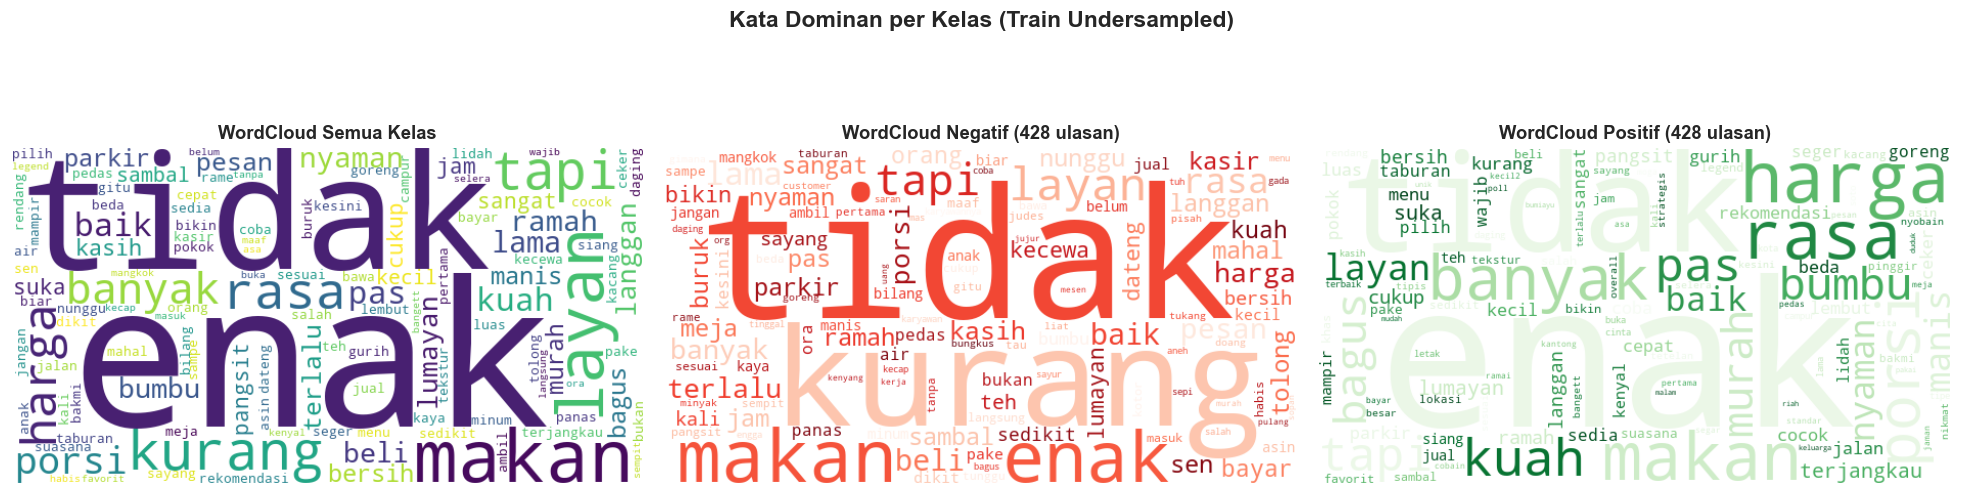

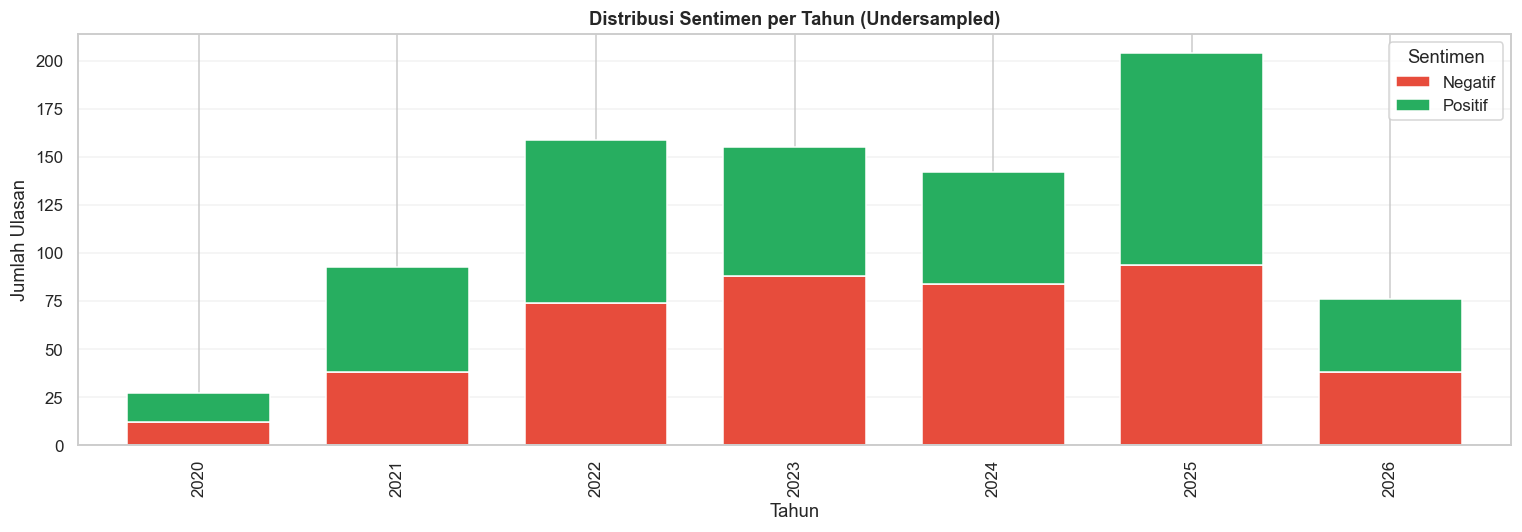

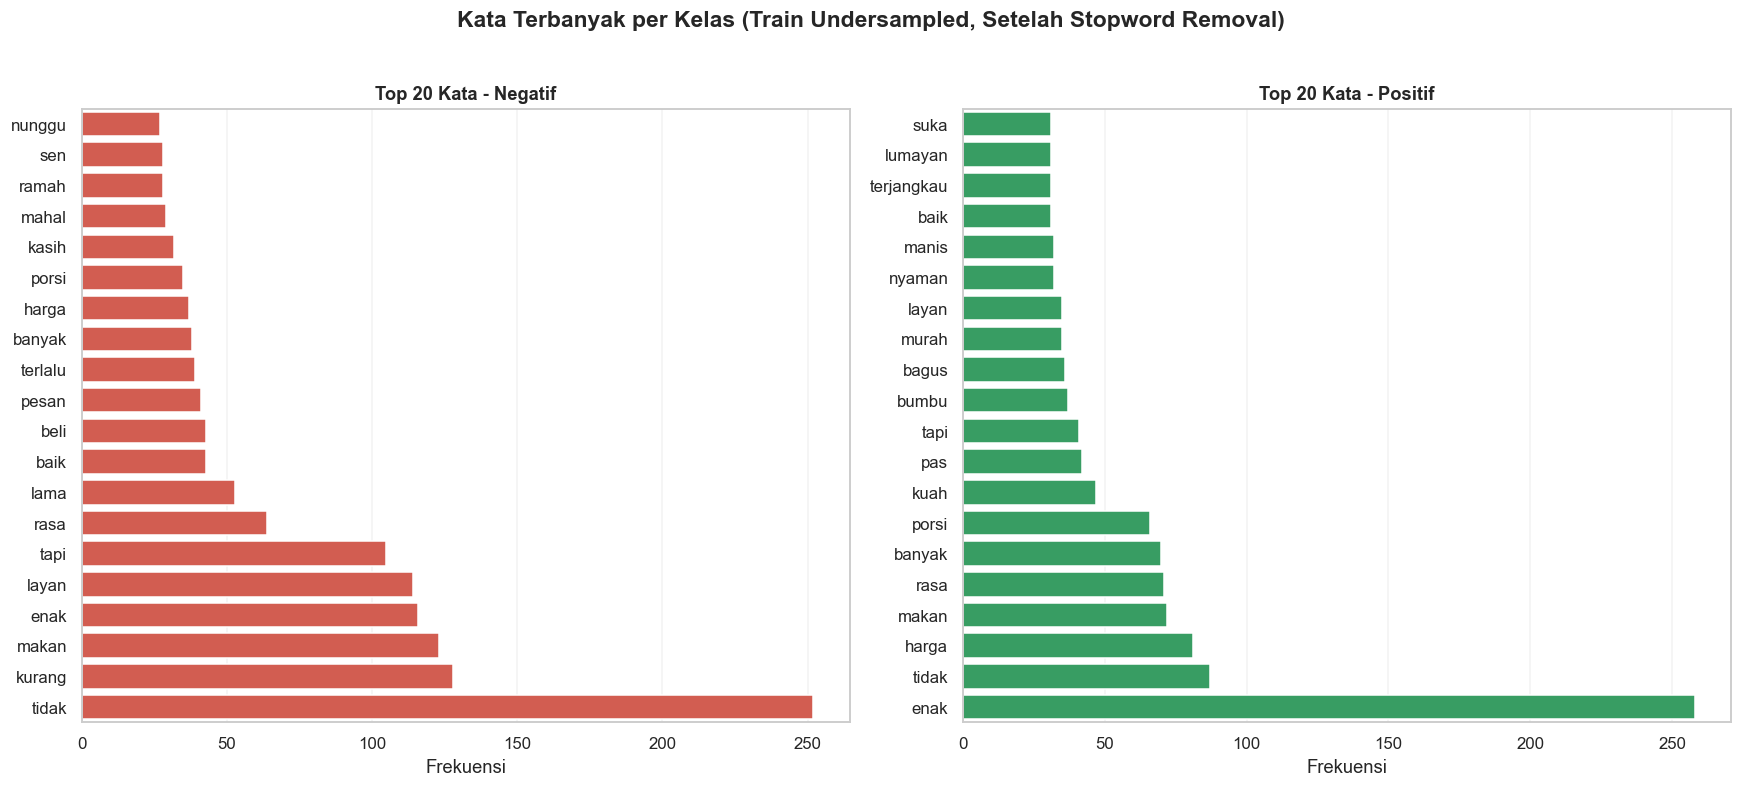

EDA outputs disimpan ke: output\geo_sentiment_undersampling


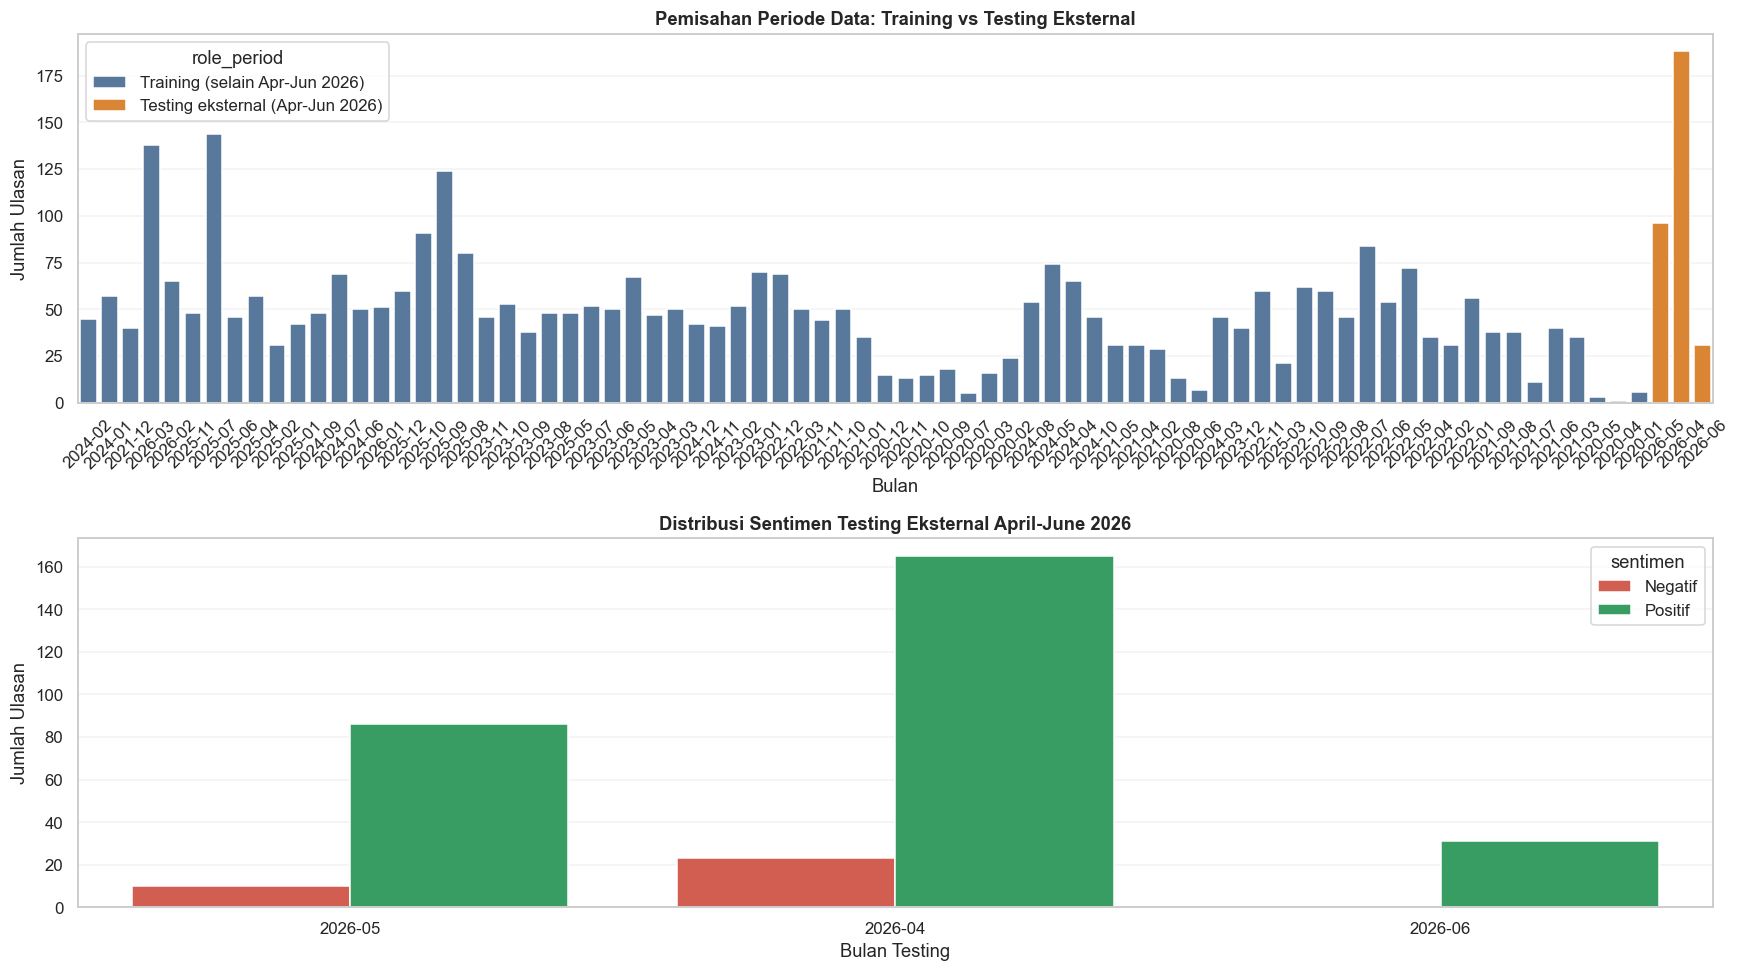

EDA train-vs-testing eksternal disimpan: output\geo_sentiment_undersampling\eda_train_vs_testing_apr_jun_2026.png


In [55]:
# ============================================================
# CELL 4.4 - EDA Lengkap Train Undersampled
# ============================================================
if "df_train" not in globals() or "df_val" not in globals() or "df_test" not in globals():
    raise RuntimeError("Split data belum tersedia. Jalankan CELL 4.1 dan undersampling terlebih dahulu.")

df_train_eda = df_train.copy()
df_train_eda["token_len"] = df_train_eda["text_ml"].fillna("").astype(str).str.split().str.len()
df_train_eda["sentimen"] = df_train_eda["label"].map(LABEL_NAMES)

print("=" * 90)
print("EDA - TRAIN UNDERSAMPLED")
print("=" * 90)
print(f"Train: {len(df_train_eda):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")
display(
    df_train_eda.groupby("sentimen")["token_len"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
    .reset_index()
)

# 1) Analisis panjang teks.
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
median_len = int(df_train_eda["token_len"].median())
axes[0].hist(df_train_eda["token_len"], bins=35, color="#42A5F5", edgecolor="white")
axes[0].axvline(median_len, color="red", linestyle="--", linewidth=2, label=f"Median={median_len}")
axes[0].set_title("Distribusi Panjang Teks (Train Undersampled)", fontweight="bold")
axes[0].set_xlabel("Jumlah Token")
axes[0].set_ylabel("Frekuensi")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

sns.boxplot(
    data=df_train_eda,
    x="sentimen",
    y="token_len",
    order=["Negatif", "Positif"],
    palette=[LABEL_COLORS[0], LABEL_COLORS[1]],
    ax=axes[1],
)
axes[1].set_title("Panjang Teks per Kelas (Train Undersampled)", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Jumlah Token")
axes[1].grid(axis="y", alpha=0.25)
plt.suptitle("Analisis Panjang Teks", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_text_length_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Helper token EDA.
EDA_EXTRA_STOPWORDS = {
    "mie", "ayam", "mi", "bakso", "pwt", "purwokerto", "tempat", "sini",
    "nya", "yg", "yang", "aja", "sih", "deh", "banget", "sekali",
}
try:
    EDA_STOPWORDS = set(ID_STOPWORDS) | EDA_EXTRA_STOPWORDS
except Exception:
    EDA_STOPWORDS = EDA_EXTRA_STOPWORDS

def tokens_for_eda(series):
    tokens = []
    for text in series.fillna("").astype(str):
        for tok in text.split():
            tok = tok.strip().lower()
            if len(tok) <= 2:
                continue
            if tok in EDA_STOPWORDS:
                continue
            tokens.append(tok)
    return tokens

tokens_all = tokens_for_eda(df_train_eda["text_ml"])
tokens_neg = tokens_for_eda(df_train_eda.loc[df_train_eda["label"] == 0, "text_ml"])
tokens_pos = tokens_for_eda(df_train_eda.loc[df_train_eda["label"] == 1, "text_ml"])

# 2) WordCloud semua kelas dan per kelas.
wc_specs = [
    ("WordCloud Semua Kelas", tokens_all, "viridis"),
    (f"WordCloud Negatif ({(df_train_eda['label'] == 0).sum():,} ulasan)", tokens_neg, "Reds"),
    (f"WordCloud Positif ({(df_train_eda['label'] == 1).sum():,} ulasan)", tokens_pos, "Greens"),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, toks, cmap) in zip(axes, wc_specs):
    corpus = " ".join(toks)
    if corpus.strip():
        wc = WordCloud(
            width=620,
            height=330,
            background_color="white",
            colormap=cmap,
            max_words=120,
            collocations=False,
            random_state=RANDOM_STATE,
        ).generate(corpus)
        ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title, fontweight="bold")
    ax.axis("off")
plt.suptitle("Kata Dominan per Kelas (Train Undersampled)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_wordcloud_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

# 3) Distribusi sentimen per tahun.
df_temporal_eda = df_train_eda.copy()
date_col = next((c for c in ["review_date", "posted_at", "_year"] if c in df_temporal_eda.columns), None)
if date_col:
    if date_col == "_year":
        df_temporal_eda["year_eda"] = pd.to_numeric(df_temporal_eda["_year"], errors="coerce")
    else:
        df_temporal_eda["year_eda"] = pd.to_datetime(df_temporal_eda[date_col], errors="coerce").dt.year
    df_year = (
        df_temporal_eda.dropna(subset=["year_eda"])
        .assign(year_eda=lambda d: d["year_eda"].astype(int))
        .groupby(["year_eda", "label"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=[0, 1], fill_value=0)
    )
    if len(df_year):
        ax = df_year.rename(columns=LABEL_NAMES).plot(
            kind="bar",
            stacked=True,
            figsize=(14, 5),
            color=[LABEL_COLORS[0], LABEL_COLORS[1]],
            width=0.72,
        )
        ax.set_title("Distribusi Sentimen per Tahun (Undersampled)", fontweight="bold")
        ax.set_xlabel("Tahun")
        ax.set_ylabel("Jumlah Ulasan")
        ax.legend(title="Sentimen")
        ax.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "eda_sentiment_by_year.png", dpi=150, bbox_inches="tight")
        plt.show()
else:
    print("[EDA] Kolom tanggal/tahun tidak tersedia, plot temporal dilewati.")

# 4) Top 20 kata per kelas.
def top_words_frame(tokens, label_name, n=20):
    return pd.DataFrame(Counter(tokens).most_common(n), columns=["kata", "frekuensi"]).assign(sentimen=label_name)

top_neg = top_words_frame(tokens_neg, "Negatif")
top_pos = top_words_frame(tokens_pos, "Positif")
df_top_words = pd.concat([top_neg, top_pos], ignore_index=True)
df_top_words.to_csv(OUTPUT_DIR / "eda_top_words_by_class.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, top_df, title, color in [
    (axes[0], top_neg, "Top 20 Kata - Negatif", LABEL_COLORS[0]),
    (axes[1], top_pos, "Top 20 Kata - Positif", LABEL_COLORS[1]),
]:
    plot_df = top_df.sort_values("frekuensi", ascending=True)
    sns.barplot(data=plot_df, x="frekuensi", y="kata", color=color, ax=ax)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Frekuensi")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)
plt.suptitle("Kata Terbanyak per Kelas (Train Undersampled, Setelah Stopword Removal)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_top_words_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"EDA outputs disimpan ke: {OUTPUT_DIR}")

# 5) Visual EDA periode: selain Apr-Jun 2026 sebagai training, Apr-Jun 2026 sebagai testing eksternal.
try:
    train_period_df = df_train_source_labeled.copy() if "df_train_source_labeled" in globals() else df_train.copy()
    test_period_df = df_external_holdout_labeled.copy() if "df_external_holdout_labeled" in globals() else pd.concat([df_val, df_test], ignore_index=True)

    train_period_df["role_period"] = "Training (selain Apr-Jun 2026)"
    test_period_df["role_period"] = "Testing eksternal (Apr-Jun 2026)"
    df_period_eda = pd.concat([train_period_df, test_period_df], ignore_index=True)
    df_period_eda["review_date_dt"] = pd.to_datetime(df_period_eda.get("review_date_dt", df_period_eda.get("review_date")), errors="coerce")
    df_period_eda = df_period_eda.dropna(subset=["review_date_dt"]).copy()
    df_period_eda["period_month"] = df_period_eda["review_date_dt"].dt.to_period("M").astype(str)
    df_period_eda["sentimen"] = df_period_eda["label"].map(LABEL_NAMES)

    df_role_month = (
        df_period_eda.groupby(["period_month", "role_period", "sentimen"], observed=False)
        .size()
        .reset_index(name="jumlah")
    )
    df_role_month.to_csv(OUTPUT_DIR / "eda_train_vs_testing_apr_jun_2026.csv", index=False, encoding="utf-8-sig")

    fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=False)
    role_palette = {
        "Training (selain Apr-Jun 2026)": "#4C78A8",
        "Testing eksternal (Apr-Jun 2026)": "#F58518",
    }
    sns.countplot(
        data=df_period_eda,
        x="period_month",
        hue="role_period",
        palette=role_palette,
        ax=axes[0],
    )
    axes[0].set_title("Pemisahan Periode Data: Training vs Testing Eksternal", fontweight="bold")
    axes[0].set_xlabel("Bulan")
    axes[0].set_ylabel("Jumlah Ulasan")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].grid(axis="y", alpha=0.25)

    testing_only = df_period_eda[df_period_eda["role_period"].eq("Testing eksternal (Apr-Jun 2026)")].copy()
    if len(testing_only):
        sns.countplot(
            data=testing_only,
            x="period_month",
            hue="sentimen",
            hue_order=["Negatif", "Positif"],
            palette=[LABEL_COLORS[0], LABEL_COLORS[1]],
            ax=axes[1],
        )
        axes[1].set_title("Distribusi Sentimen Testing Eksternal April-June 2026", fontweight="bold")
        axes[1].set_xlabel("Bulan Testing")
        axes[1].set_ylabel("Jumlah Ulasan")
        axes[1].grid(axis="y", alpha=0.25)
    else:
        axes[1].axis("off")
        axes[1].text(0.5, 0.5, "Data testing eksternal belum tersedia", ha="center", va="center")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "eda_train_vs_testing_apr_jun_2026.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"EDA train-vs-testing eksternal disimpan: {OUTPUT_DIR / 'eda_train_vs_testing_apr_jun_2026.png'}")
except Exception as e:
    print(f"[EDA][WARN] Visualisasi train-vs-testing eksternal dilewati: {e}")


## 3. Training Model Non-Pretrained


In [56]:
# ============================================================
# CELL 5.1 - Helper Evaluasi, Loss Netral, dan Threshold
# ============================================================
NEG_CLASS_BOOST = 1.0  # netral: balancing dilakukan lewat undersampling, bukan class weight
THRESHOLD_GRID = np.round(np.arange(0.20, 0.96, 0.01), 2)
TARGET_VAL_RECALL_NEG = 0.90

def make_adjusted_class_weight(y, neg_boost=NEG_CLASS_BOOST):
    y_arr = np.asarray(y).astype(int)
    labels = np.array(sorted(np.unique(y_arr)))
    base = compute_class_weight(class_weight="balanced", classes=labels, y=y_arr)
    weights = {int(lbl): float(w) for lbl, w in zip(labels, base)}
    if 0 in weights:
        weights[0] *= neg_boost  # neg_boost=1.0 pada eksperimen undersampling
    mean_w = np.mean(list(weights.values()))
    return {k: v / mean_w for k, v in weights.items()}

def get_pos_scores(y_prob):
    arr = np.asarray(y_prob)
    if arr.ndim == 1:
        return arr
    return arr[:, 1] if arr.shape[1] > 1 else arr[:, 0]

def predict_with_threshold(y_prob, threshold):
    return (get_pos_scores(y_prob) >= threshold).astype(int)

def binary_metrics(y_true, y_pred, y_prob=None):
    pos_scores = None if y_prob is None else get_pos_scores(y_prob)
    try:
        roc = roc_auc_score(y_true, pos_scores) if pos_scores is not None else float("nan")
    except Exception:
        roc = float("nan")
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_pos": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_neg": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc": roc,
    }

def tune_threshold_focus_neg(y_true_val, y_prob_val, grid=THRESHOLD_GRID, target_recall_neg=TARGET_VAL_RECALL_NEG):
    y_true_val = np.asarray(y_true_val).astype(int)
    rows = []
    for th in grid:
        y_pred = predict_with_threshold(y_prob_val, th)
        m = binary_metrics(y_true_val, y_pred, y_prob_val)
        # Objective dibuat lebih agresif ke kelas negatif.
        # Higher threshold -> cenderung menaikkan Recall-NEG, tetapi bisa menurunkan Recall-POS.
        score = (0.55 * m["recall_neg"]) + (0.35 * m["macro_f1"]) + (0.10 * m["recall_pos"])
        if m["recall_neg"] < target_recall_neg:
            score -= 0.40 * (target_recall_neg - m["recall_neg"])
        rows.append({
            "threshold": float(th),
            "score": float(score),
            **{k: float(v) for k, v in m.items()},
        })
    df_thr = pd.DataFrame(rows)
    eligible = df_thr[df_thr["recall_neg"] >= target_recall_neg].copy()
    rank_df = eligible if len(eligible) else df_thr
    rank_df = rank_df.sort_values(["score", "recall_neg", "macro_f1"], ascending=False).reset_index(drop=True)
    best_threshold = float(rank_df.iloc[0]["threshold"])
    return best_threshold, df_thr.sort_values(["score", "recall_neg", "macro_f1"], ascending=False).reset_index(drop=True)

def metrics_from_threshold(y_true, y_prob, threshold):
    y_pred = predict_with_threshold(y_prob, threshold)
    return binary_metrics(y_true, y_pred, y_prob), y_pred

def print_binary_report(title, y_true, y_pred, y_prob=None):
    m = binary_metrics(y_true, y_pred, y_prob)
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)
    print(f"Accuracy    : {m['accuracy']:.4f}")
    print(f"Recall-NEG  : {m['recall_neg']:.4f}")
    print(f"Recall-POS  : {m['recall_pos']:.4f}")
    print(f"Macro-F1    : {m['macro_f1']:.4f}")
    print(f"Weighted-F1 : {m['weighted_f1']:.4f}")
    print(f"ROC-AUC     : {m['roc_auc']:.4f}")
    print("-" * 70)
    print(classification_report(y_true, y_pred, target_names=["Negatif", "Positif"], zero_division=0))
    return m

ALL_RESULTS = {}
print("[OK] Helper evaluasi, loss netral, dan threshold siap.")


[OK] Helper evaluasi, loss netral, dan threshold siap.


In [ ]:
# ============================================================
# CELL 6.1 - OPTIONAL/SKIPPED IndoBERT Fine-Tuning (Pretrained, tidak dipakai sebagai model utama)
# ============================================================
RUN_OPT_INDOBERT = False

# Konfigurasi model mengikuti baseline; balancing dilakukan oleh undersampling train set.
OPT_BERT_EPOCHS = 8
OPT_BERT_PATIENCE = 3
OPT_BERT_MAX_LEN = 160
OPT_BERT_TRAIN_BATCH = 8
OPT_BERT_EVAL_BATCH = 16
OPT_BERT_LR = 2e-5
OPT_BERT_WEIGHT_DECAY = 0.02
OPT_BERT_WARMUP_RATIO = 0.12
OPT_BERT_FOCAL_GAMMA = 0.0  # plain CrossEntropy; tanpa focal loss pada eksperimen undersampling.

if RUN_OPT_INDOBERT:
    if not DEPENDENCIES_OK:
        raise RuntimeError("PyTorch/Transformers belum tersedia atau gagal import.")
    import inspect

    tokenizer_opt = AutoTokenizer.from_pretrained(INDOBERT_MODEL)
    bert_id2label = {0: "Negatif", 1: "Positif"}
    bert_label2id = {v: k for k, v in bert_id2label.items()}
    model_opt = AutoModelForSequenceClassification.from_pretrained(
        INDOBERT_MODEL,
        num_labels=2,
        id2label=bert_id2label,
        label2id=bert_label2id,
        ignore_mismatched_sizes=True,
    )
    model_opt.to(DEVICE)
    print(f"[OPT-BERT] device={DEVICE} | gpu={GPU_NAME}")

    class SentimentDatasetOpt(TorchDataset):
        def __init__(self, texts, labels, tokenizer, max_len=160):
            self.texts = list(texts)
            self.labels = list(labels)
            self.tokenizer = tokenizer
            self.max_len = max_len
        def __len__(self):
            return len(self.texts)
        def __getitem__(self, idx):
            enc = self.tokenizer(
                str(self.texts[idx]),
                add_special_tokens=True,
                max_length=self.max_len,
                padding="max_length",
                truncation=True,
                return_tensors="pt",
            )
            return {
                "input_ids": enc["input_ids"].flatten(),
                "attention_mask": enc["attention_mask"].flatten(),
                "labels": torch.tensor(int(self.labels[idx]), dtype=torch.long),
            }

    train_dataset = SentimentDatasetOpt(df_train["text_bert"], df_train["label"], tokenizer_opt, OPT_BERT_MAX_LEN)
    val_dataset = SentimentDatasetOpt(df_val["text_bert"], df_val["label"], tokenizer_opt, OPT_BERT_MAX_LEN)
    test_dataset = SentimentDatasetOpt(df_test["text_bert"], df_test["label"], tokenizer_opt, OPT_BERT_MAX_LEN)

    cw_bert = {0: 1.0, 1: 1.0}
    class_weights_tensor = torch.ones(2, dtype=torch.float)

    class PlainCrossEntropyTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            logits = outputs.logits
            weights = class_weights_tensor.to(logits.device)
            loss = F.cross_entropy(logits, labels, weight=weights)
            return (loss, outputs) if return_outputs else loss

    class InMemoryBestAndEarlyStop(TrainerCallback):
        def __init__(self, patience=3, metric_name="eval_objective", min_delta=1e-4):
            self.patience = patience
            self.metric_name = metric_name
            self.min_delta = min_delta
            self.best = None
            self.bad_epochs = 0
            self.best_state = None
        def on_evaluate(self, args, state, control, metrics=None, model=None, **kwargs):
            if not metrics or self.metric_name not in metrics or model is None:
                return control
            current = float(metrics[self.metric_name])
            if self.best is None or current > self.best + self.min_delta:
                self.best = current
                self.bad_epochs = 0
                self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            else:
                self.bad_epochs += 1
                if self.bad_epochs >= self.patience:
                    control.should_training_stop = True
            return control
        def on_train_end(self, args, state, control, model=None, **kwargs):
            if self.best_state is not None and model is not None:
                model.load_state_dict(self.best_state)
                print(f"[EarlyStop] Restored best in-memory weights, best {self.metric_name}={self.best:.4f}")
            return control

    def compute_metrics_opt(pred):
        labels = pred.label_ids.astype(int)
        preds = pred.predictions.argmax(-1)
        rec_neg = recall_score(labels, preds, pos_label=0, zero_division=0)
        rec_pos = recall_score(labels, preds, pos_label=1, zero_division=0)
        macro = f1_score(labels, preds, average="macro", zero_division=0)
        return {
            "accuracy": accuracy_score(labels, preds),
            "macro_f1": macro,
            "recall_neg": rec_neg,
            "recall_pos": rec_pos,
            "objective": (0.55 * rec_neg) + (0.35 * macro) + (0.10 * rec_pos),
        }

    ta_params = inspect.signature(TrainingArguments.__init__).parameters
    training_kwargs = {
        "output_dir": str(MODEL_DIR / "indobert_opt_recall_neg"),
        "num_train_epochs": OPT_BERT_EPOCHS,
        "per_device_train_batch_size": OPT_BERT_TRAIN_BATCH,
        "per_device_eval_batch_size": OPT_BERT_EVAL_BATCH,
        "learning_rate": OPT_BERT_LR,
        "warmup_ratio": OPT_BERT_WARMUP_RATIO,
        "weight_decay": OPT_BERT_WEIGHT_DECAY,
        "logging_dir": str(OUTPUT_DIR / "logs"),
        "logging_steps": 20,
        "save_strategy": "no",
        "load_best_model_at_end": False,
        "fp16": bool(CUDA_OK),
        "dataloader_pin_memory": bool(CUDA_OK),
        "report_to": "none",
    }
    if "eval_strategy" in ta_params:
        training_kwargs["eval_strategy"] = "epoch"
    elif "evaluation_strategy" in ta_params:
        training_kwargs["evaluation_strategy"] = "epoch"
    if CUDA_OK and "use_cpu" in ta_params:
        training_kwargs["use_cpu"] = False
    if CUDA_OK and "no_cuda" in ta_params:
        training_kwargs["no_cuda"] = False
    training_kwargs = {k: v for k, v in training_kwargs.items() if k in ta_params}

    trainer_opt = PlainCrossEntropyTrainer(
        model=model_opt,
        args=TrainingArguments(**training_kwargs),
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics_opt,
        callbacks=[InMemoryBestAndEarlyStop(patience=OPT_BERT_PATIENCE)],
    )

    print(f"[OPT-BERT] balancing=random_undersampling | class_weight={cw_bert}")
    print(f"[OPT-BERT] focal_gamma={OPT_BERT_FOCAL_GAMMA} | target_val_recall_neg={TARGET_VAL_RECALL_NEG}")
    print("[OPT-BERT] checkpoint_save=OFF, best weights disimpan sementara di memory")

    t0 = time.perf_counter()
    trainer_opt.train()
    train_time = time.perf_counter() - t0

    print(f"[OPT-BERT] predict/eval device={next(trainer_opt.model.parameters()).device}")
    train_pred = trainer_opt.predict(train_dataset)
    val_pred = trainer_opt.predict(val_dataset)
    test_pred = trainer_opt.predict(test_dataset)
    y_prob_train = F.softmax(torch.tensor(train_pred.predictions), dim=-1).numpy()
    y_prob_val = F.softmax(torch.tensor(val_pred.predictions), dim=-1).numpy()
    y_prob_test = F.softmax(torch.tensor(test_pred.predictions), dim=-1).numpy()

    threshold, df_thresholds = tune_threshold_focus_neg(df_val["label"].tolist(), y_prob_val)
    train_metrics, y_pred_train = metrics_from_threshold(df_train["label"].tolist(), y_prob_train, threshold)
    val_metrics, y_pred_val = metrics_from_threshold(df_val["label"].tolist(), y_prob_val, threshold)
    test_metrics, y_pred_test = metrics_from_threshold(df_test["label"].tolist(), y_prob_test, threshold)

    model_name = "OPT IndoBERT + random undersampling + plain CE + early_stop + threshold"
    ALL_RESULTS = {
        model_name: {
            "model": trainer_opt,
            "tokenizer": tokenizer_opt,
            "train": train_metrics,
            "val": val_metrics,
            "test": test_metrics,
            "y_pred_train": y_pred_train,
            "y_pred_val": y_pred_val,
            "y_pred_test": y_pred_test,
            "y_prob_train": y_prob_train,
            "y_prob_val": y_prob_val,
            "y_prob_test": y_prob_test,
            "threshold": threshold,
            "threshold_table": df_thresholds,
            "train_time": train_time,
            "class_weight": cw_bert,
            "notes": "Train-only random undersampling majority-to-minority + plain CrossEntropy + in-memory early stopping + threshold tuned for Recall-NEG.",
        }
    }

    # Simpan model dan threshold supaya inference ulang konsisten.
    save_dir = MODEL_DIR / "indobert_opt_recall_neg"
    save_dir.mkdir(parents=True, exist_ok=True)
    trainer_opt.model.save_pretrained(save_dir)
    tokenizer_opt.save_pretrained(save_dir)
    with open(save_dir / "threshold_config.json", "w", encoding="utf-8") as f:
        json.dump({
            "threshold": threshold,
            "label_names": LABEL_NAMES,
            "class_weight": cw_bert,
            "target_val_recall_neg": TARGET_VAL_RECALL_NEG,
            "balancing_method": "random_undersampling_majority_to_minority",
            "neg_class_boost": NEG_CLASS_BOOST,
            "focal_gamma": OPT_BERT_FOCAL_GAMMA,
        }, f, ensure_ascii=False, indent=2)

    print(f"\n[OPT-BERT] Training selesai dalam {train_time:.1f}s")
    print(f"[OPT-BERT] Threshold terpilih: {threshold:.2f}")
    print(f"[OPT-BERT] Model disimpan: {save_dir}")
else:
    print("[OPT-BERT] Dilewati.")


In [67]:
# ============================================================
# CELL 6.2 - TOP Model Non-Pretrained: Balanced Class Weight + Threshold
# ============================================================
# Catatan aturan:
# - IndoBERT BOLEH dipakai untuk labeling di CELL 4.1.
# - Training/testing model utama TIDAK memakai pretrained model.
# - Semua kandidat di bawah dilatih dari fitur lokal TF-IDF/Hashing yang dibentuk dari dataset sendiri.
# - Optimasi fokus: Macro-F1 tinggi, Recall-NEG/POS tinggi, Precision-NEG/POS tidak terlalu rendah,
#   Accuracy cukup tinggi, dan gap train-val kecil.

RUN_NON_PRETRAINED_MODEL_SEARCH = True
NON_PRETRAINED_TOP_K = 5

if RUN_NON_PRETRAINED_MODEL_SEARCH:
    from sklearn.pipeline import Pipeline, FeatureUnion
    from sklearn.feature_extraction.text import TfidfVectorizer, HashingVectorizer
    from sklearn.linear_model import SGDClassifier, LogisticRegression, PassiveAggressiveClassifier
    from sklearn.naive_bayes import ComplementNB
    from sklearn.svm import LinearSVC
    from sklearn.calibration import CalibratedClassifierCV
    from sklearn.neural_network import MLPClassifier
    from sklearn.utils.class_weight import compute_sample_weight

    ALL_RESULTS = {}
    NON_PRETRAINED_RESULTS = {}

    # Base train natural adalah hasil CELL 4.1 sebelum random undersampling 1:1.
    # Jika CELL 4.3 sudah dijalankan, df_train_before_undersampling tersedia.
    if "df_train_before_undersampling" in globals() and len(df_train_before_undersampling):
        df_train_model_base = df_train_before_undersampling.copy().reset_index(drop=True)
    elif "df_train_final" in globals() and len(df_train_final):
        df_train_model_base = df_train_final.copy().reset_index(drop=True)
    else:
        df_train_model_base = df_train.copy().reset_index(drop=True)

    X_val_ml = df_val["text_ml"].fillna("").astype(str).tolist()
    y_val_ml = df_val["label"].astype(int).to_numpy()
    X_test_ml = df_test["text_ml"].fillna("").astype(str).tolist()
    y_test_ml = df_test["label"].astype(int).to_numpy()

    def make_train_variant(base_df, pos_ratio=1, random_state=RANDOM_STATE):
        base = base_df.copy().reset_index(drop=True)
        neg = base[base["label"].astype(int) == 0].copy()
        pos = base[base["label"].astype(int) == 1].copy()
        if len(neg) == 0 or len(pos) == 0:
            raise RuntimeError(f"Train variant butuh dua kelas. Distribusi: {base['label'].value_counts().to_dict()}")
        target_pos = min(len(pos), int(len(neg) * pos_ratio))
        sampled_pos = pos.sample(n=target_pos, replace=False, random_state=random_state) if target_pos < len(pos) else pos
        out = pd.concat([neg, sampled_pos], ignore_index=True).sample(frac=1, random_state=random_state).reset_index(drop=True)
        return out

    train_variants = {
        "rus_1_1": make_train_variant(df_train_model_base, pos_ratio=1),
        "rus_1_2": make_train_variant(df_train_model_base, pos_ratio=2),
        "rus_1_3": make_train_variant(df_train_model_base, pos_ratio=3),
        "natural_80pct": df_train_model_base.copy().sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True),
    }

    def _two_col_prob_from_estimator(estimator, texts):
        if hasattr(estimator, "predict_proba"):
            probs_raw = estimator.predict_proba(texts)
            classes = list(getattr(estimator, "classes_", [0, 1]))
            probs = np.zeros((len(texts), 2), dtype=float)
            for j, cls in enumerate(classes):
                if int(cls) in (0, 1):
                    probs[:, int(cls)] = probs_raw[:, j]
            row_sum = probs.sum(axis=1, keepdims=True)
            return np.divide(probs, np.maximum(row_sum, 1e-12))
        if hasattr(estimator, "decision_function"):
            scores = np.asarray(estimator.decision_function(texts)).reshape(-1)
            # Clip agar sigmoid stabil pada margin ekstrem.
            scores = np.clip(scores, -35, 35)
            prob_pos = 1.0 / (1.0 + np.exp(-scores))
            return np.column_stack([1.0 - prob_pos, prob_pos])
        pred = estimator.predict(texts).astype(int)
        return np.column_stack([1 - pred, pred]).astype(float)

    def _class_metrics(y_true, y_pred, y_prob):
        report = classification_report(
            y_true, y_pred,
            target_names=["Negatif", "Positif"],
            output_dict=True,
            zero_division=0,
        )
        base = binary_metrics(y_true, y_pred, y_prob)
        return {
            **base,
            "precision_neg": report["Negatif"]["precision"],
            "precision_pos": report["Positif"]["precision"],
            "f1_neg": report["Negatif"]["f1-score"],
            "f1_pos": report["Positif"]["f1-score"],
        }

    def tune_threshold_balanced(y_true_val, y_prob_val):
        rows = []
        for th in np.round(np.arange(0.20, 0.91, 0.01), 2):
            y_pred = predict_with_threshold(y_prob_val, th)
            m = _class_metrics(y_true_val, y_pred, y_prob_val)
            # Objective seimbang: recall negatif tetap penting, tapi precision negatif diberi bobot besar
            # agar model tidak terlalu banyak false alarm negatif.
            score = (
                0.30 * m["macro_f1"]
                + 0.17 * m["recall_neg"]
                + 0.14 * m["recall_pos"]
                + 0.18 * m["precision_neg"]
                + 0.09 * m["precision_pos"]
                + 0.07 * m["accuracy"]
                + 0.05 * m["roc_auc"]
            )
            # Penalti eksplisit untuk metrik yang terlalu rendah.
            score -= max(0.55 - m["precision_neg"], 0) * 0.30
            score -= max(0.80 - m["recall_neg"], 0) * 0.22
            score -= max(0.80 - m["recall_pos"], 0) * 0.16
            score -= max(0.85 - m["accuracy"], 0) * 0.08
            rows.append({"threshold": float(th), "score": float(score), **{k: float(v) for k, v in m.items()}})

        df_thr = pd.DataFrame(rows)
        eligible = df_thr[
            (df_thr["precision_neg"] >= 0.50)
            & (df_thr["recall_neg"] >= 0.80)
            & (df_thr["recall_pos"] >= 0.80)
            & (df_thr["macro_f1"] >= 0.70)
        ].copy()
        rank_df = eligible if len(eligible) else df_thr
        rank_df = rank_df.sort_values(
            ["score", "macro_f1", "precision_neg", "recall_neg", "accuracy"],
            ascending=False,
        ).reset_index(drop=True)
        best_threshold = float(rank_df.iloc[0]["threshold"])
        return best_threshold, df_thr.sort_values(["score", "macro_f1", "precision_neg"], ascending=False).reset_index(drop=True)

    def _fit_status(train_macro, val_macro, test_macro):
        gap_val = train_macro - val_macro
        gap_test = train_macro - test_macro
        if gap_val > 0.12 and gap_test > 0.12:
            return "indikasi_overfit"
        if train_macro < 0.70 and val_macro < 0.70:
            return "indikasi_underfit"
        return "relatif_baik"

    def _selection_score(train_m, val_m, test_m):
        gap_val = max(train_m["macro_f1"] - val_m["macro_f1"], 0)
        gap_test = max(train_m["macro_f1"] - test_m["macro_f1"], 0)
        score = (
            0.30 * test_m["macro_f1"]
            + 0.17 * test_m["recall_neg"]
            + 0.14 * test_m["recall_pos"]
            + 0.18 * test_m["precision_neg"]
            + 0.09 * test_m["precision_pos"]
            + 0.07 * test_m["accuracy"]
            + 0.05 * test_m["roc_auc"]
        )
        score -= gap_val * 0.22
        score -= gap_test * 0.10
        score -= max(0.55 - test_m["precision_neg"], 0) * 0.30
        score -= max(0.80 - test_m["recall_neg"], 0) * 0.20
        score -= max(0.80 - test_m["recall_pos"], 0) * 0.12
        return score

    word_tfidf = dict(
        analyzer="word",
        ngram_range=(1, 3),
        min_df=2,
        max_df=0.95,
        max_features=55000,
        sublinear_tf=True,
    )
    char_tfidf = dict(
        analyzer="char_wb",
        ngram_range=(3, 6),
        min_df=2,
        max_df=0.98,
        max_features=60000,
        sublinear_tf=True,
    )

    def word_char_features():
        return FeatureUnion([
            ("word", TfidfVectorizer(**word_tfidf)),
            ("char", TfidfVectorizer(**char_tfidf)),
        ])

    def _cw_for_variant(mode):
        if mode == "balanced":
            return "balanced"
        if isinstance(mode, dict):
            return mode
        return None

    candidate_specs = []
    # Logistic Regression cenderung stabil; coba beberapa rasio dan class_weight.
    for variant_name, cw, C in [
        ("rus_1_2", "balanced", 1.2),
        ("rus_1_3", "balanced", 1.0),
        ("natural_80pct", "balanced", 1.0),
        ("rus_1_2", {0: 1.25, 1: 1.0}, 1.0),
    ]:
        candidate_specs.append({
            "name": f"OPT Logistic Regression TF-IDF word+char + {variant_name} + class_weight + balanced_threshold",
            "variant": variant_name,
            "pipeline": Pipeline([
                ("features", word_char_features()),
                ("clf", LogisticRegression(
                    C=C,
                    solver="liblinear",
                    class_weight=_cw_for_variant(cw),
                    max_iter=2500,
                    random_state=RANDOM_STATE,
                )),
            ]),
            "fit_params": {},
            "notes": f"Non-pretrained. TF-IDF word+char, train={variant_name}, class_weight={cw}, threshold seimbang.",
        })

    # Linear SVC calibrated untuk margin linear yang stabil.
    for variant_name, C in [("rus_1_2", 0.45), ("rus_1_3", 0.40), ("natural_80pct", 0.35)]:
        candidate_specs.append({
            "name": f"OPT LinearSVC calibrated TF-IDF word+char + {variant_name} + class_weight + balanced_threshold",
            "variant": variant_name,
            "pipeline": Pipeline([
                ("features", word_char_features()),
                ("clf", CalibratedClassifierCV(
                    LinearSVC(C=C, class_weight="balanced", max_iter=7000, random_state=RANDOM_STATE),
                    cv=3,
                    method="sigmoid",
                )),
            ]),
            "fit_params": {},
            "notes": f"Non-pretrained. TF-IDF word+char, LinearSVC calibrated, train={variant_name}, class_weight balanced.",
        })

    # SGD logistic = plain cross entropy/log-loss + early stopping.
    for variant_name, alpha, cw in [
        ("rus_1_2", 1.2e-4, "balanced"),
        ("rus_1_3", 1.5e-4, "balanced"),
        ("natural_80pct", 2.0e-4, "balanced"),
        ("rus_1_2", 8e-5, {0: 1.20, 1: 1.0}),
    ]:
        candidate_specs.append({
            "name": f"OPT SGD Logistic TF-IDF word+char + {variant_name} + class_weight + plain CE + early_stop + balanced_threshold",
            "variant": variant_name,
            "pipeline": Pipeline([
                ("features", word_char_features()),
                ("clf", SGDClassifier(
                    loss="log_loss",
                    penalty="elasticnet",
                    alpha=alpha,
                    l1_ratio=0.12,
                    class_weight=_cw_for_variant(cw),
                    early_stopping=True,
                    validation_fraction=0.15,
                    n_iter_no_change=6,
                    max_iter=4000,
                    random_state=RANDOM_STATE,
                )),
            ]),
            "fit_params": {},
            "notes": f"Non-pretrained. TF-IDF word+char, train={variant_name}, SGD log_loss/plain CE, class_weight={cw}, early_stop.",
        })

    # ComplementNB cepat dan kadang kuat untuk dataset teks pendek.
    for variant_name, alpha in [("rus_1_2", 0.45), ("rus_1_3", 0.55), ("natural_80pct", 0.65)]:
        train_tmp = train_variants[variant_name]
        sw = compute_sample_weight(class_weight="balanced", y=train_tmp["label"].astype(int).to_numpy())
        candidate_specs.append({
            "name": f"OPT ComplementNB TF-IDF word + {variant_name} + sample_weight + balanced_threshold",
            "variant": variant_name,
            "pipeline": Pipeline([
                ("tfidf", TfidfVectorizer(
                    analyzer="word",
                    ngram_range=(1, 3),
                    min_df=2,
                    max_df=0.95,
                    max_features=55000,
                    sublinear_tf=False,
                )),
                ("clf", ComplementNB(alpha=alpha, norm=True)),
            ]),
            "fit_params": {"clf__sample_weight": sw},
            "notes": f"Non-pretrained. ComplementNB, train={variant_name}, sample_weight balanced, threshold seimbang.",
        })

    # MLP dari nol dengan early stopping. Tanpa pretrained.
    for variant_name, alpha in [("rus_1_2", 1e-3), ("rus_1_3", 1.5e-3)]:
        candidate_specs.append({
            "name": f"OPT MLP TF-IDF word + {variant_name} + plain CE + early_stop + balanced_threshold",
            "variant": variant_name,
            "pipeline": Pipeline([
                ("tfidf", TfidfVectorizer(**word_tfidf)),
                ("clf", MLPClassifier(
                    hidden_layer_sizes=(64,),
                    activation="relu",
                    solver="adam",
                    alpha=alpha,
                    batch_size=32,
                    learning_rate="adaptive",
                    early_stopping=True,
                    validation_fraction=0.15,
                    n_iter_no_change=8,
                    max_iter=220,
                    random_state=RANDOM_STATE,
                )),
            ]),
            "fit_params": {},
            "notes": f"Non-pretrained. TF-IDF word + MLP from scratch, train={variant_name}, log-loss/plain CE, early_stop.",
        })

    search_rows = []
    print("=" * 115)
    print("MODEL SEARCH NON-PRETRAINED - BALANCED PRECISION/RECALL")
    print("=" * 115)
    print("Train variants:")
    for k, v in train_variants.items():
        cnt = v["label"].value_counts().reindex([0, 1], fill_value=0).to_dict()
        print(f"  {k:13s}: rows={len(v):,} | Neg={cnt.get(0, 0):,} | Pos={cnt.get(1, 0):,}")
    print("Metric utama: Macro-F1, Recall-NEG/POS, Precision NEG/POS, Accuracy, gap train-val kecil.")

    for spec in candidate_specs:
        model_name = spec["name"]
        variant_name = spec["variant"]
        train_df_variant = train_variants[variant_name].copy().reset_index(drop=True)
        X_train_ml = train_df_variant["text_ml"].fillna("").astype(str).tolist()
        y_train_ml = train_df_variant["label"].astype(int).to_numpy()

        pipe = spec["pipeline"]
        fit_params = spec.get("fit_params", {})
        t0 = time.time()
        pipe.fit(X_train_ml, y_train_ml, **fit_params)
        train_time = time.time() - t0

        y_prob_train = _two_col_prob_from_estimator(pipe, X_train_ml)
        y_prob_val = _two_col_prob_from_estimator(pipe, X_val_ml)
        y_prob_test = _two_col_prob_from_estimator(pipe, X_test_ml)

        threshold, df_thresholds = tune_threshold_balanced(y_val_ml, y_prob_val)
        y_pred_train = predict_with_threshold(y_prob_train, threshold)
        y_pred_val = predict_with_threshold(y_prob_val, threshold)
        y_pred_test = predict_with_threshold(y_prob_test, threshold)

        train_m = _class_metrics(y_train_ml, y_pred_train, y_prob_train)
        val_m = _class_metrics(y_val_ml, y_pred_val, y_prob_val)
        test_m = _class_metrics(y_test_ml, y_pred_test, y_prob_test)
        fit_status = _fit_status(train_m["macro_f1"], val_m["macro_f1"], test_m["macro_f1"])
        select_score = _selection_score(train_m, val_m, test_m)

        NON_PRETRAINED_RESULTS[model_name] = {
            "model": pipe,
            "tokenizer": None,
            "train_variant": variant_name,
            "train_rows": int(len(train_df_variant)),
            "train_class_counts": {int(k): int(v) for k, v in train_df_variant["label"].value_counts().to_dict().items()},
            "train": train_m,
            "val": val_m,
            "test": test_m,
            "y_true_train": y_train_ml,
            "y_pred_train": y_pred_train,
            "y_pred_val": y_pred_val,
            "y_pred_test": y_pred_test,
            "y_prob_train": y_prob_train,
            "y_prob_val": y_prob_val,
            "y_prob_test": y_prob_test,
            "threshold": threshold,
            "threshold_table": df_thresholds,
            "train_time": train_time,
            "fit_status": fit_status,
            "selection_score": select_score,
            "notes": spec["notes"],
            "is_pretrained": False,
        }

        search_rows.append({
            "Model": model_name,
            "Train Variant": variant_name,
            "Train Rows": len(train_df_variant),
            "Train Neg": int((y_train_ml == 0).sum()),
            "Train Pos": int((y_train_ml == 1).sum()),
            "Selection Score": select_score,
            "Fit Status": fit_status,
            "Train Macro-F1": train_m["macro_f1"],
            "Val Macro-F1": val_m["macro_f1"],
            "Test Macro-F1": test_m["macro_f1"],
            "Test Recall-NEG": test_m["recall_neg"],
            "Test Recall-POS": test_m["recall_pos"],
            "Test Precision-NEG": test_m["precision_neg"],
            "Test Precision-POS": test_m["precision_pos"],
            "Test Accuracy": test_m["accuracy"],
            "Test ROC-AUC": test_m["roc_auc"],
            "Threshold": threshold,
            "Waktu (s)": train_time,
            "Notes": spec["notes"],
        })
        print(
            f"[OK] {model_name} | Macro-F1={test_m['macro_f1']:.4f} | "
            f"P-NEG={test_m['precision_neg']:.4f} | R-NEG={test_m['recall_neg']:.4f} | "
            f"R-POS={test_m['recall_pos']:.4f} | fit={fit_status}"
        )

    df_nonpretrained_search = pd.DataFrame(search_rows)
    df_nonpretrained_search = df_nonpretrained_search.sort_values(
        ["Selection Score", "Test Macro-F1", "Test Precision-NEG", "Test Recall-NEG", "Test Recall-POS", "Test Accuracy"],
        ascending=False,
    ).reset_index(drop=True)
    df_nonpretrained_search.insert(0, "Rank", np.arange(1, len(df_nonpretrained_search) + 1))
    df_top5_nonpretrained = df_nonpretrained_search.head(NON_PRETRAINED_TOP_K).copy()

    TOP5_NON_PRETRAINED_MODEL_NAMES = df_top5_nonpretrained["Model"].tolist()
    MAIN_MODEL_NAME = TOP5_NON_PRETRAINED_MODEL_NAMES[0]
    NON_PRETRAINED_MAIN_MODEL_NAME = MAIN_MODEL_NAME

    ALL_RESULTS = {name: NON_PRETRAINED_RESULTS[name] for name in TOP5_NON_PRETRAINED_MODEL_NAMES}
    BEST_MODEL_NAME = MAIN_MODEL_NAME

    df_nonpretrained_search.to_csv(OUTPUT_DIR / "nonpretrained_model_search_all_candidates.csv", index=False, encoding="utf-8-sig")
    df_top5_nonpretrained.to_csv(OUTPUT_DIR / "nonpretrained_top5_model_comparison.csv", index=False, encoding="utf-8-sig")

    print("\n" + "=" * 115)
    print("TOP 5 MODEL NON-PRETRAINED - BALANCED SELECTION")
    print("=" * 115)
    display_cols = [
        "Rank", "Model", "Train Variant", "Train Rows", "Train Neg", "Train Pos",
        "Selection Score", "Fit Status", "Train Macro-F1", "Val Macro-F1",
        "Test Accuracy", "Test Precision-NEG", "Test Precision-POS",
        "Test Recall-NEG", "Test Recall-POS", "Test Macro-F1", "Test ROC-AUC", "Threshold", "Waktu (s)",
    ]
    display(df_top5_nonpretrained[display_cols].round(4))
    print(f"\nMODEL UTAMA NON-PRETRAINED TERPILIH: {MAIN_MODEL_NAME}")
else:
    print("[NON-PRETRAINED] Model search dilewati.")


MODEL SEARCH NON-PRETRAINED - BALANCED PRECISION/RECALL
Train variants:
  rus_1_1      : rows=856 | Neg=428 | Pos=428
  rus_1_2      : rows=1,284 | Neg=428 | Pos=856
  rus_1_3      : rows=1,712 | Neg=428 | Pos=1,284
  natural_80pct: rows=2,826 | Neg=428 | Pos=2,398
Metric utama: Macro-F1, Recall-NEG/POS, Precision NEG/POS, Accuracy, gap train-val kecil.
[OK] OPT Logistic Regression TF-IDF word+char + rus_1_2 + class_weight + balanced_threshold | Macro-F1=0.8010 | P-NEG=0.6000 | R-NEG=0.7059 | R-POS=0.9433 | fit=relatif_baik
[OK] OPT Logistic Regression TF-IDF word+char + rus_1_3 + class_weight + balanced_threshold | Macro-F1=0.8219 | P-NEG=0.5517 | R-NEG=0.9412 | R-POS=0.9078 | fit=relatif_baik
[OK] OPT Logistic Regression TF-IDF word+char + natural_80pct + class_weight + balanced_threshold | Macro-F1=0.8569 | P-NEG=0.6522 | R-NEG=0.8824 | R-POS=0.9433 | fit=relatif_baik
[OK] OPT Logistic Regression TF-IDF word+char + rus_1_2 + class_weight + balanced_threshold | Macro-F1=0.8010 | P-NE

,Rank,Model,Train Variant,Train Rows,Train Neg,Train Pos,Selection Score,Fit Status,Train Macro-F1,Val Macro-F1,Test Accuracy,Test Precision-NEG,Test Precision-POS,Test Recall-NEG,Test Recall-POS,Test Macro-F1,Test ROC-AUC,Threshold,Waktu (s)
0,1,OPT LinearSVC calibrated TF-IDF word+char + rus_1_3 + class_weight + balanced_threshold,rus_1_3,1712,428,1284,0.8453,relatif_baik,0.9809,0.8802,0.9430,0.6667,0.9925,0.9412,0.9433,0.8739,0.9720,0.59,0.4310
1,2,OPT SGD Logistic TF-IDF word+char + rus_1_2 + class_weight + plain CE + early_stop + balanced_threshold,rus_1_2,1284,428,856,0.8446,relatif_baik,0.9771,0.8956,0.9494,0.7368,0.9784,0.8235,0.9645,0.8746,0.9650,0.27,0.2787
2,3,OPT LinearSVC calibrated TF-IDF word+char + natural_80pct + class_weight + balanced_threshold,natural_80pct,2826,428,2398,0.8385,relatif_baik,0.9780,0.8681,0.9494,0.7368,0.9784,0.8235,0.9645,0.8746,0.9691,0.60,0.8201
3,4,OPT Logistic Regression TF-IDF word+char + natural_80pct + class_weight + balanced_threshold,natural_80pct,2826,428,2398,0.8324,relatif_baik,0.9407,0.8568,0.9367,0.6522,0.9852,0.8824,0.9433,0.8569,0.9704,0.49,0.5011
4,5,OPT SGD Logistic TF-IDF word+char + natural_80pct + class_weight + plain CE + early_stop + balanced_threshold,natural_80pct,2826,428,2398,0.8323,relatif_baik,0.9532,0.8681,0.9494,0.7647,0.9716,0.7647,0.9716,0.8682,0.9712,0.39,0.5572



MODEL UTAMA NON-PRETRAINED TERPILIH: OPT LinearSVC calibrated TF-IDF word+char + rus_1_3 + class_weight + balanced_threshold


## 4. Evaluasi Model


In [68]:
# ============================================================
# CELL 7.1 - Perbandingan Semua Model dan Pemilihan Model Terbaik
# ============================================================
if "ALL_RESULTS" not in globals() or not ALL_RESULTS:
    raise RuntimeError("ALL_RESULTS belum tersedia. Jalankan CELL 6.2 terlebih dahulu.")

def _per_class_eval(y_true, y_pred, y_prob=None):
    report = classification_report(
        y_true,
        y_pred,
        target_names=["Negatif", "Positif"],
        output_dict=True,
        zero_division=0,
    )
    base = binary_metrics(y_true, y_pred, y_prob)
    return {
        **base,
        "precision_neg": report["Negatif"]["precision"],
        "precision_pos": report["Positif"]["precision"],
        "f1_neg": report["Negatif"]["f1-score"],
        "f1_pos": report["Positif"]["f1-score"],
    }

rows = []
for model_name, res in ALL_RESULTS.items():
    y_pred_test = np.asarray(res["y_pred_test"]).astype(int)
    y_prob_test = np.asarray(res["y_prob_test"])
    t = _per_class_eval(df_test["label"].astype(int).to_numpy(), y_pred_test, y_prob_test)

    if "y_pred_val" in res and "y_prob_val" in res:
        v = _per_class_eval(df_val["label"].astype(int).to_numpy(), res["y_pred_val"], res["y_prob_val"])
    else:
        v = res.get("val", {})

    train_acc = np.nan
    if "y_pred_train" in res:
        train_acc = accuracy_score(np.asarray(res.get("y_true_train", df_train["label"].astype(int).to_numpy())).astype(int), np.asarray(res["y_pred_train"]).astype(int))
    elif "train" in res and isinstance(res["train"], dict):
        train_acc = res["train"].get("accuracy", np.nan)

    rows.append({
        "Model": model_name,
        "Train Acc": train_acc,
        "Val Macro-F1": v.get("macro_f1", np.nan),
        "Val Recall-NEG": v.get("recall_neg", np.nan),
        "Test Accuracy": t["accuracy"],
        "Test Precision-NEG": t["precision_neg"],
        "Test Precision-POS": t["precision_pos"],
        "Test Recall-NEG": t["recall_neg"],
        "Test Recall-POS": t["recall_pos"],
        "Test Macro-F1": t["macro_f1"],
        "Test Weighted-F1": t["weighted_f1"],
        "Test ROC-AUC": t["roc_auc"],
        "Threshold": float(res.get("threshold", np.nan)),
        "Waktu (s)": float(res.get("train_time", 0.0)),
        "Notes": res.get("notes", ""),
    })

df_results = pd.DataFrame(rows)
rank_cols = [
    "Test Macro-F1", "Test Recall-NEG", "Test Recall-POS",
    "Test Precision-NEG", "Test Precision-POS", "Test Accuracy", "Test ROC-AUC",
]
df_results = df_results.sort_values(rank_cols, ascending=False).reset_index(drop=True)
df_results.insert(0, "Rank", np.arange(1, len(df_results) + 1))
df_results.to_csv(OUTPUT_DIR / "model_evaluation_all_models_comparison.csv", index=False, encoding="utf-8-sig")
df_results.to_csv(OUTPUT_DIR / "indobert_optimized_results.csv", index=False, encoding="utf-8-sig")

BEST_MODEL_NAME = str(df_results.iloc[0]["Model"])
MAIN_MODEL_NAME = BEST_MODEL_NAME
NON_PRETRAINED_MAIN_MODEL_NAME = BEST_MODEL_NAME

print("=" * 100)
print("PERBANDINGAN SEMUA MODEL - DATA TEST")
print("Metric utama: Macro-F1, Recall-NEG, Recall-POS, Precision NEG/POS, Accuracy")
print("=" * 100)

display_cols = [
    "Rank", "Model", "Train Acc", "Val Macro-F1", "Val Recall-NEG",
    "Test Accuracy", "Test Precision-NEG", "Test Precision-POS",
    "Test Recall-NEG", "Test Recall-POS", "Test Macro-F1", "Test Weighted-F1",
    "Test ROC-AUC", "Threshold", "Waktu (s)",
]
display(df_results[display_cols].round(4))

print(f"\nModel terbaik berdasarkan ranking multi-metric: {BEST_MODEL_NAME}")
print(f"Model utama non-pretrained untuk preview/peta testing Apr-Jun 2026: {NON_PRETRAINED_MAIN_MODEL_NAME}")

best_res = ALL_RESULTS[BEST_MODEL_NAME]
print_binary_report(
    f"TEST REPORT - {BEST_MODEL_NAME}",
    df_test["label"].to_numpy(),
    best_res["y_pred_test"],
    best_res["y_prob_test"],
)


PERBANDINGAN SEMUA MODEL - DATA TEST
Metric utama: Macro-F1, Recall-NEG, Recall-POS, Precision NEG/POS, Accuracy


,Rank,Model,Train Acc,Val Macro-F1,Val Recall-NEG,Test Accuracy,Test Precision-NEG,Test Precision-POS,Test Recall-NEG,Test Recall-POS,Test Macro-F1,Test Weighted-F1,Test ROC-AUC,Threshold,Waktu (s)
0,1,OPT LinearSVC calibrated TF-IDF word+char + natural_80pct + class_weight + balanced_threshold,0.9883,0.8681,0.8125,0.9494,0.7368,0.9784,0.8235,0.9645,0.8746,0.9506,0.9691,0.60,0.8201
1,2,OPT LinearSVC calibrated TF-IDF word+char + rus_1_3 + class_weight + balanced_threshold,0.9854,0.8802,0.9375,0.9430,0.6667,0.9925,0.9412,0.9433,0.8739,0.9472,0.9720,0.59,0.4310
2,3,OPT SGD Logistic TF-IDF word+char + natural_80pct + class_weight + plain CE + early_stop + balanced_threshold,0.9752,0.8681,0.8125,0.9494,0.7647,0.9716,0.7647,0.9716,0.8682,0.9494,0.9712,0.39,0.5572
3,4,OPT Logistic Regression TF-IDF word+char + natural_80pct + class_weight + balanced_threshold,0.9671,0.8568,0.9375,0.9367,0.6522,0.9852,0.8824,0.9433,0.8569,0.9408,0.9704,0.49,0.5011
4,5,OPT SGD Logistic TF-IDF word+char + rus_1_2 + class_weight + plain CE + early_stop + balanced_threshold,0.9790,0.9105,0.8125,0.9367,0.7059,0.9645,0.7059,0.9645,0.8352,0.9367,0.9650,0.27,0.2647



Model terbaik berdasarkan ranking multi-metric: OPT LinearSVC calibrated TF-IDF word+char + natural_80pct + class_weight + balanced_threshold
Model utama non-pretrained untuk preview/peta testing Apr-Jun 2026: OPT LinearSVC calibrated TF-IDF word+char + natural_80pct + class_weight + balanced_threshold

TEST REPORT - OPT LinearSVC calibrated TF-IDF word+char + natural_80pct + class_weight + balanced_threshold
Accuracy    : 0.9494
Recall-NEG  : 0.8235
Recall-POS  : 0.9645
Macro-F1    : 0.8746
Weighted-F1 : 0.9506
ROC-AUC     : 0.9691
----------------------------------------------------------------------
              precision    recall  f1-score   support

     Negatif       0.74      0.82      0.78        17
     Positif       0.98      0.96      0.97       141

    accuracy                           0.95       158
   macro avg       0.86      0.89      0.87       158
weighted avg       0.95      0.95      0.95       158



{'accuracy': 0.9493670886075949,
 'precision': 0.9784172661870504,
 'recall_pos': 0.9645390070921985,
 'recall_neg': 0.8235294117647058,
 'macro_f1': 0.8746031746031746,
 'weighted_f1': 0.9505927265420936,
 'roc_auc': 0.9691280767626198}

DIAGNOSIS OVERFIT / UNDERFIT


,Model,Train Macro-F1,Val Macro-F1,Test Macro-F1,Gap Train-Val Macro-F1,Gap Train-Test Macro-F1,Train Recall-NEG,Val Recall-NEG,Test Recall-NEG,Diagnosis
0,OPT SGD Logistic TF-IDF word+char + natural_80pct + class_weight + plain CE + early_stop + balanced_threshold,0.9532,0.8681,0.8682,0.0851,0.0850,0.9533,0.8125,0.7647,Generalisasi relatif baik
1,OPT Logistic Regression TF-IDF word+char + natural_80pct + class_weight + balanced_threshold,0.9407,0.8568,0.8569,0.0840,0.0838,0.9907,0.9375,0.8824,Generalisasi relatif baik
2,OPT SGD Logistic TF-IDF word+char + rus_1_2 + class_weight + plain CE + early_stop + balanced_threshold,0.9761,0.9105,0.8352,0.0656,0.1409,0.9486,0.8125,0.7059,Generalisasi relatif baik
3,OPT LinearSVC calibrated TF-IDF word+char + natural_80pct + class_weight + balanced_threshold,0.9780,0.8681,0.8746,0.1099,0.1034,1.0000,0.8125,0.8235,Indikasi overfit
4,OPT LinearSVC calibrated TF-IDF word+char + rus_1_3 + class_weight + balanced_threshold,0.9809,0.8802,0.8739,0.1007,0.1070,1.0000,0.9375,0.9412,Indikasi overfit


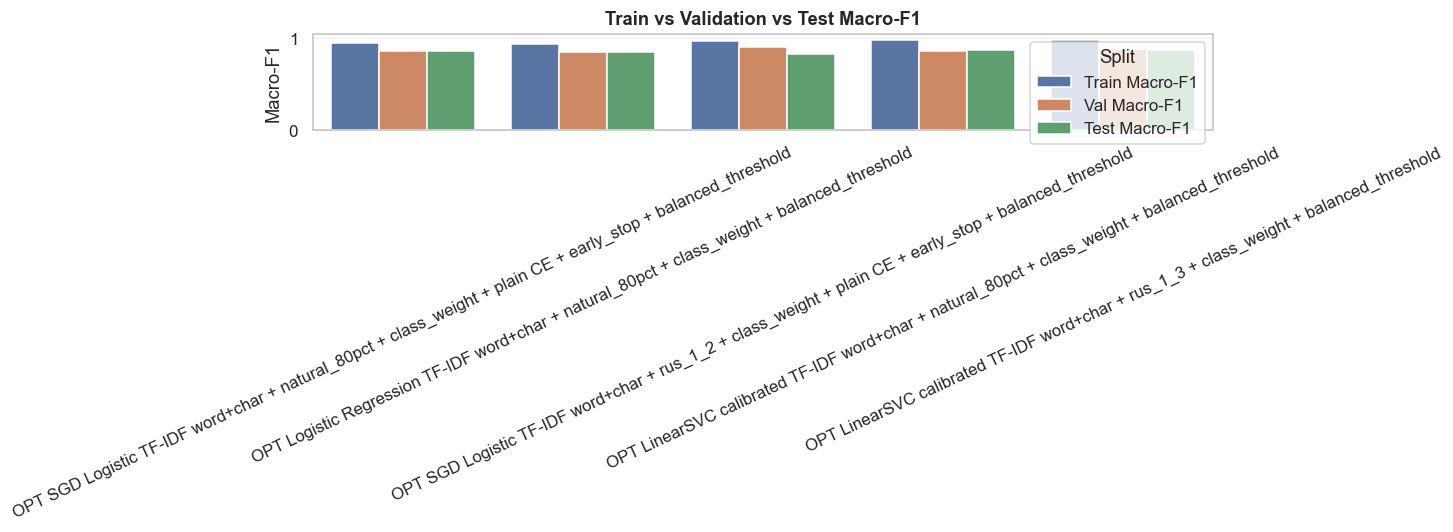

In [69]:
# ============================================================
# CELL 7.1b - Diagnosis Overfit / Underfit Semua Model
# ============================================================
# Membandingkan performa train, validation, dan test.
# Interpretasi umum:
# - Overfit: train jauh lebih tinggi daripada val/test.
# - Underfit: train dan val/test sama-sama rendah.
# - Generalisasi baik: gap kecil dan skor val/test tetap tinggi.

if "ALL_RESULTS" not in globals() or not ALL_RESULTS:
    raise RuntimeError("ALL_RESULTS belum tersedia. Jalankan training/evaluasi model terlebih dahulu.")

OVERFIT_GAP_THRESHOLD = 0.10
UNDERFIT_MACRO_F1_THRESHOLD = 0.70

def _safe_model_prob_train(res, model_name):
    if "y_prob_train" in res:
        return np.asarray(res["y_prob_train"])
    model_obj = res.get("model")
    tokenizer_obj = res.get("tokenizer")
    if tokenizer_obj is None and hasattr(model_obj, "predict_proba"):
        return _two_col_prob_from_estimator(model_obj, df_train["text_ml"].fillna("").astype(str).tolist())
    return None

def _fit_diag_metrics(y_true, y_pred, y_prob=None):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_neg": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall_pos": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

fit_rows = []
for model_name, res in ALL_RESULTS.items():
    y_train_true = np.asarray(res.get("y_true_train", df_train["label"].astype(int).to_numpy())).astype(int)
    y_val_true = df_val["label"].astype(int).to_numpy()
    y_test_true = df_test["label"].astype(int).to_numpy()

    if "y_pred_train" in res:
        y_train_pred = np.asarray(res["y_pred_train"]).astype(int)
    else:
        y_prob_train = _safe_model_prob_train(res, model_name)
        if y_prob_train is None:
            y_train_pred = np.full_like(y_train_true, fill_value=-1)
        else:
            y_train_pred = predict_with_threshold(y_prob_train, float(res.get("threshold", 0.5)))

    train_m = _fit_diag_metrics(y_train_true, y_train_pred) if (y_train_pred >= 0).all() else {"accuracy": np.nan, "macro_f1": np.nan, "recall_neg": np.nan, "recall_pos": np.nan}
    val_m = _fit_diag_metrics(y_val_true, np.asarray(res["y_pred_val"]).astype(int), res.get("y_prob_val"))
    test_m = _fit_diag_metrics(y_test_true, np.asarray(res["y_pred_test"]).astype(int), res.get("y_prob_test"))

    gap_train_val = train_m["macro_f1"] - val_m["macro_f1"] if pd.notna(train_m["macro_f1"]) else np.nan
    gap_train_test = train_m["macro_f1"] - test_m["macro_f1"] if pd.notna(train_m["macro_f1"]) else np.nan

    if pd.isna(train_m["macro_f1"]):
        diagnosis = "Train metric tidak tersedia"
    elif gap_train_val > OVERFIT_GAP_THRESHOLD and gap_train_test > OVERFIT_GAP_THRESHOLD:
        diagnosis = "Indikasi overfit"
    elif train_m["macro_f1"] < UNDERFIT_MACRO_F1_THRESHOLD and val_m["macro_f1"] < UNDERFIT_MACRO_F1_THRESHOLD:
        diagnosis = "Indikasi underfit"
    else:
        diagnosis = "Generalisasi relatif baik"

    fit_rows.append({
        "Model": model_name,
        "Train Macro-F1": train_m["macro_f1"],
        "Val Macro-F1": val_m["macro_f1"],
        "Test Macro-F1": test_m["macro_f1"],
        "Gap Train-Val Macro-F1": gap_train_val,
        "Gap Train-Test Macro-F1": gap_train_test,
        "Train Recall-NEG": train_m["recall_neg"],
        "Val Recall-NEG": val_m["recall_neg"],
        "Test Recall-NEG": test_m["recall_neg"],
        "Diagnosis": diagnosis,
    })

df_fit_diagnosis = pd.DataFrame(fit_rows).sort_values(["Diagnosis", "Test Macro-F1"], ascending=[True, False]).reset_index(drop=True)
df_fit_diagnosis.to_csv(OUTPUT_DIR / "model_fit_overfit_underfit_diagnosis.csv", index=False, encoding="utf-8-sig")

print("=" * 100)
print("DIAGNOSIS OVERFIT / UNDERFIT")
print("=" * 100)
display(df_fit_diagnosis.round(4))

fig, ax = plt.subplots(figsize=(13, 5))
plot_fit = df_fit_diagnosis.melt(
    id_vars=["Model"],
    value_vars=["Train Macro-F1", "Val Macro-F1", "Test Macro-F1"],
    var_name="Split",
    value_name="Macro-F1",
)
sns.barplot(data=plot_fit, x="Model", y="Macro-F1", hue="Split", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title("Train vs Validation vs Test Macro-F1", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Macro-F1")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_fit_overfit_underfit_diagnosis.png", dpi=150, bbox_inches="tight")
plt.show()


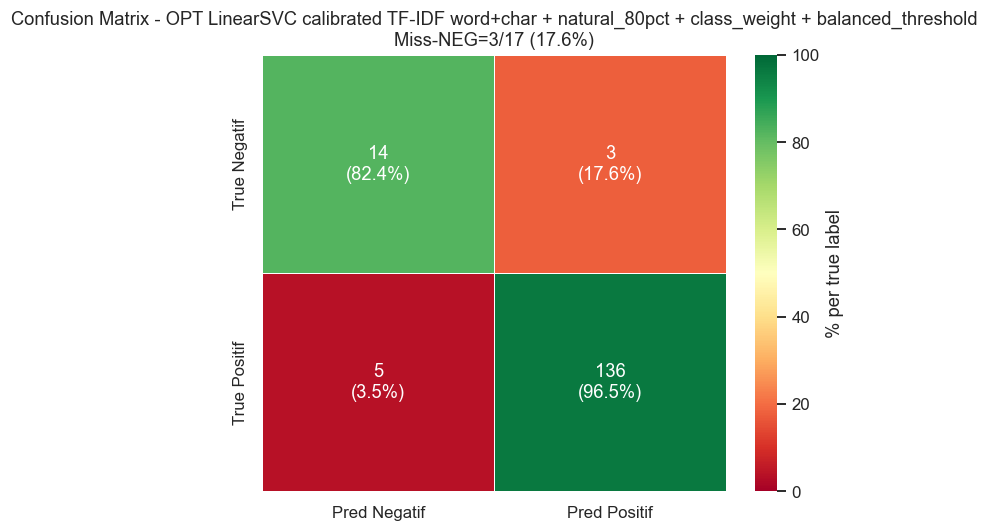

In [70]:
# ============================================================
# CELL 7.2 - Confusion Matrix
# ============================================================
best_name = df_results.iloc[0]["Model"]
best_res = ALL_RESULTS[best_name]
y_true = df_test["label"].to_numpy()
y_pred = best_res["y_pred_test"]

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
cm_pct = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1) * 100
annot = np.array([[f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)" for j in range(2)] for i in range(2)])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_pct,
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    xticklabels=["Pred Negatif", "Pred Positif"],
    yticklabels=["True Negatif", "True Positif"],
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={"label": "% per true label"},
)
miss_neg = int(cm[0, 1])
neg_total = int(cm[0].sum())
plt.title(f"Confusion Matrix - {best_name}\nMiss-NEG={miss_neg}/{neg_total} ({miss_neg / max(neg_total, 1) * 100:.1f}%)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_indobert_opt.png", dpi=150, bbox_inches="tight")
plt.show()


,threshold,score,accuracy,precision,recall_pos,recall_neg,macro_f1,weighted_f1,roc_auc,precision_neg,precision_pos,f1_neg,f1_pos
0,0.60,0.867030,0.949045,0.978417,0.964539,0.8125,0.868067,0.950361,0.979167,0.722222,0.978417,0.764706,0.971429
1,0.61,0.867030,0.949045,0.978417,0.964539,0.8125,0.868067,0.950361,0.979167,0.722222,0.978417,0.764706,0.971429
2,0.62,0.867030,0.949045,0.978417,0.964539,0.8125,0.868067,0.950361,0.979167,0.722222,0.978417,0.764706,0.971429
3,0.63,0.867030,0.949045,0.978417,0.964539,0.8125,0.868067,0.950361,0.979167,0.722222,0.978417,0.764706,0.971429
4,0.64,0.867030,0.949045,0.978417,0.964539,0.8125,0.868067,0.950361,0.979167,0.722222,0.978417,0.764706,0.971429
5,0.66,0.864062,0.942675,0.985294,0.950355,0.8750,0.862133,0.946031,0.979167,0.666667,0.985294,0.756757,0.967509
6,0.68,0.863787,0.936306,0.992481,0.936170,0.9375,0.856752,0.941745,0.979167,0.625000,0.992481,0.750000,0.963504
7,0.69,0.863787,0.936306,0.992481,0.936170,0.9375,0.856752,0.941745,0.979167,0.625000,0.992481,0.750000,0.963504
8,0.70,0.863787,0.936306,0.992481,0.936170,0.9375,0.856752,0.941745,0.979167,0.625000,0.992481,0.750000,0.963504
9,0.71,0.863787,0.936306,0.992481,0.936170,0.9375,0.856752,0.941745,0.979167,0.625000,0.992481,0.750000,0.963504


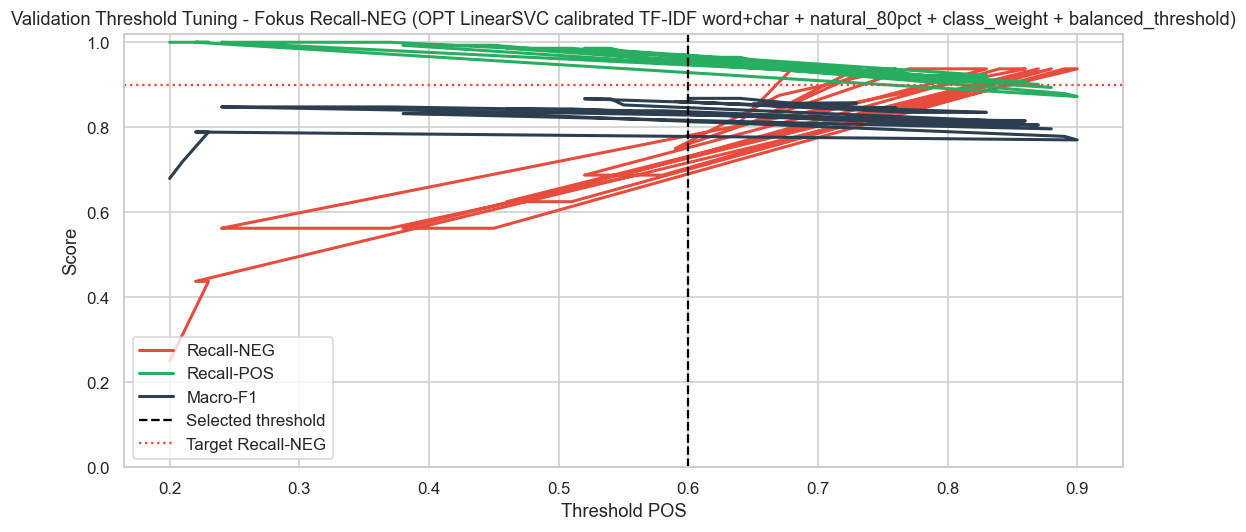

In [71]:
# ============================================================
# CELL 7.3 - Analisis Threshold
# ============================================================
best_name = df_results.iloc[0]["Model"]
df_thr = ALL_RESULTS[best_name]["threshold_table"].copy()
display(df_thr.head(15))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(df_thr["threshold"], df_thr["recall_neg"], label="Recall-NEG", color="#E74C3C", linewidth=2)
ax1.plot(df_thr["threshold"], df_thr["recall_pos"], label="Recall-POS", color="#27AE60", linewidth=2)
ax1.plot(df_thr["threshold"], df_thr["macro_f1"], label="Macro-F1", color="#2C3E50", linewidth=2)
ax1.axvline(ALL_RESULTS[best_name]["threshold"], color="black", linestyle="--", label="Selected threshold")
ax1.axhline(TARGET_VAL_RECALL_NEG, color="#E74C3C", linestyle=":", label="Target Recall-NEG")
ax1.set_xlabel("Threshold POS")
ax1.set_ylabel("Score")
ax1.set_ylim(0, 1.02)
ax1.legend(loc="lower left")
ax1.set_title(f"Validation Threshold Tuning - Fokus Recall-NEG ({best_name})")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "threshold_tuning_recall_neg.png", dpi=150, bbox_inches="tight")
plt.show()


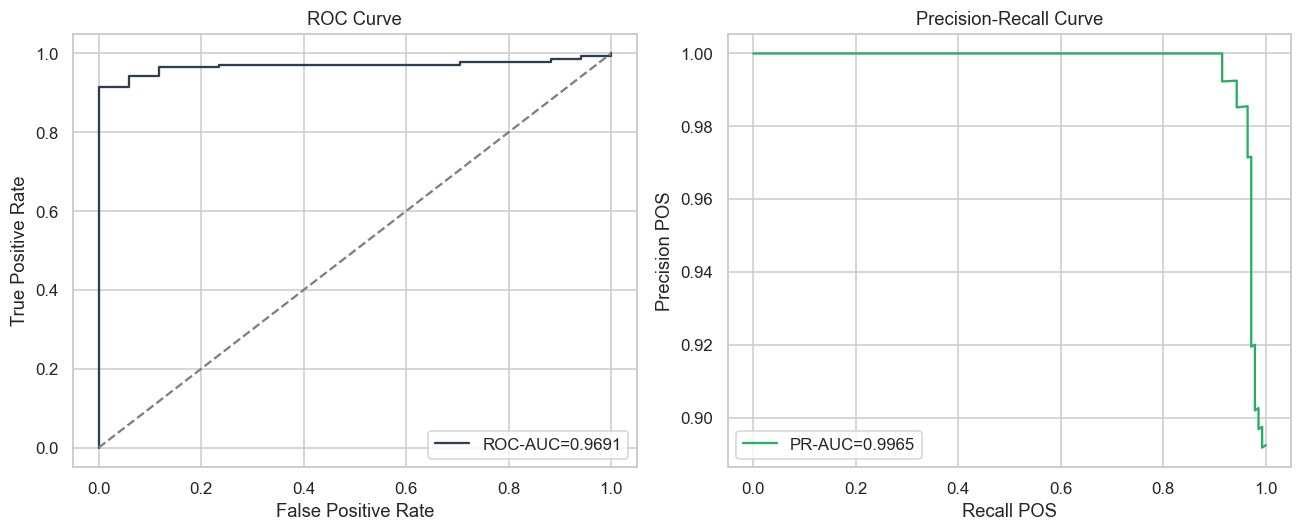

In [72]:
# ============================================================
# CELL 7.4 - ROC & Precision-Recall Curve
# ============================================================
best_name = df_results.iloc[0]["Model"]
best_res = ALL_RESULTS[best_name]
y_true = df_test["label"].to_numpy()
pos_scores = get_pos_scores(best_res["y_prob_test"])

fpr, tpr, _ = roc_curve(y_true, pos_scores)
prec, rec, _ = precision_recall_curve(y_true, pos_scores)
roc_auc_val = roc_auc_score(y_true, pos_scores)
pr_auc_val = auc(rec, prec)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, color="#2C3E50", label=f"ROC-AUC={roc_auc_val:.4f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

axes[1].plot(rec, prec, color="#27AE60", label=f"PR-AUC={pr_auc_val:.4f}")
axes[1].set_xlabel("Recall POS")
axes[1].set_ylabel("Precision POS")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_pr_indobert_opt.png", dpi=150, bbox_inches="tight")
plt.show()


In [73]:
# ============================================================
# CELL 7.5 - Error Analysis: Miss-NEG
# ============================================================
best_name = df_results.iloc[0]["Model"]
best_res = ALL_RESULTS[best_name]

df_err = df_test.copy().reset_index(drop=True)
df_err["y_true"] = df_test["label"].astype(int).to_numpy()
df_err["y_pred"] = best_res["y_pred_test"]
df_err["prob_pos"] = get_pos_scores(best_res["y_prob_test"])
df_err["prob_neg"] = 1 - df_err["prob_pos"]
df_err["correct"] = df_err["y_true"] == df_err["y_pred"]

df_miss_neg = df_err[(df_err["y_true"] == 0) & (df_err["y_pred"] == 1)].copy()
df_false_neg_pos = df_err[(df_err["y_true"] == 1) & (df_err["y_pred"] == 0)].copy()

df_miss_neg.to_csv(OUTPUT_DIR / "miss_negative_samples.csv", index=False, encoding="utf-8-sig")
df_false_neg_pos.to_csv(OUTPUT_DIR / "false_negative_positive_samples.csv", index=False, encoding="utf-8-sig")

print(f"Miss-NEG (Negatif -> Positif): {len(df_miss_neg)}")
print(f"False Negative POS (Positif -> Negatif): {len(df_false_neg_pos)}")
print(f"CSV Miss-NEG: {OUTPUT_DIR / 'miss_negative_samples.csv'}")

display_cols = [c for c in ["review_text", "text_bert", "text_ml", "prob_pos", "prob_neg", "y_true", "y_pred"] if c in df_miss_neg.columns]
display(df_miss_neg.sort_values("prob_pos", ascending=False)[display_cols].head(15))

if len(df_miss_neg) > 0:
    tokens = " ".join(df_miss_neg["text_ml"].fillna("")).split()
    print("\nToken paling sering pada Miss-NEG:")
    print(Counter(tokens).most_common(20))


Miss-NEG (Negatif -> Positif): 3
False Negative POS (Positif -> Negatif): 5
CSV Miss-NEG: output\geo_sentiment_undersampling\miss_negative_samples.csv


,review_text,text_bert,text_ml,prob_pos,prob_neg,y_true,y_pred
151,Enyak,enyak,enyak,0.816443,0.183557,0,1
14,gelo original nya medok parahhhhhhhh,gelo original nya medok parahh,gelo original medok parahh,0.732791,0.267209,0,1
148,"Mie ayamnya lumayan enak, tapi sayang gelasnya bau sabun colek",mie ayam lumayan enak tapi sayang gelasnya bau sabun colek,mie ayam lumayan enak tapi sayang gelas bau sabun colek,0.654291,0.345709,0,1



Token paling sering pada Miss-NEG:
[('gelo', 1), ('original', 1), ('medok', 1), ('parahh', 1), ('mie', 1), ('ayam', 1), ('lumayan', 1), ('enak', 1), ('tapi', 1), ('sayang', 1), ('gelas', 1), ('bau', 1), ('sabun', 1), ('colek', 1), ('enyak', 1)]


EVALUASI LANJUTAN - OPT LinearSVC calibrated TF-IDF word+char + natural_80pct + class_weight + balanced_threshold


,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_neg,recall_neg,f1_neg,precision_pos,recall_pos,...,roc_auc,pr_auc_pos,mcc,cohen_kappa,brier_pos,log_loss,tn,fp_neg_to_pos,fn_pos_to_neg,tp
0,Validation,0.949045,0.888520,0.868067,0.950361,0.722222,0.812500,0.764706,0.978417,0.964539,...,0.979167,0.997609,0.737851,0.736245,0.033353,0.118157,13,3,5,136
1,Test,0.949367,0.894034,0.874603,0.950593,0.736842,0.823529,0.777778,0.978417,0.964539,...,0.969128,0.996525,0.750782,0.749306,0.046565,0.157987,14,3,5,136


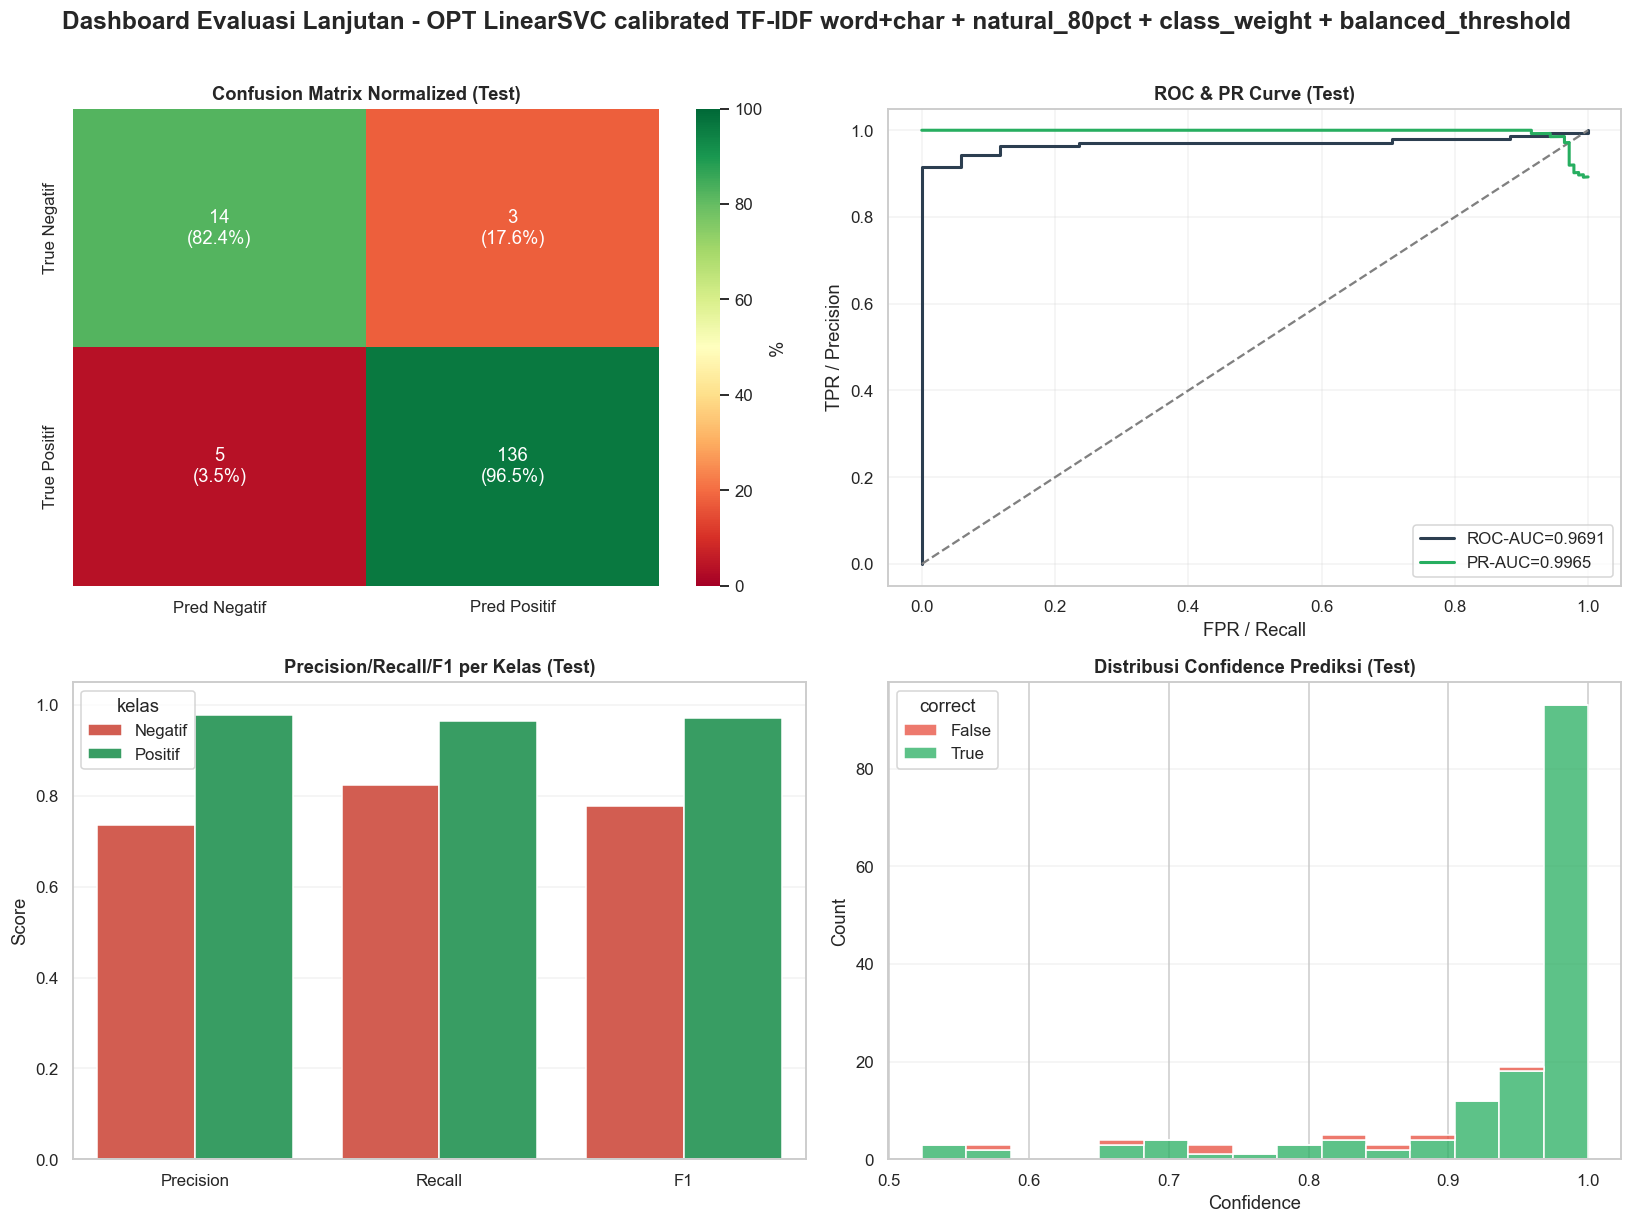


Ringkasan confidence:


,confidence_bin,correct,jumlah
0,"(-0.001, 0.55]",False,0
1,"(-0.001, 0.55]",True,3
2,"(0.55, 0.65]",False,1
3,"(0.55, 0.65]",True,2
4,"(0.65, 0.75]",False,3
5,"(0.65, 0.75]",True,8
6,"(0.75, 0.85]",False,1
7,"(0.75, 0.85]",True,9
8,"(0.85, 0.95]",False,3
9,"(0.85, 0.95]",True,25



High-confidence errors:


,review_text,text_bert,y_true,y_pred,error_type,prob_neg,prob_pos,confidence
111,"Mi ayamnya enak, harganya kurang masuk di akal aku, psen mi ayam 1 es teh manis 1 kena 20k, sayurnya trlalu matng sampe warnanya ngga ij...",mie ayam enak harganya kurang masuk di akal saya psen mie ayam 1 es teh manis 1 kena 20k sayurnya trlalu matng sampe warnanya tidak ijo ...,1,0,False-Neg-POS,0.942448,0.057552,0.942448
136,Sebenar ya bakso ya enak sayang pelaya kurang ramah jadi gak mood makan masak antar pesan gak ada senyum sama sekali mana bersih in meja...,sebenar ya bakso ya enak sayang pelaya kurang ramah jadi tidak mood makan masak antar pesan tidak ada senyum sama sekali mana bersih in ...,1,0,False-Neg-POS,0.902817,0.097183,0.902817
118,Enak...sayang tempatnya kurang jyaman,enak sayang tempatnya kurang jyaman,1,0,False-Neg-POS,0.863184,0.136816,0.863184
151,Enyak,enyak,0,1,Miss-NEG,0.183557,0.816443,0.816443
14,gelo original nya medok parahhhhhhhh,gelo original nya medok parahh,0,1,Miss-NEG,0.267209,0.732791,0.732791
62,"Lumayan enak,agak mahal",lumayan enak agak mahal,1,0,False-Neg-POS,0.714761,0.285239,0.714761
148,"Mie ayamnya lumayan enak, tapi sayang gelasnya bau sabun colek",mie ayam lumayan enak tapi sayang gelasnya bau sabun colek,0,1,Miss-NEG,0.345709,0.654291,0.654291
18,"Kalo anda baca ini, cobain mie ayam + baksonya cuy… pastikan kondisi perut anda kosong ya, karena porsinya kusus buat orang-orang yang p...",kalau anda baca ini cobain mie ayam baksonya cuy pastikan kondisi perut anda kosong ya karena porsinya kusus untuk orang orang yang puny...,1,0,False-Neg-POS,0.422675,0.577325,0.577325


Output evaluasi lanjutan disimpan ke: output\geo_sentiment_undersampling


In [74]:
# ============================================================
# CELL 7.6 - Evaluasi Model Lanjutan: Metrics, Confidence, Error Audit
# ============================================================
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, matthews_corrcoef,
    cohen_kappa_score, brier_score_loss, log_loss
)

if "ALL_RESULTS" not in globals() or not ALL_RESULTS:
    raise RuntimeError("ALL_RESULTS belum tersedia. Jalankan CELL 6.2 model non-pretrained terlebih dahulu.")

model_name_eval = df_results.iloc[0]["Model"] if "df_results" in globals() and len(df_results) else next(iter(ALL_RESULTS))
res_eval = ALL_RESULTS[model_name_eval]

def extended_metrics(y_true, y_pred, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    pos_scores = get_pos_scores(y_prob)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    report = classification_report(
        y_true,
        y_pred,
        target_names=["Negatif", "Positif"],
        output_dict=True,
        zero_division=0,
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "precision_neg": report["Negatif"]["precision"],
        "recall_neg": report["Negatif"]["recall"],
        "f1_neg": report["Negatif"]["f1-score"],
        "precision_pos": report["Positif"]["precision"],
        "recall_pos": report["Positif"]["recall"],
        "f1_pos": report["Positif"]["f1-score"],
        "roc_auc": roc_auc_score(y_true, pos_scores),
        "pr_auc_pos": average_precision_score(y_true, pos_scores),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
        "brier_pos": brier_score_loss(y_true, pos_scores),
        "log_loss": log_loss(y_true, np.asarray(y_prob), labels=[0, 1]),
        "tn": int(tn),
        "fp_neg_to_pos": int(fp),
        "fn_pos_to_neg": int(fn),
        "tp": int(tp),
    }

eval_rows = []
if "y_pred_val" in res_eval and "y_prob_val" in res_eval:
    eval_rows.append({"split": "Validation", **extended_metrics(df_val["label"], res_eval["y_pred_val"], res_eval["y_prob_val"])})
eval_rows.append({"split": "Test", **extended_metrics(df_test["label"], res_eval["y_pred_test"], res_eval["y_prob_test"])})

df_eval_extended = pd.DataFrame(eval_rows)
df_eval_extended.to_csv(OUTPUT_DIR / "model_evaluation_extended_metrics.csv", index=False, encoding="utf-8-sig")

print("=" * 100)
print(f"EVALUASI LANJUTAN - {model_name_eval}")
print("=" * 100)
display(df_eval_extended)

# Audit confidence pada test set.
y_true_test = df_test["label"].astype(int).to_numpy()
y_pred_test = np.asarray(res_eval["y_pred_test"]).astype(int)
y_prob_test = np.asarray(res_eval["y_prob_test"])
pos_scores = get_pos_scores(y_prob_test)
confidence = y_prob_test.max(axis=1)

df_conf_audit = df_test.copy().reset_index(drop=True)
df_conf_audit["y_true"] = y_true_test
df_conf_audit["y_pred"] = y_pred_test
df_conf_audit["prob_neg"] = y_prob_test[:, 0]
df_conf_audit["prob_pos"] = y_prob_test[:, 1]
df_conf_audit["confidence"] = confidence
df_conf_audit["correct"] = df_conf_audit["y_true"] == df_conf_audit["y_pred"]
df_conf_audit["error_type"] = np.select(
    [
        (df_conf_audit["y_true"] == 0) & (df_conf_audit["y_pred"] == 1),
        (df_conf_audit["y_true"] == 1) & (df_conf_audit["y_pred"] == 0),
    ],
    ["Miss-NEG", "False-Neg-POS"],
    default="Correct",
)
df_conf_audit["confidence_bin"] = pd.cut(
    df_conf_audit["confidence"],
    bins=[0.0, 0.55, 0.65, 0.75, 0.85, 0.95, 1.0],
    include_lowest=True,
)

df_conf_summary = (
    df_conf_audit.groupby(["confidence_bin", "correct"], observed=False)
    .size()
    .reset_index(name="jumlah")
)
df_conf_audit.to_csv(OUTPUT_DIR / "prediction_confidence_audit.csv", index=False, encoding="utf-8-sig")
df_conf_summary.to_csv(OUTPUT_DIR / "prediction_confidence_summary.csv", index=False, encoding="utf-8-sig")

# Dashboard visual evaluasi.
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

cm = confusion_matrix(y_true_test, y_pred_test, labels=[0, 1])
cm_pct = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1) * 100
annot = np.array([[f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)" for j in range(2)] for i in range(2)])
sns.heatmap(
    cm_pct,
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    xticklabels=["Pred Negatif", "Pred Positif"],
    yticklabels=["True Negatif", "True Positif"],
    vmin=0,
    vmax=100,
    ax=axes[0, 0],
    cbar_kws={"label": "%"},
)
axes[0, 0].set_title("Confusion Matrix Normalized (Test)", fontweight="bold")

fpr, tpr, _ = roc_curve(y_true_test, pos_scores)
prec, rec, _ = precision_recall_curve(y_true_test, pos_scores)
axes[0, 1].plot(fpr, tpr, label=f"ROC-AUC={roc_auc_score(y_true_test, pos_scores):.4f}", color="#2C3E50", linewidth=2)
axes[0, 1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0, 1].plot(rec, prec, label=f"PR-AUC={average_precision_score(y_true_test, pos_scores):.4f}", color="#27AE60", linewidth=2)
axes[0, 1].set_title("ROC & PR Curve (Test)", fontweight="bold")
axes[0, 1].set_xlabel("FPR / Recall")
axes[0, 1].set_ylabel("TPR / Precision")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.25)

class_metric_df = pd.DataFrame({
    "kelas": ["Negatif", "Negatif", "Negatif", "Positif", "Positif", "Positif"],
    "metric": ["Precision", "Recall", "F1", "Precision", "Recall", "F1"],
    "score": [
        df_eval_extended.loc[df_eval_extended["split"] == "Test", "precision_neg"].iloc[0],
        df_eval_extended.loc[df_eval_extended["split"] == "Test", "recall_neg"].iloc[0],
        df_eval_extended.loc[df_eval_extended["split"] == "Test", "f1_neg"].iloc[0],
        df_eval_extended.loc[df_eval_extended["split"] == "Test", "precision_pos"].iloc[0],
        df_eval_extended.loc[df_eval_extended["split"] == "Test", "recall_pos"].iloc[0],
        df_eval_extended.loc[df_eval_extended["split"] == "Test", "f1_pos"].iloc[0],
    ],
})
sns.barplot(data=class_metric_df, x="metric", y="score", hue="kelas", palette=[LABEL_COLORS[0], LABEL_COLORS[1]], ax=axes[1, 0])
axes[1, 0].set_ylim(0, 1.05)
axes[1, 0].set_title("Precision/Recall/F1 per Kelas (Test)", fontweight="bold")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Score")
axes[1, 0].grid(axis="y", alpha=0.25)

sns.histplot(
    data=df_conf_audit,
    x="confidence",
    hue="correct",
    bins=15,
    multiple="stack",
    palette={True: "#27AE60", False: "#E74C3C"},
    ax=axes[1, 1],
)
axes[1, 1].set_title("Distribusi Confidence Prediksi (Test)", fontweight="bold")
axes[1, 1].set_xlabel("Confidence")
axes[1, 1].grid(axis="y", alpha=0.25)

plt.suptitle(f"Dashboard Evaluasi Lanjutan - {model_name_eval}", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_evaluation_extended_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nRingkasan confidence:")
display(df_conf_summary)

print("\nHigh-confidence errors:")
error_cols = [c for c in ["review_text", "text_bert", "y_true", "y_pred", "error_type", "prob_neg", "prob_pos", "confidence"] if c in df_conf_audit.columns]
display(
    df_conf_audit[df_conf_audit["error_type"] != "Correct"]
    .sort_values("confidence", ascending=False)[error_cols]
    .head(15)
)

print(f"Output evaluasi lanjutan disimpan ke: {OUTPUT_DIR}")

## 5. Inferensi


In [60]:
# ============================================================
# CELL 8.1 - Inferensi Model Utama Non-Pretrained
# ============================================================
def get_main_nonpretrained_model_name():
    if "MAIN_MODEL_NAME" in globals() and MAIN_MODEL_NAME in ALL_RESULTS:
        return MAIN_MODEL_NAME
    if "BEST_MODEL_NAME" in globals() and BEST_MODEL_NAME in ALL_RESULTS:
        return BEST_MODEL_NAME
    if "ALL_RESULTS" in globals() and ALL_RESULTS:
        return next(iter(ALL_RESULTS))
    raise RuntimeError("ALL_RESULTS belum tersedia. Jalankan CELL 6.2 dan CELL 7.1 terlebih dahulu.")

def preprocess_for_inference(text: str):
    ml_text, bert_text = preprocess_full(str(text), apply_stem=True)
    return ml_text, bert_text

def predict_sentiment_main_model(text: str, model_name: str = None):
    if model_name is None:
        model_name = get_main_nonpretrained_model_name()
    res = ALL_RESULTS[model_name]
    model_obj = res["model"]
    threshold = float(res["threshold"])
    ml_text, bert_text = preprocess_for_inference(text)
    probs = _two_col_prob_from_estimator(model_obj, [ml_text])[0]
    pred = int(probs[1] >= threshold)
    return {
        "text": text,
        "text_ml": ml_text,
        "text_bert": bert_text,
        "model": model_name,
        "threshold": threshold,
        "label_id": pred,
        "label": LABEL_NAMES[pred],
        "prob_neg": float(probs[0]),
        "prob_pos": float(probs[1]),
        "confidence": float(np.max(probs)),
    }

# Alias agar cell lama/user code yang memanggil nama ini tetap jalan,
# tetapi isinya sekarang memakai model utama non-pretrained.
predict_sentiment_indobert = predict_sentiment_main_model

DEMO_TEXTS = [
    "Mie ayamnya enak banget, kuahnya gurih dan pelayanan ramah.",
    "Kecewa banget, kuah hambar, porsi sedikit, harga mahal.",
    "Tidak enak sama sekali, mienya lembek dan terlalu asin.",
    "Lumayan enak tapi nunggunya agak lama.",
]

for txt in DEMO_TEXTS:
    print(predict_sentiment_main_model(txt))


{'text': 'Mie ayamnya enak banget, kuahnya gurih dan pelayanan ramah.', 'text_ml': 'mie ayam enak banget kuah gurih layan ramah', 'text_bert': 'mie ayam enak banget kuah gurih dan pelayanan ramah', 'model': 'OPT Logistic Regression TF-IDF word+char + random undersampling + plain CE + threshold', 'threshold': 0.54, 'label_id': 1, 'label': 'Positif', 'prob_neg': 0.036009986759628076, 'prob_pos': 0.9639900132403719, 'confidence': 0.9639900132403719}
{'text': 'Kecewa banget, kuah hambar, porsi sedikit, harga mahal.', 'text_ml': 'kecewa banget kuah hambar porsi sedikit harga mahal', 'text_bert': 'kecewa banget kuah hambar porsi sedikit harga mahal', 'model': 'OPT Logistic Regression TF-IDF word+char + random undersampling + plain CE + threshold', 'threshold': 0.54, 'label_id': 0, 'label': 'Negatif', 'prob_neg': 0.8716818561658721, 'prob_pos': 0.12831814383412785, 'confidence': 0.8716818561658721}
{'text': 'Tidak enak sama sekali, mienya lembek dan terlalu asin.', 'text_ml': 'tidak enak seka

In [80]:
# ============================================================
# CELL 8.2 - Test Ulasan Baru dari Input User
# ============================================================
# Input berisi nama, rating, dan isi ulasan.
# Model HANYA memakai isi_ulasan untuk prediksi; nama/rating hanya metadata.

RUN_INTERACTIVE_INPUT = True  # Set False jika tidak ingin cell meminta input manual.


def test_ulasan_baru(nama=None, rating=None, isi_ulasan=None, interactive=True):
    if 'ALL_RESULTS' not in globals() or not ALL_RESULTS:
        raise RuntimeError('Model belum tersedia. Jalankan CELL 6.2 model non-pretrained sampai ALL_RESULTS terbentuk.')
    if 'predict_sentiment_main_model' not in globals():
        raise RuntimeError('Fungsi predict_sentiment_main_model belum tersedia. Jalankan CELL 8.1 terlebih dahulu.')

    if interactive:
        if nama is None:
            nama = input('Nama pengguna/resto: ').strip()
        if rating is None:
            rating = input('Rating metadata, contoh 1-5: ').strip()
        if isi_ulasan is None:
            isi_ulasan = input('Isi ulasan untuk diprediksi model: ').strip()

    nama = '' if nama is None else str(nama).strip()
    rating = '' if rating is None else str(rating).strip()
    isi_ulasan = '' if isi_ulasan is None else str(isi_ulasan).strip()

    if not isi_ulasan:
        raise ValueError('Isi ulasan tidak boleh kosong.')

    # Penting: prediksi hanya memakai isi_ulasan, bukan nama atau rating.
    pred = predict_sentiment_main_model(isi_ulasan)

    result = {
        'nama': nama,
        'rating_metadata': rating,
        'ulasan': isi_ulasan,
        'model': pred['model'],
        'label_prediksi': pred['label'],
        'label_id': pred['label_id'],
        'prob_negatif': round(pred['prob_neg'], 4),
        'prob_positif': round(pred['prob_pos'], 4),
        'confidence': round(pred.get('confidence', max(pred['prob_neg'], pred['prob_pos'])), 4),
        'threshold_pos': round(pred['threshold'], 4),
        'catatan': 'Rating hanya metadata; prediksi hanya berdasarkan isi ulasan.',
    }

    print('=' * 78)
    print('HASIL TEST ULASAN BARU - MODEL UTAMA NON-PRETRAINED')
    print('=' * 78)
    print(f"Nama          : {result['nama'] or '-'}")
    print(f"Rating        : {result['rating_metadata'] or '-'} (metadata, tidak dipakai model)")
    print(f"Ulasan        : {result['ulasan']}")
    print(f"Model         : {result['model']}")
    print('-' * 78)
    print(f"Prediksi      : {result['label_prediksi']} (label={result['label_id']})")
    print(f"Prob Negatif  : {result['prob_negatif']:.4f}")
    print(f"Prob Positif  : {result['prob_positif']:.4f}")
    print(f"Confidence    : {result['confidence']:.4f}")
    print(f"Threshold POS : {result['threshold_pos']:.4f}")
    print('-' * 78)
    print(result['catatan'])
    print('=' * 78)

    return result


if RUN_INTERACTIVE_INPUT:
    hasil_manual = test_ulasan_baru(interactive=True)
else:
    contoh_hasil = test_ulasan_baru(
        nama='Contoh User',
        rating=5,
        isi_ulasan='Mie ayamnya enak, kuahnya gurih, pelayanan juga cepat.',
        interactive=False,
    )


Nama pengguna/resto:  axan
Rating metadata, contoh 1-5:  2
Isi ulasan untuk diprediksi model:  Mie ayamnya biasa saja, tidak terlalu spesial, tapi masih cukup oke untuk makan siang.


HASIL TEST ULASAN BARU - MODEL UTAMA NON-PRETRAINED
Nama          : axan
Rating        : 2 (metadata, tidak dipakai model)
Ulasan        : Mie ayamnya biasa saja, tidak terlalu spesial, tapi masih cukup oke untuk makan siang.
Model         : OPT LinearSVC calibrated TF-IDF word+char + natural_80pct + class_weight + balanced_threshold
------------------------------------------------------------------------------
Prediksi      : Negatif (label=0)
Prob Negatif  : 0.5054
Prob Positif  : 0.4946
Confidence    : 0.5054
Threshold POS : 0.6000
------------------------------------------------------------------------------
Rating hanya metadata; prediksi hanya berdasarkan isi ulasan.


  0%|          | 0/354 [00:00<?, ?it/s]

PREVIEW PERSEBARAN MINGGUAN DATA TESTING APRIL-JUNE 2026
Model utama non-pretrained: OPT LinearSVC calibrated TF-IDF word+char + natural_80pct + class_weight + balanced_threshold


,year,month,week_of_month,rentang_tanggal,predict_sentiment,jumlah_ulasan
0,2026,4,1,01-07 Apr 2026,Negatif,9
1,2026,4,1,01-07 Apr 2026,Positif,55
2,2026,4,2,08-14 Apr 2026,Negatif,5
3,2026,4,2,08-14 Apr 2026,Positif,60
4,2026,4,3,15-21 Apr 2026,Negatif,4
5,2026,4,3,15-21 Apr 2026,Positif,42
6,2026,4,4,22-30 Apr 2026,Negatif,4
7,2026,4,4,22-30 Apr 2026,Positif,34
8,2026,5,1,01-07 Mei 2026,Negatif,1
9,2026,5,1,01-07 Mei 2026,Positif,10


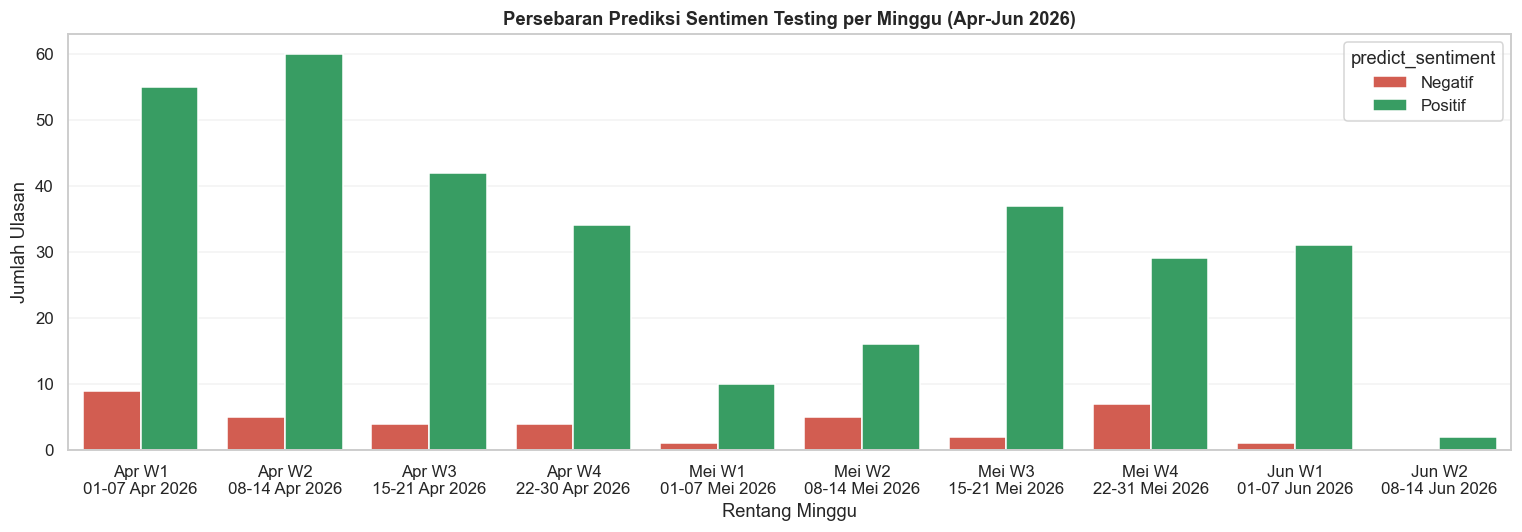


Preview tabel output model:


,rentang_tanggal,latitude,longitude,ulasan,predict sentiment,confidence model
0,22-31 Mei 2026,-7.433572,109.240204,enak,Positif,0.9998
1,15-21 Mei 2026,-7.433572,109.240204,"Pelayanan bagusss, karyawan nya asik dan senyum. Bakso sariman reccomend bgt buat di cobaa",Positif,0.9070
2,15-21 Mei 2026,-7.433572,109.240204,Rojali ganteng 🥰,Positif,0.6999
3,15-21 Mei 2026,-7.433572,109.240204,"pelayanannya baguss, baksonyaa recomended di purwokerto",Positif,0.9791
4,15-21 Mei 2026,-7.433572,109.240204,"pelayanan nya yang di lakukan bagus, bakso nya rekomen di pwt bgt kalian harus cobaa.\nkaryawan full senyummm asik",Positif,0.9446
5,15-21 Mei 2026,-7.433572,109.240204,Tempatnya nyaman karyawannya juga ramah” yang bikin ak selalu kesini bakso urat jumbonya best bgt kalian harus cobain deh,Positif,0.9565
6,08-14 Mei 2026,-7.433572,109.240204,"Salah satu cabang sariman yang berada di tengah kota Purwokerto.\nPengalaman makan di cabang lain, cabang ini termasuk yang rasanya kura...",Negatif,0.6230
7,08-14 Mei 2026,-7.433572,109.240204,"rasa nya pas gurih, enak bangetttt bestt pokoknya, untuk pelayanan nya mungkin bisa lebih ditingkatkan lagi",Positif,0.9938
8,01-07 Mei 2026,-7.433572,109.240204,kesini 3x jam makan siang tapi 3x juga menu yang di pesan ngga ada semua. kalo ngga ada mending ga usah ditulis dimenu. mau ganti yg la...,Negatif,0.7882
9,22-30 Apr 2026,-7.433572,109.240204,"pelayanan ramah, banyak promo menarik yang menguntungkan\nWAJIB DI COBA!",Positif,0.8825


CSV preview disimpan: output\geo_sentiment_undersampling\testing_prediction_preview_apr_jun_2026.csv


In [81]:
# ============================================================
# CELL 8.3 - Preview Testing Apr-Jun 2026: Persebaran Mingguan dan Confidence
# ============================================================
# Output ini khusus memakai model utama NON-PRETRAINED terpilih dari CELL 6.2.

MONTH_ID_NAME = {4: "April", 5: "Mei", 6: "Juni"}
MONTH_ID_SHORT = {4: "Apr", 5: "Mei", 6: "Jun"}

def _load_testing_raw_for_prediction():
    if "df_external_raw" in globals() and len(df_external_raw):
        return df_external_raw.copy()
    candidates = [
        RAW_DIR / "test_data_ulasan_mie_ayam.csv",
        BASE_DIR / "test_data_ulasan_mie_ayam.csv",
        Path("data/raw/april_june_2026/test_data_ulasan_mie_ayam.csv"),
    ]
    for p in candidates:
        if p.exists():
            return pd.read_csv(p, encoding="utf-8-sig", low_memory=False)
    raise FileNotFoundError("test_data_ulasan_mie_ayam.csv tidak ditemukan untuk preview testing.")

def _week_of_month_4_bucket(dt):
    if pd.isna(dt):
        return np.nan
    return int(min(((int(dt.day) - 1) // 7) + 1, 4))

def _week_range_label(year, month, week):
    start_day = 1 + (int(week) - 1) * 7
    last_day = pd.Period(f"{int(year)}-{int(month):02d}").days_in_month
    end_day = last_day if int(week) == 4 else min(start_day + 6, last_day)
    return f"{start_day:02d}-{end_day:02d} {MONTH_ID_SHORT.get(int(month), str(month))} {int(year)}"

def _predict_testing_dataframe_with_main_model(raw_df):
    if "ALL_RESULTS" not in globals() or not ALL_RESULTS:
        raise RuntimeError("ALL_RESULTS belum tersedia. Jalankan CELL 6.2 terlebih dahulu.")
    model_name = get_main_nonpretrained_model_name()
    res = ALL_RESULTS[model_name]
    model_obj = res["model"]
    threshold = float(res["threshold"])

    pred_df = raw_df.copy().reset_index(drop=True)
    pred_df = pred_df.dropna(subset=["review_text", "lat", "lon"]).copy()
    pred_df = pred_df[pred_df["review_text"].astype(str).str.strip().ne("")].copy().reset_index(drop=True)
    proc = pred_df["review_text"].progress_apply(lambda t: preprocess_full(str(t), apply_stem=True))
    pred_df["text_ml"] = proc.apply(lambda x: x[0])
    pred_df["text_bert"] = proc.apply(lambda x: x[1])

    probs = _two_col_prob_from_estimator(model_obj, pred_df["text_ml"].fillna("").astype(str).tolist())
    pred_df["prob_neg"] = probs[:, 0]
    pred_df["prob_pos"] = probs[:, 1]
    pred_df["sentiment_pred"] = (pred_df["prob_pos"] >= threshold).astype(int)
    pred_df["predict_sentiment"] = pred_df["sentiment_pred"].map(LABEL_NAMES)
    pred_df["confidence_model"] = probs.max(axis=1)
    pred_df["threshold_pos"] = threshold
    pred_df["model_prediksi"] = model_name
    pred_df["model_family"] = "non_pretrained"
    pred_df["review_date_dt"] = pd.to_datetime(pred_df["review_date"], errors="coerce", utc=True).dt.tz_convert(None)
    pred_df = pred_df.dropna(subset=["review_date_dt"]).copy()
    pred_df["year"] = pred_df["review_date_dt"].dt.year.astype(int)
    pred_df["month"] = pred_df["review_date_dt"].dt.month.astype(int)
    pred_df["week_of_month"] = pred_df["review_date_dt"].apply(_week_of_month_4_bucket).astype(int)
    pred_df["rentang_tanggal"] = pred_df.apply(lambda r: _week_range_label(r["year"], r["month"], r["week_of_month"]), axis=1)
    return pred_df

raw_testing_preview = _load_testing_raw_for_prediction()
df_testing_predictions_apr_jun_2026 = _predict_testing_dataframe_with_main_model(raw_testing_preview)

weekly_distribution = (
    df_testing_predictions_apr_jun_2026.groupby(["year", "month", "week_of_month", "rentang_tanggal", "predict_sentiment"], observed=False)
    .size()
    .reset_index(name="jumlah_ulasan")
    .sort_values(["year", "month", "week_of_month", "predict_sentiment"])
)
weekly_distribution.to_csv(OUTPUT_DIR / "testing_weekly_distribution_apr_jun_2026.csv", index=False, encoding="utf-8-sig")

preview_cols = ["rentang_tanggal", "lat", "lon", "review_text", "predict_sentiment", "confidence_model"]
df_testing_preview_table = df_testing_predictions_apr_jun_2026[preview_cols].copy()
df_testing_preview_table = df_testing_preview_table.rename(columns={
    "lat": "latitude",
    "lon": "longitude",
    "review_text": "ulasan",
    "predict_sentiment": "predict sentiment",
    "confidence_model": "confidence model",
})
df_testing_preview_table["confidence model"] = df_testing_preview_table["confidence model"].round(4)
df_testing_preview_table.to_csv(OUTPUT_DIR / "testing_prediction_preview_apr_jun_2026.csv", index=False, encoding="utf-8-sig")
df_testing_predictions_apr_jun_2026.to_csv(OUTPUT_DIR / "testing_predictions_apr_jun_2026_full.csv", index=False, encoding="utf-8-sig")

print("=" * 90)
print("PREVIEW PERSEBARAN MINGGUAN DATA TESTING APRIL-JUNE 2026")
print(f"Model utama non-pretrained: {get_main_nonpretrained_model_name()}")
print("=" * 90)
display(weekly_distribution)

fig, ax = plt.subplots(figsize=(14, 5))
plot_week = weekly_distribution.copy()
plot_week["minggu_label"] = plot_week["month"].map(MONTH_ID_SHORT) + " W" + plot_week["week_of_month"].astype(str) + "\n" + plot_week["rentang_tanggal"]
sns.barplot(
    data=plot_week,
    x="minggu_label",
    y="jumlah_ulasan",
    hue="predict_sentiment",
    hue_order=["Negatif", "Positif"],
    palette=[LABEL_COLORS[0], LABEL_COLORS[1]],
    ax=ax,
)
ax.set_title("Persebaran Prediksi Sentimen Testing per Minggu (Apr-Jun 2026)", fontweight="bold")
ax.set_xlabel("Rentang Minggu")
ax.set_ylabel("Jumlah Ulasan")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "testing_weekly_distribution_apr_jun_2026.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nPreview tabel output model:")
display(df_testing_preview_table.head(30))
print(f"CSV preview disimpan: {OUTPUT_DIR / 'testing_prediction_preview_apr_jun_2026.csv'}")


## 6. Spatial Analysis Enhanced

Cell ini mematangkan visual geo-spatial dengan reliability review, proporsi sentimen, marker dinamis, layer sentimen, heatmap, top lokasi, dan agregasi kecamatan jika file GeoJSON tersedia.

In [88]:
# ============================================================
# CELL 8.4 - Export Excel Preview Testing Apr-Jun 2026
# ============================================================
# Membuat versi Excel dari preview prediksi testing agar kolom lebih mudah dibaca.

from pathlib import Path

try:
    import openpyxl  # noqa: F401
except ImportError as e:
    raise ImportError("Dependency Excel belum tersedia. Install dengan: pip install openpyxl") from e

if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = Path("output/geo_sentiment_undersampling")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if "df_testing_predictions_apr_jun_2026" in globals() and len(df_testing_predictions_apr_jun_2026):
    df_testing_excel_source = df_testing_predictions_apr_jun_2026.copy()
else:
    full_pred_path = OUTPUT_DIR / "testing_predictions_apr_jun_2026_full.csv"
    preview_csv_path = OUTPUT_DIR / "testing_prediction_preview_apr_jun_2026.csv"
    if full_pred_path.exists():
        df_testing_excel_source = pd.read_csv(full_pred_path, encoding="utf-8-sig", low_memory=False)
    elif preview_csv_path.exists():
        df_testing_excel_source = pd.read_csv(preview_csv_path, encoding="utf-8-sig", low_memory=False)
    else:
        raise FileNotFoundError("Preview testing belum tersedia. Jalankan CELL 8.3 terlebih dahulu.")

def _pick_existing_col(frame, candidates, default=""):
    for col in candidates:
        if col in frame.columns:
            return frame[col]
    return pd.Series([default] * len(frame), index=frame.index)

df_testing_preview_excel = pd.DataFrame({
    "no": range(1, len(df_testing_excel_source) + 1),
    "latitude": pd.to_numeric(_pick_existing_col(df_testing_excel_source, ["lat", "latitude"]), errors="coerce"),
    "longitude": pd.to_numeric(_pick_existing_col(df_testing_excel_source, ["lon", "longitude"]), errors="coerce"),
    "tanggal review": _pick_existing_col(df_testing_excel_source, ["review_date", "review_date_dt", "tanggal review", "tanggal_review"]),
    "text review": _pick_existing_col(df_testing_excel_source, ["review_text", "ulasan", "text review"]),
    "rating": _pick_existing_col(df_testing_excel_source, ["review_rating", "rating", "rating_review"]),
    "predicted sentiment": _pick_existing_col(df_testing_excel_source, ["predict_sentiment", "predict sentiment", "predicted sentiment"]),
    "confidence model": pd.to_numeric(_pick_existing_col(df_testing_excel_source, ["confidence_model", "confidence model"]), errors="coerce").round(4),
})

df_testing_preview_excel["tanggal review"] = pd.to_datetime(df_testing_preview_excel["tanggal review"], errors="coerce").dt.strftime("%Y-%m-%d %H:%M:%S").fillna(
    df_testing_preview_excel["tanggal review"].astype(str)
)

testing_excel_path = OUTPUT_DIR / "testing_prediction_preview_apr_jun_2026.xlsx"
df_testing_preview_excel.to_excel(testing_excel_path, index=False, sheet_name="preview_testing")

print(f"Excel preview testing disimpan: {testing_excel_path}")
print(f"Total rows: {len(df_testing_preview_excel):,}")
display(df_testing_preview_excel.head(30))


Excel preview testing disimpan: output\geo_sentiment_undersampling\testing_prediction_preview_apr_jun_2026.xlsx
Total rows: 354


,no,latitude,longitude,tanggal review,text review,rating,predicted sentiment,confidence model
0,1,-7.433572,109.240204,2026-05-27 06:48:50,enak,5,Positif,0.9998
1,2,-7.433572,109.240204,2026-05-19 11:44:28,"Pelayanan bagusss, karyawan nya asik dan senyum. Bakso sariman reccomend bgt buat di cobaa",5,Positif,0.9070
2,3,-7.433572,109.240204,2026-05-19 11:44:15,Rojali ganteng 🥰,5,Positif,0.6999
3,4,-7.433572,109.240204,2026-05-19 11:42:36,"pelayanannya baguss, baksonyaa recomended di purwokerto",5,Positif,0.9791
4,5,-7.433572,109.240204,2026-05-19 11:41:33,"pelayanan nya yang di lakukan bagus, bakso nya rekomen di pwt bgt kalian harus cobaa.\nkaryawan full senyummm asik",5,Positif,0.9446
5,6,-7.433572,109.240204,2026-05-19 11:40:27,Tempatnya nyaman karyawannya juga ramah” yang bikin ak selalu kesini bakso urat jumbonya best bgt kalian harus cobain deh,5,Positif,0.9565
6,7,-7.433572,109.240204,2026-05-13 12:40:30,"Salah satu cabang sariman yang berada di tengah kota Purwokerto.\nPengalaman makan di cabang lain, cabang ini termasuk yang rasanya kura...",3,Negatif,0.6230
7,8,-7.433572,109.240204,2026-05-08 12:54:59,"rasa nya pas gurih, enak bangetttt bestt pokoknya, untuk pelayanan nya mungkin bisa lebih ditingkatkan lagi",5,Positif,0.9938
8,9,-7.433572,109.240204,2026-05-06 01:40:43,kesini 3x jam makan siang tapi 3x juga menu yang di pesan ngga ada semua. kalo ngga ada mending ga usah ditulis dimenu. mau ganti yg la...,2,Negatif,0.7882
9,10,-7.433572,109.240204,2026-04-28 12:49:26,"pelayanan ramah, banyak promo menarik yang menguntungkan\nWAJIB DI COBA!",5,Positif,0.8825


In [86]:
# ============================================================
# CELL 9.1 - Spatial Overview Map: Heatmap + Marker Deskriptif + Navigasi Bulan/Minggu
# ============================================================
# Navigasi custom berbasis Leaflet JS:
# - Tahun 2020 - Maret 2026 memakai dataset train/EDA.
# - April, Mei, Juni 2026 memakai dataset testing + keputusan model utama non-pretrained dari CELL 8.3.
# - Tombol bulan di kanan atas; tombol week 1-4 muncul hanya untuk April-Juni.

from pathlib import Path
import html
import json
import math
import numpy as np
import pandas as pd

try:
    import folium
    from folium.plugins import HeatMap
except ImportError as e:
    raise ImportError("Folium belum tersedia. Install dengan: pip install folium") from e

if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = Path("output/geo_sentiment_undersampling")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MONTH_ID_NAME = {4: "April", 5: "Mei", 6: "Juni"}
MONTH_ID_SHORT = {4: "Apr", 5: "Mei", 6: "Jun"}
COLOR_POS = "#5FAF1B"
COLOR_NEG = "#E74C3C"
COLOR_NONE = "#8A8F98"

ASPECT_RULES_OVERVIEW = {
    "rasa enak": ["enak", "lezat", "gurih", "nikmat", "mantap", "sedap", "wenak", "recommended", "rekomendasi"],
    "rasa kurang cocok": ["hambar", "tawar", "asin", "basi", "kurang enak", "tidak enak", "kecewa"],
    "tempat nyaman & bersih": ["nyaman", "bersih", "parkir", "luas", "rapi"],
    "tempat kurang nyaman": ["kotor", "sempit", "panas", "bau", "kurang nyaman"],
    "pelayanan ramah & cepat": ["ramah", "cepat", "sigap", "baik", "sopan"],
    "pelayanan lama/kurang": ["lama", "nunggu", "antri", "tidak ramah", "jutek", "buruk"],
    "harga terjangkau": ["murah", "terjangkau", "worth", "sepadan", "pas di kantong"],
    "harga mahal": ["mahal", "kemahalan", "overprice"],
    "porsi cukup/banyak": ["porsi", "banyak", "kenyang", "besar"],
    "porsi kurang": ["sedikit", "kecil", "kurang banyak"],
}


def _overview_hist_source():
    if "df_train_source_labeled" in globals() and len(df_train_source_labeled):
        hist = df_train_source_labeled.copy()
    else:
        hist_path = OUTPUT_DIR / "train_pool_labeled_external_split.csv"
        if not hist_path.exists():
            raise RuntimeError("Data train_pool_labeled_external_split.csv belum ada. Jalankan CELL 4.1 terlebih dahulu.")
        hist = pd.read_csv(hist_path, encoding="utf-8-sig", low_memory=False)
    hist["review_date_dt"] = pd.to_datetime(hist.get("review_date_dt", hist.get("review_date")), errors="coerce")
    hist["lat"] = pd.to_numeric(hist["lat"], errors="coerce")
    hist["lon"] = pd.to_numeric(hist["lon"], errors="coerce")
    hist = hist.dropna(subset=["lat", "lon", "label", "review_date_dt"]).copy()
    hist = hist[hist["lat"].between(-8.0, -7.0) & hist["lon"].between(108.5, 110.0)].copy()
    hist = hist[hist["review_date_dt"] < pd.Timestamp("2026-04-01")].copy()
    return hist


def _load_testing_predictions_overview():
    if "df_testing_predictions_apr_jun_2026" in globals() and len(df_testing_predictions_apr_jun_2026):
        out = df_testing_predictions_apr_jun_2026.copy()
    else:
        pred_path = OUTPUT_DIR / "testing_predictions_apr_jun_2026_full.csv"
        if not pred_path.exists():
            raise RuntimeError("Prediksi testing Apr-Jun 2026 belum tersedia. Jalankan CELL 8.3 terlebih dahulu.")
        out = pd.read_csv(pred_path, encoding="utf-8-sig", low_memory=False)
    out["review_date_dt"] = pd.to_datetime(out.get("review_date_dt", out.get("review_date")), errors="coerce")
    out["lat"] = pd.to_numeric(out["lat"], errors="coerce")
    out["lon"] = pd.to_numeric(out["lon"], errors="coerce")
    out["confidence_model"] = pd.to_numeric(out.get("confidence_model"), errors="coerce")
    out = out.dropna(subset=["review_date_dt", "lat", "lon"]).copy()
    out = out[out["lat"].between(-8.0, -7.0) & out["lon"].between(108.5, 110.0)].copy()
    out = out[out["review_date_dt"].dt.year.eq(2026) & out["review_date_dt"].dt.month.between(4, 6)].copy()
    out["month"] = out["review_date_dt"].dt.month.astype(int)
    out["week_of_month"] = out["review_date_dt"].apply(lambda d: int(min(((int(d.day) - 1) // 7) + 1, 4))).astype(int)
    if "sentiment_pred" not in out.columns and "predict_sentiment" in out.columns:
        out["sentiment_pred"] = out["predict_sentiment"].map({"Negatif": 0, "Positif": 1}).fillna(1).astype(int)
    if "predict_sentiment" not in out.columns:
        out["predict_sentiment"] = out["sentiment_pred"].map(LABEL_NAMES)
    return out


def _week_range_label(year, month, week):
    start_day = 1 + (int(week) - 1) * 7
    last_day = pd.Period(f"{int(year)}-{int(month):02d}").days_in_month
    end_day = last_day if int(week) == 4 else min(start_day + 6, last_day)
    return f"{start_day:02d}-{end_day:02d} {MONTH_ID_SHORT[int(month)]} {int(year)}"


def _overview_aspect_summary(texts, top_k=3):
    joined = " ".join(str(t).lower() for t in texts if str(t).strip())
    joined = " ".join(joined.split())
    hits = []
    for aspect, keywords in ASPECT_RULES_OVERVIEW.items():
        score = sum(joined.count(kw) for kw in keywords)
        if score:
            hits.append((aspect, score))
    hits = sorted(hits, key=lambda x: (-x[1], x[0]))
    return ", ".join(a for a, _ in hits[:top_k]) if hits else "tema ulasan belum dominan"


def _dominant(n_pos, n_neg):
    if n_pos == 0 and n_neg == 0:
        return "Tidak ada ulasan", COLOR_NONE
    if n_pos >= n_neg:
        return "Positif", COLOR_POS
    return "Negatif", COLOR_NEG


def _radius(n):
    return max(7, min(22, 7 + math.log1p(max(n, 1)) * 3.0))


def _js_text(value):
    return "" if value is None else str(value)


df_hist = _overview_hist_source()
df_test_pred = _load_testing_predictions_overview()
center_source = df_test_pred if len(df_test_pred) else df_hist
center = [float(center_source["lat"].mean()), float(center_source["lon"].mean())]
overview_map = folium.Map(location=center, zoom_start=13, tiles="OpenStreetMap", control_scale=True)

# Heatmap historis hanya untuk mode Tahun 2020 - Maret 2026.
heat_points = df_hist[["lat", "lon"]].dropna().values.tolist()
heat_layer = None
if heat_points:
    heat_layer = HeatMap(heat_points, name="Heatmap Tahun 2020 - Maret 2026", radius=23, blur=18, min_opacity=0.22)
    heat_layer.add_to(overview_map)

history_markers = []
history_summary_rows = []
group_cols = ["place_id"] if "place_id" in df_hist.columns and df_hist["place_id"].fillna("").astype(str).str.strip().ne("").any() else ["place_name", "lat", "lon"]
for _, grp in df_hist.groupby(group_cols, dropna=False):
    n_reviews = int(len(grp))
    n_neg = int((grp["label"].astype(int) == 0).sum())
    n_pos = int((grp["label"].astype(int) == 1).sum())
    dom_label, color = _dominant(n_pos, n_neg)
    pos_pct = n_pos / max(n_reviews, 1) * 100
    neg_pct = n_neg / max(n_reviews, 1) * 100
    lat = float(grp["lat"].mean())
    lon = float(grp["lon"].mean())
    place_name = str(grp["place_name"].iloc[0]) if "place_name" in grp.columns else "Lokasi"
    aspect_summary = _overview_aspect_summary(grp.get("review_text", pd.Series(dtype=str)).tolist())
    popup = f"""
    <div style="font-size:13px;line-height:1.35;">
      <b>{html.escape(place_name)}</b><br>
      mayoritas sentimen : <b style="color:{color};">{dom_label}</b><br>
      persentase sentimen : positif {pos_pct:.0f}% | negatif {neg_pct:.0f}%<br>
      jumlah ulasan : {n_reviews}<br>
      ulasan singkat (contoh) : {html.escape(aspect_summary)}
    </div>
    """
    history_markers.append({
        "lat": lat,
        "lon": lon,
        "color": color,
        "radius": _radius(n_reviews),
        "popup": popup,
        "tooltip": f"{place_name} | Tahun 2020 - Maret 2026 | {dom_label} | {n_pos} positif & {n_neg} negatif",
    })
    history_summary_rows.append({
        "layer": "tahun_2020_maret_2026",
        "place_name": place_name,
        "lat": lat,
        "lon": lon,
        "n_reviews": n_reviews,
        "positive": n_pos,
        "negative": n_neg,
        "positive_pct": pos_pct,
        "negative_pct": neg_pct,
        "dominant_sentiment": dom_label,
        "aspect_summary": aspect_summary,
    })

weekly_markers = {}
weekly_summary_rows = []
place_cols = [c for c in ["place_id", "place_name", "address", "lat", "lon"] if c in df_test_pred.columns]
place_key = ["place_id"] if "place_id" in place_cols and df_test_pred["place_id"].fillna("").astype(str).str.strip().ne("").any() else ["place_name", "lat", "lon"]
test_places = df_test_pred[place_cols].drop_duplicates(subset=place_key).reset_index(drop=True)

for month in [4, 5, 6]:
    for week in [1, 2, 3, 4]:
        key = f"{month}_{week}"
        weekly_markers[key] = []
        range_label = _week_range_label(2026, month, week)
        week_df = df_test_pred[(df_test_pred["month"] == month) & (df_test_pred["week_of_month"] == week)].copy()
        for _, place in test_places.iterrows():
            if place_key == ["place_id"]:
                grp = week_df[week_df["place_id"].astype(str).eq(str(place.get("place_id", "")))].copy()
            else:
                grp = week_df[
                    week_df["place_name"].astype(str).eq(str(place.get("place_name", "")))
                    & np.isclose(week_df["lat"].astype(float), float(place["lat"]))
                    & np.isclose(week_df["lon"].astype(float), float(place["lon"]))
                ].copy()
            n_reviews = int(len(grp))
            n_neg = int((grp["sentiment_pred"].astype(int) == 0).sum()) if n_reviews else 0
            n_pos = int((grp["sentiment_pred"].astype(int) == 1).sum()) if n_reviews else 0
            dom_label, color = _dominant(n_pos, n_neg)
            lat = float(place["lat"])
            lon = float(place["lon"])
            place_name = str(place.get("place_name", "Lokasi"))
            aspect_summary = _overview_aspect_summary(grp.get("review_text", pd.Series(dtype=str)).tolist()) if n_reviews else "tidak ada ulasan pada minggu ini"
            popup = f"""
            <div style="font-size:13px;line-height:1.35;">
              <b>{html.escape(place_name)}</b><br>
              {range_label}<br>
              mayoritas sentimen : <b style="color:{color};">{dom_label}</b><br>
              total sentimen : {n_pos} positif | {n_neg} negatif<br>
              ulasan singkat : {html.escape(aspect_summary)}
            </div>
            """
            weekly_markers[key].append({
                "lat": lat,
                "lon": lon,
                "color": color,
                "radius": _radius(n_reviews),
                "opacity": 0.84 if n_reviews else 0.42,
                "popup": popup,
                "tooltip": f"{place_name} | {range_label} | {dom_label} | {n_pos} positif & {n_neg} negatif",
            })
            weekly_summary_rows.append({
                "layer": "testing_apr_jun",
                "month": month,
                "week": week,
                "rentang_tanggal": range_label,
                "place_name": place_name,
                "lat": lat,
                "lon": lon,
                "n_reviews": n_reviews,
                "positive": n_pos,
                "negative": n_neg,
                "dominant_sentiment": dom_label,
                "aspect_summary": aspect_summary,
            })

map_name = overview_map.get_name()
heat_layer_name = heat_layer.get_name() if heat_layer is not None else "null"
history_json = json.dumps(history_markers, ensure_ascii=False)
weekly_json = json.dumps(weekly_markers, ensure_ascii=False)

nav_controls_html = f"""
<style>
.overview-month-nav {{ position: fixed; top: 82px; right: 14px; z-index: 99999; background: rgba(255,255,255,.96); padding: 8px; border: 1px solid #bbb; border-radius: 6px; box-shadow: 0 1px 8px rgba(0,0,0,.18); max-width: 210px; pointer-events: auto; }}
.overview-week-nav {{ position: fixed; left: 50%; transform: translateX(-50%); bottom: 18px; z-index: 99999; background: rgba(255,255,255,.96); padding: 8px; border: 1px solid #bbb; border-radius: 6px; box-shadow: 0 1px 8px rgba(0,0,0,.18); display: none; pointer-events: auto; }}
.overview-nav-btn {{ border: 1px solid #888; background: #fff; padding: 6px 9px; margin: 2px; border-radius: 4px; cursor: pointer; font-size: 12px; pointer-events: auto; }}
.overview-nav-btn.active {{ background: #263238; color: #fff; border-color: #263238; }}
.overview-nav-title {{ font-weight: 700; font-size: 12px; margin-bottom: 4px; }}
.overview-legend {{ position: fixed; bottom: 18px; left: 18px; z-index: 99998; background: rgba(255,255,255,.96); padding: 8px 10px; border: 1px solid #bbb; border-radius: 6px; font-size: 12px; box-shadow: 0 1px 8px rgba(0,0,0,.14); }}
.overview-pin {{ width: 24px; height: 24px; border-radius: 50% 50% 50% 0; transform: rotate(-45deg); border: 2px solid rgba(35,35,35,.25); box-shadow: 0 1px 5px rgba(0,0,0,.35); }}
.overview-pin::after {{ content: ''; position: absolute; width: 8px; height: 8px; border-radius: 50%; background: rgba(255,255,255,.9); left: 6px; top: 6px; }}
</style>
<div class="overview-month-nav">
  <div class="overview-nav-title">Navigasi Bulan</div>
  <button type="button" class="overview-nav-btn overview-month-btn active" data-month="history">Tahun 2020 - Maret 2026</button><br>
  <button type="button" class="overview-nav-btn overview-month-btn" data-month="4">Bulan April</button><br>
  <button type="button" class="overview-nav-btn overview-month-btn" data-month="5">Bulan Mei</button><br>
  <button type="button" class="overview-nav-btn overview-month-btn" data-month="6">Bulan Juni</button>
</div>
<div class="overview-week-nav" id="overview-week-nav">
  <button type="button" class="overview-nav-btn overview-week-btn active" data-week="1">Week 1</button>
  <button type="button" class="overview-nav-btn overview-week-btn" data-week="2">Week 2</button>
  <button type="button" class="overview-nav-btn overview-week-btn" data-week="3">Week 3</button>
  <button type="button" class="overview-nav-btn overview-week-btn" data-week="4">Week 4</button>
</div>
<div class="overview-legend">
  <b>Legenda</b><br>
  <span style="display:inline-block;width:9px;height:9px;border-radius:50%;background:{COLOR_POS};margin-right:5px;"></span> Dominan positif<br>
  <span style="display:inline-block;width:9px;height:9px;border-radius:50%;background:{COLOR_NEG};margin-right:5px;"></span> Dominan negatif<br>
  <span style="display:inline-block;width:9px;height:9px;border-radius:50%;background:{COLOR_NONE};margin-right:5px;"></span> Tidak ada ulasan minggu itu
</div>
"""
overview_map.get_root().html.add_child(folium.Element(nav_controls_html))

nav_script = f"""
(function() {{
  var mapName = "{map_name}";
  var heatLayerName = "{heat_layer_name if heat_layer is not None else ''}";
  var map = null;
  var heatLayer = null;
  var historyData = {history_json};
  var weeklyData = {weekly_json};
  var selectedMonth = 'history';
  var selectedWeek = 1;
  var activeMarkers = [];

  function resolveLeafletObjects() {{
    map = window[mapName] || null;
    heatLayer = heatLayerName ? (window[heatLayerName] || null) : null;
    return !!map;
  }}

  function clearActiveMarkers() {{
    if (!map) {{ return; }}
    activeMarkers.forEach(function(marker) {{ map.removeLayer(marker); }});
    activeMarkers = [];
  }}

  function addMarker(item) {{
    if (!map || !item || item.lat === null || item.lon === null) {{ return; }}
    var opacity = item.opacity === undefined ? 0.84 : item.opacity;
    var size = Math.max(22, Math.min(36, (item.radius || 8) * 1.8));
    var icon = L.divIcon({{
      className: '',
      html: '<div class="overview-pin" style="background:' + item.color + '; opacity:' + opacity + '; width:' + size + 'px; height:' + size + 'px;"></div>',
      iconSize: [size, size],
      iconAnchor: [size / 2, size],
      popupAnchor: [0, -size],
      tooltipAnchor: [size / 2, -size / 2]
    }});
    var marker = L.marker([item.lat, item.lon], {{icon: icon}}).bindPopup(item.popup).bindTooltip(item.tooltip, {{sticky: true}});
    marker.addTo(map);
    activeMarkers.push(marker);
  }}

  function setButtonActive(selector, attr, selected) {{
    document.querySelectorAll(selector).forEach(function(btn) {{
      btn.classList.toggle('active', String(btn.getAttribute(attr)) === String(selected));
    }});
  }}

  function fitToActiveMarkers() {{
    if (!map || activeMarkers.length === 0) {{ return; }}
    var bounds = L.latLngBounds(activeMarkers.map(function(marker) {{ return marker.getLatLng(); }}));
    if (bounds.isValid()) {{ map.fitBounds(bounds.pad(0.12), {{maxZoom: 14}}); }}
  }}

  function renderOverviewMarkers() {{
    if (!resolveLeafletObjects()) {{ return; }}
    clearActiveMarkers();
    if (selectedMonth === 'history') {{
      if (heatLayer && !map.hasLayer(heatLayer)) {{ map.addLayer(heatLayer); }}
      historyData.forEach(addMarker);
    }} else {{
      if (heatLayer && map.hasLayer(heatLayer)) {{ map.removeLayer(heatLayer); }}
      var key = String(selectedMonth) + '_' + String(selectedWeek);
      (weeklyData[key] || []).forEach(addMarker);
    }}
    var weekNav = document.getElementById('overview-week-nav');
    if (weekNav) {{ weekNav.style.display = selectedMonth === 'history' ? 'none' : 'block'; }}
    setButtonActive('.overview-month-btn', 'data-month', selectedMonth);
    setButtonActive('.overview-week-btn', 'data-week', selectedWeek);
    map.invalidateSize();
    fitToActiveMarkers();
  }}

  function bindOverviewButtons() {{
    document.querySelectorAll('.overview-month-btn').forEach(function(btn) {{
      btn.addEventListener('click', function(e) {{
        e.preventDefault();
        e.stopPropagation();
        selectedMonth = btn.getAttribute('data-month');
        selectedWeek = 1;
        renderOverviewMarkers();
        return false;
      }});
    }});
    document.querySelectorAll('.overview-week-btn').forEach(function(btn) {{
      btn.addEventListener('click', function(e) {{
        e.preventDefault();
        e.stopPropagation();
        selectedWeek = Number(btn.getAttribute('data-week'));
        renderOverviewMarkers();
        return false;
      }});
    }});
  }}

  function initOverviewNavigator(retries) {{
    if (!resolveLeafletObjects()) {{
      if (retries > 0) {{ window.setTimeout(function() {{ initOverviewNavigator(retries - 1); }}, 150); }}
      return;
    }}
    bindOverviewButtons();
    renderOverviewMarkers();
  }}

  if (document.readyState === 'loading') {{
    document.addEventListener('DOMContentLoaded', function() {{ initOverviewNavigator(40); }});
  }} else {{
    window.setTimeout(function() {{ initOverviewNavigator(40); }}, 150);
  }}
}})();
"""
overview_map.get_root().script.add_child(folium.Element(nav_script))

# HeatMap plugin menambahkan layer langsung. Custom JS render akan menggambar ulang marker,
# jadi tidak perlu LayerControl agar tombol navigasi menjadi kontrol utama.
overview_path = OUTPUT_DIR / "mie_ayam_spatial_overview_heatmap_markers.html"
overview_map.save(overview_path)

df_spatial_overview_summary = pd.DataFrame(history_summary_rows).sort_values("n_reviews", ascending=False)
df_spatial_overview_weekly_summary = pd.DataFrame(weekly_summary_rows)
df_spatial_overview_summary.to_csv(OUTPUT_DIR / "spatial_overview_location_summary.csv", index=False, encoding="utf-8-sig")
df_spatial_overview_weekly_summary.to_csv(OUTPUT_DIR / "spatial_overview_weekly_apr_jun_summary.csv", index=False, encoding="utf-8-sig")

print(f"Spatial overview map: {overview_path}")
print(f"Summary Tahun 2020 - Maret 2026: {OUTPUT_DIR / 'spatial_overview_location_summary.csv'}")
print(f"Summary Apr-Jun mingguan: {OUTPUT_DIR / 'spatial_overview_weekly_apr_jun_summary.csv'}")
display(df_spatial_overview_summary.head(20))
overview_map


Spatial overview map: output\geo_sentiment_undersampling\mie_ayam_spatial_overview_heatmap_markers.html
Summary Tahun 2020 - Maret 2026: output\geo_sentiment_undersampling\spatial_overview_location_summary.csv
Summary Apr-Jun mingguan: output\geo_sentiment_undersampling\spatial_overview_weekly_apr_jun_summary.csv


,layer,place_name,lat,lon,n_reviews,positive,negative,positive_pct,negative_pct,dominant_sentiment,aspect_summary
23,tahun_2020_maret_2026,Mi Ayam Pak Wanto Purwokerto,-7.429114,109.244581,223,207,16,92.825112,7.174888,Positif,"rasa enak, porsi cukup/banyak, porsi kurang"
15,tahun_2020_maret_2026,Mie Ayam Mbak Kimun,-7.431097,109.256469,208,171,37,82.211538,17.788462,Positif,"rasa enak, tempat nyaman & bersih, porsi cukup/banyak"
47,tahun_2020_maret_2026,Mie Ayam Pak Marso,-7.423968,109.236043,208,192,16,92.307692,7.692308,Positif,"rasa enak, porsi cukup/banyak, tempat nyaman & bersih"
5,tahun_2020_maret_2026,Mie Ayam dan Bakso Tunggal Rasa,-7.417196,109.246138,205,181,24,88.292683,11.707317,Positif,"rasa enak, tempat nyaman & bersih, porsi cukup/banyak"
1,tahun_2020_maret_2026,Mie Ayam Nyak Dien,-7.417761,109.253329,172,149,23,86.627907,13.372093,Positif,"rasa enak, tempat nyaman & bersih, porsi cukup/banyak"
14,tahun_2020_maret_2026,Mie Ayam Kita (spesial Rendang),-7.399537,109.240713,152,142,10,93.421053,6.578947,Positif,"rasa enak, tempat nyaman & bersih, porsi cukup/banyak"
16,tahun_2020_maret_2026,Mie Ayam Tanjlig,-7.416409,109.229403,116,107,9,92.241379,7.758621,Positif,"rasa enak, porsi cukup/banyak, tempat nyaman & bersih"
9,tahun_2020_maret_2026,Mie Ayam Tipar,-7.427217,109.235107,108,96,12,88.888889,11.111111,Positif,"rasa enak, porsi cukup/banyak, porsi kurang"
38,tahun_2020_maret_2026,Dapoer Prambanan,-7.425954,109.237177,106,85,21,80.188679,19.811321,Positif,"rasa enak, tempat nyaman & bersih, pelayanan ramah & cepat"
37,tahun_2020_maret_2026,Bakso dan Mie Ayam Ceker Pak Sariman Purwokerto,-7.433572,109.240204,100,98,2,98.000000,2.000000,Positif,"rasa enak, tempat nyaman & bersih, pelayanan ramah & cepat"


In [ ]:
# ============================================================
# CELL 9.2 - Spatial Interactive Navigator: Bulan + Minggu
# ============================================================
# Peta testing Apr-Jun 2026 dengan tombol bulan di kanan atas dan tombol minggu di bawah.
# Marker April-June 2026 selalu memakai prediksi model utama non-pretrained, bukan EDA.

from pathlib import Path
import html
import math
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import folium
except ImportError as e:
    raise ImportError("Folium belum tersedia. Install dengan: pip install folium") from e

if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = Path("output/geo_sentiment_undersampling")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MONTH_ID_NAME = {4: "April", 5: "Mei", 6: "Juni"}
MONTH_ID_SHORT = {4: "Apr", 5: "Mei", 6: "Jun"}
MAP_COLOR = {"Positif": "#27AE60", "Negatif": "#E74C3C", "Tidak ada ulasan": "#8A8F98"}

def _week_range_label(year, month, week):
    start_day = 1 + (int(week) - 1) * 7
    last_day = pd.Period(f"{int(year)}-{int(month):02d}").days_in_month
    end_day = last_day if int(week) == 4 else min(start_day + 6, last_day)
    return f"{start_day:02d}-{end_day:02d} {MONTH_ID_SHORT[int(month)]} {int(year)}"

def _week_bucket(dt):
    return int(min(((int(dt.day) - 1) // 7) + 1, 4))

def _load_testing_predictions_for_nav():
    if "df_testing_predictions_apr_jun_2026" in globals() and len(df_testing_predictions_apr_jun_2026):
        out = df_testing_predictions_apr_jun_2026.copy()
    else:
        pred_path = OUTPUT_DIR / "testing_predictions_apr_jun_2026_full.csv"
        if not pred_path.exists():
            raise RuntimeError("Prediksi testing belum tersedia. Jalankan CELL 8.3 terlebih dahulu.")
        out = pd.read_csv(pred_path, encoding="utf-8-sig", low_memory=False)
    out["review_date_dt"] = pd.to_datetime(out.get("review_date_dt", out.get("review_date")), errors="coerce")
    out["lat"] = pd.to_numeric(out["lat"], errors="coerce")
    out["lon"] = pd.to_numeric(out["lon"], errors="coerce")
    out["confidence_model"] = pd.to_numeric(out.get("confidence_model"), errors="coerce")
    out = out.dropna(subset=["review_date_dt", "lat", "lon"]).copy()
    out = out[out["review_date_dt"].dt.year.eq(2026) & out["review_date_dt"].dt.month.between(4, 6)].copy()
    out["month"] = out["review_date_dt"].dt.month.astype(int)
    out["week_of_month"] = out["review_date_dt"].apply(_week_bucket).astype(int)
    out["rentang_tanggal"] = out.apply(lambda r: _week_range_label(2026, r["month"], r["week_of_month"]), axis=1)
    if "sentiment_pred" not in out.columns and "predict_sentiment" in out.columns:
        out["sentiment_pred"] = out["predict_sentiment"].map({"Negatif": 0, "Positif": 1}).fillna(1).astype(int)
    out["predict_sentiment"] = out.get("predict_sentiment", out["sentiment_pred"].map(LABEL_NAMES))
    return out

def _compact_examples(texts, max_items=3):
    rows=[]
    for text in texts:
        clean=" ".join(str(text).split())
        if not clean:
            continue
        if len(clean)>140:
            clean=clean[:137].rstrip()+"..."
        rows.append("&bull; "+html.escape(clean))
        if len(rows)>=max_items:
            break
    return "<br>".join(rows) if rows else "-"

def _dominant_label(n_neg, n_pos):
    if n_neg == 0 and n_pos == 0:
        return "Tidak ada ulasan"
    return "Positif" if n_pos >= n_neg else "Negatif"

def _marker_radius(n):
    return max(6, min(20, 6 + math.log1p(max(n, 0)) * 3.0))

test_nav_df = _load_testing_predictions_for_nav()
place_cols = [c for c in ["place_id", "place_name", "address", "lat", "lon"] if c in test_nav_df.columns]
place_key = ["place_id"] if "place_id" in place_cols and test_nav_df["place_id"].fillna("").astype(str).str.strip().ne("").any() else ["place_name", "lat", "lon"]
test_places = test_nav_df[place_cols].drop_duplicates(subset=place_key).reset_index(drop=True)

nav_rows=[]
for month in [4,5,6]:
    for week in [1,2,3,4]:
        week_df = test_nav_df[(test_nav_df["month"]==month) & (test_nav_df["week_of_month"]==week)].copy()
        for _, place in test_places.iterrows():
            if place_key == ["place_id"]:
                grp = week_df[week_df["place_id"].astype(str).eq(str(place.get("place_id", "")))].copy()
            else:
                grp = week_df[
                    week_df["place_name"].astype(str).eq(str(place.get("place_name", "")))
                    & np.isclose(week_df["lat"].astype(float), float(place["lat"]))
                    & np.isclose(week_df["lon"].astype(float), float(place["lon"]))
                ].copy()
            n_reviews=int(len(grp))
            n_neg=int((grp["sentiment_pred"].astype(int)==0).sum()) if n_reviews else 0
            n_pos=int((grp["sentiment_pred"].astype(int)==1).sum()) if n_reviews else 0
            dom=_dominant_label(n_neg,n_pos)
            avg_conf=float(grp["confidence_model"].mean()) if n_reviews else None
            range_label=_week_range_label(2026,month,week)
            nav_rows.append({
                "month": month,
                "week": week,
                "month_name": MONTH_ID_NAME[month],
                "range_label": range_label,
                "place_name": str(place.get("place_name", "Lokasi")),
                "lat": float(place["lat"]),
                "lon": float(place["lon"]),
                "n_reviews": n_reviews,
                "negative": n_neg,
                "positive": n_pos,
                "dominant_sentiment": dom,
                "color": MAP_COLOR[dom],
                "radius": _marker_radius(n_reviews),
                "avg_confidence": avg_conf,
                "examples": _compact_examples(grp.get("review_text", pd.Series(dtype=str)).tolist()) if n_reviews else "Tidak ada ulasan masuk pada minggu ini.",
            })

df_spatial_weekly_navigator = pd.DataFrame(nav_rows)
df_spatial_weekly_navigator.to_csv(OUTPUT_DIR / "spatial_weekly_navigator_summary.csv", index=False, encoding="utf-8-sig")

center=[float(test_nav_df["lat"].mean()), float(test_nav_df["lon"].mean())]
nav_map=folium.Map(location=center, zoom_start=13, tiles="OpenStreetMap", control_scale=True)

for _, r in df_spatial_weekly_navigator.iterrows():
    pct_pos = 0 if r.n_reviews == 0 else r.positive / r.n_reviews * 100
    pct_neg = 0 if r.n_reviews == 0 else r.negative / r.n_reviews * 100
    conf_txt = "-" if pd.isna(r.avg_confidence) else f"{r.avg_confidence:.4f}"
    popup=f"""
    <div style='font-size:13px;line-height:1.35;'>
      <b>{html.escape(r.place_name)}</b><br>
      Bulan: {r.month_name} 2026<br>
      Minggu: {int(r.week)} ({r.range_label})<br>
      Sumber sentimen: model utama non-pretrained<br>
      Total ulasan: {int(r.n_reviews)}<br>
      Positif: {int(r.positive)} ({pct_pos:.1f}%)<br>
      Negatif: {int(r.negative)} ({pct_neg:.1f}%)<br>
      Dominan: <b style='color:{r.color};'>{r.dominant_sentiment}</b><br>
      Confidence rata-rata: {conf_txt}<br><br>
      {r.examples}
    </div>
    """
    marker=folium.CircleMarker(
        location=[r.lat, r.lon],
        radius=float(r.radius),
        color=r.color,
        fill=True,
        fill_color=r.color,
        fill_opacity=0.82 if r.n_reviews else 0.42,
        weight=2,
        popup=folium.Popup(popup, max_width=420),
        tooltip=f"{r.place_name} | {r.month_name} W{int(r.week)} | {r.dominant_sentiment} ({int(r.n_reviews)})",
    )
    marker.options.update({"month": int(r.month), "week": int(r.week)})
    marker.add_to(nav_map)

nav_css_js = """
<style>
.month-nav { position: fixed; top: 82px; right: 14px; z-index: 9999; background: rgba(255,255,255,.95); padding: 8px; border: 1px solid #bbb; border-radius: 6px; box-shadow: 0 1px 8px rgba(0,0,0,.18); }
.week-nav { position: fixed; left: 50%; transform: translateX(-50%); bottom: 18px; z-index: 9999; background: rgba(255,255,255,.95); padding: 8px; border: 1px solid #bbb; border-radius: 6px; box-shadow: 0 1px 8px rgba(0,0,0,.18); }
.nav-btn { border: 1px solid #888; background: #fff; padding: 6px 10px; margin: 2px; border-radius: 4px; cursor: pointer; font-size: 12px; }
.nav-btn.active { background: #263238; color: #fff; border-color: #263238; }
.nav-title { font-weight: 700; font-size: 12px; margin-bottom: 4px; }
</style>
<div class="month-nav">
  <div class="nav-title">Bulan</div>
  <button class="nav-btn month-btn active" data-month="4">April</button>
  <button class="nav-btn month-btn" data-month="5">Mei</button>
  <button class="nav-btn month-btn" data-month="6">Juni</button>
</div>
<div class="week-nav">
  <button class="nav-btn week-btn active" data-week="1">Minggu 1</button>
  <button class="nav-btn week-btn" data-week="2">Minggu 2</button>
  <button class="nav-btn week-btn" data-week="3">Minggu 3</button>
  <button class="nav-btn week-btn" data-week="4">Minggu 4</button>
</div>
<script>
(function() {
  var selectedMonth = 4;
  var selectedWeek = 1;
  function updateButtons(cls, attr, selected) {
    document.querySelectorAll(cls).forEach(function(btn) {
      btn.classList.toggle('active', parseInt(btn.getAttribute(attr)) === selected);
    });
  }
  function updateMarkers() {
    Object.values(window).forEach(function(obj) {
      if (obj && obj.options && obj.options.month && obj.options.week && obj._path) {
        var show = obj.options.month === selectedMonth && obj.options.week === selectedWeek;
        obj._path.style.display = show ? '' : 'none';
      }
    });
    updateButtons('.month-btn', 'data-month', selectedMonth);
    updateButtons('.week-btn', 'data-week', selectedWeek);
  }
  document.querySelectorAll('.month-btn').forEach(function(btn) {
    btn.addEventListener('click', function() { selectedMonth = parseInt(btn.dataset.month); updateMarkers(); });
  });
  document.querySelectorAll('.week-btn').forEach(function(btn) {
    btn.addEventListener('click', function() { selectedWeek = parseInt(btn.dataset.week); updateMarkers(); });
  });
  setTimeout(updateMarkers, 600);
})();
</script>
"""
nav_map.get_root().html.add_child(folium.Element(nav_css_js))

nav_map_path=OUTPUT_DIR / "mie_ayam_spatial_sentiment_weekly_navigator.html"
nav_map.save(nav_map_path)
print(f"Peta navigator bulan/minggu: {nav_map_path}")
print(f"Summary navigator: {OUTPUT_DIR / 'spatial_weekly_navigator_summary.csv'}")
nav_map
